# Прогнозирование движения акций S&P 500
## Курсовая работа по машинному обучению

---
**Цель:** Построить модель бинарной классификации, предсказывающую, вырастет ли акция из индекса S&P 500 более чем на 2% за следующите 10 торговых дней относительно роста индекса S&P 500.

**Источники данных:**
- `sp500_stocks.csv` - исторические цены закрытия (основной источник)
- `sp500_index.csv` - историческое значение индекса
- `sp500_companies` - фундаментальные данные каждой компании из sp500 на момент конца 2024 года

---
### Структура ноутбука
1. Анализ предметной области
2. Формирование и подготовка данных
   - 2.1 Описание используемых данных
   - 2.2-2.6 Предобработка, Feature Engineering с расширением до 273 признаков
   - 2.7 PCA и t-SNE визуализация
   - 2.8 Анализ важности признаков (Fisher's criterion)
3. Построение моделей и валидация
   - 3.1 Тип решаемой задачи
   - 3.2 Методология обучения: стандартный подход vs скользящее окно
   - 3.3 Кросс-валидация (5 алгоритмов + AutoML/FLAML)
   - 3.4 Подбор гиперпараметров
   - 3.5 Финальная оценка и метрики
4. Интерпретация модели (SHAP)
   - 4.1 SHAP-анализ важности признаков
   - 4.2 Анализ топ-30 важных признаков
   - 4.3 Итоговые рекомендации
5. Выводы и ограничения

---
# 1. Анализ предметной области

## 1.1 Априорные знания и ограничения предметной области

Индекс S&P 500 включает 500 крупнейших публично торгуемых компаний США и является одним из основных бенчмарков мирового фондового рынка.

**Ключевые априорные знания:**
- **Относительная доходность** - разница между доходностью акции и доходностью рыночного индекса - отражает способность акции опережать рынок (т.н. "альфа"). Именно это, а не абсолютная цена, интересует портфельного управляющего.
- **Momentum-эффект**: доходности за разные горизонты (от 1 дня до 1 года) несут информацию о будущем движении - эффект подтверждён в литературе (Jegadeesh & Titman, 1993).
- Использование **только ценовых данных** (без фундаментальных показателей) позволяет избежать ретроспективной утечки, характерной для статических финансовых отчётов.
- Задача классификации относительной доходности.

**Ограничения:**
- В датасете присутствуют только компании, входящие в индекс на момент сбора данных (2024 год); компании, выбывшие из индекса, не учтены. Как отмечают Htun et al. (2024), это ограничение снижает обобщаемость результатов.
- **Гипотеза эффективного рынка** (Fama, 1995) утверждает, что систематическое предсказание цен невозможно. Наша работа следует подходу Htun et al. (2024), которые показали, что ML-методы статистически значимо превосходят случайный выбор акций.
- Отсутствие данных о сентименте, новостях и макроэкономических шоках.

## 1.2 Цель анализа, критерии качества и процедура проверки

**Цель:** Предсказать бинарную метку - обгонит ли акция индекс S&P 500 более чем на **2%** в течение следующих **10 торговых дней** (класс 1) или нет (класс 0).

**Обоснование целевой переменной (по Htun et al., 2024):**  
Порог 2% выбран потому, что при горизонте 10 торговых дней именно это значение обеспечивает **баланс классов** (p(1) ≈ 0.49, p(0) ≈ 0.51). Экономическая интерпретация: если акция достигает относительной доходности >2%, инвестор может зафиксировать прибыль. Порог также покрывает типичные транзакционные издержки раунд-трипа.

**Критерии качества:**
- **ROC-AUC** - основная метрика для сравнения моделей при кросс-валидации.
- **Precision@k** - для отбора топ-k акций, которые скорее всего выростят.
- **Average Precision (AP)** - основная бизнес-метрика на тесте (площадь PR-кривой).
- **Accuracy, Precision, Recall** - для сравнения с результатами Htun et al. (2024).
- **F1-score** - вспомогательная при фиксированном пороге 0.5.

**Процедура проверки:**
- Временное разбиение: 80% train / 20% test (по хронологии).
- Кросс-валидация: `TimeSeriesSplit(n_splits=5)`.
- Скользящее окно: метод обучения из статьи Htun et al.

## 1.3 Пользовательские сценарии

**Сценарий 1 - Скрининг акций:**  
Аналитик ежедневно запускает модель и получает список акций, прогнозируемых как класс 1 (опережение индекса >2% в следующие 10 дней) - кандидатов для включения в портфель.

**Сценарий 2 - Сравнительный анализ методов:**  
Data scientist сравнивает алгоритмы и методы обучения по единой процедуре выбирает лучший для реального применения.

**Сценарий 3 - Личный торговый робот:**  
Модель получает данные через api trader viewer и с помощью автоматизации (airflow) выдает каждый результаты по топ 10 акциям s&p 500 в тг

**Сценарий 4 - Консультации по росту акций:**  
Модель получает данные через api trader viewer и с помощью автоматизации (airflow) выдает каждый результаты по топ 10 акциям s&p 500 в тг. По подписке человек может получить персональную консультацию от модели по росту топ 10 акций в тг, которые точно вырастут более чем на 2% относительно индекса s&p 500 за следующие 10 торговых дней


---
# 2. Формирование и подготовка данных для анализа

## 2.1 Описание используемых данных

| Файл | Назначение | Статус |
|---|---|---|
| `sp500_stocks.csv` | Дневные цены закрытия для расчёта признаков и целевой переменной | **ИСПОЛЬЗУЕТСЯ** |
| `sp500_index.csv` | Исторические значения индекса S&P 500 | Используется только для расчёта целевой переменной, не как признак |
| `sp500_companies.csv` | Фундаментальные характеристики компаний | Данные не подаются в обучающую выборку, берутся только тикер и сектор для пред и пост-анализа |

### Обоснование исключения данных:

**sp500_companies.csv (фундаментальные данные):**
- Содержит статические данные на ~2024 год
- Создаёт **ретроспективную утечку:** модель, обученная на 2015-2023, "видит" будущие данные
- Согласно гипотезе эффективного рынка, публичная финансовая информация уже отражена в ценах

**sp500_index.csv (как признак/фактор):**
- Индекс растёт в бычий период, значит любая акция растёт вместе
- Это **рыночная бета**, а не **альфа**, то есть доходность не превышает рыночной
- При бычьем рынке модель может предсказывать рост, но это не даёт инвестору преимущества
- Вместо этого используем **относительную доходность** (акция минус индекс)

### Методология:

Используются только **ценовые данные** (`sp500_stocks.csv`):
- Нет ретроспективной утечки
- Нет доступа к будущей информации
- Применима гипотеза эффективного рынка: если модель работает, это указывает на наличие средне- или долгосрочных паттернов в движении цен

In [120]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, f1_score, average_precision_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier
import shap
from flaml import AutoML as FlamlAutoML

from scipy.stats import randint, uniform


## 2.2 Загрузка и первичный осмотр данных

Данные компаний

In [121]:
companies = pd.read_csv('sp500_companies.csv')
print(f'sp500_companies.csv: {companies.shape[0]} строк, {companies.shape[1]} столбцов')
print('Колонки:', companies.columns.tolist())
companies.head()

sp500_companies.csv: 502 строк, 16 столбцов
Колонки: ['Exchange', 'Symbol', 'Shortname', 'Longname', 'Sector', 'Industry', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Longbusinesssummary', 'Weight']


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


Исторические значения индекса за 10 лет

In [150]:
index_df = pd.read_csv('sp500_index.csv', parse_dates=['Date'])
print(f'sp500_index.csv: {index_df.shape[0]} строк, период: {index_df.Date.min().date()} - {index_df.Date.max().date()}')
index_df.head()

sp500_index.csv: 2517 строк, период: 2014-12-22 - 2024-12-20


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


In [151]:
index_df.drop('Date', axis=1, inplace=False).describe()

,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


- Выборка охватывает периоды как сильных кризисов, так и мощного роста за все 10 лет

## 2.3 Методы предобработки данных

| Проблема | Метод | Обоснование |
|---|---|---|
| Пропущенные дни (праздники, торговые паузы) | `ffill()` по дате | Цена остаётся неизменной при отсутствии торгов |
| Акции с недостаточной историей | Фильтрация: минимум 260+10 торговых дней | Необходимо для расчёта максимального признака X(i,260) и целевой переменной |
| Выбросы в ценах | Не удаляются | Экстремальные движения несут реальную финансовую информацию |
| Масштабирование | `StandardScaler` только для LR через Pipeline | Tree-based модели инвариантны к масштабу |
| Утечка данных | Строгое временное разбиение; признаки считаются только по прошлым данным | Будущие цены не видны при обучении |
| Дисбаланс классов | Отсутствует: порог 2% при горизонте 10 дней даёт p(1) ≈ 0.49 | Htun et al. (2024) специально выбрали этот порог для баланса |


Базовая информация о датасете companies

In [154]:
def basic_info(df, name):
    print(name)
    print(f'Размер: {df.shape[0]} строк и {df.shape[1]} столбцов')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'\nПропущенные значения:')
        print(missing.to_string())
    else:
        print('Пропущенных значений: нет')
    print(f'Дубликаты: {df.duplicated().sum()}')

basic_info(companies, 'sp500_companies.csv')

sp500_companies.csv
Размер: 502 строк и 16 столбцов

Пропущенные значения:
Ebitda               29
Revenuegrowth         3
State                20
Fulltimeemployees     9
Дубликаты: 0


Проверка уникальных значений категориальных признаков

In [155]:
for col in ['Exchange', 'Sector']:
    vals = companies[col].value_counts()
    print(f'\n{col} ({len(vals)} уникальных значений):')
    print(vals.to_string())


Exchange (4 уникальных значений):
Exchange
NYQ    348
NMS    152
BTS      1
NGM      1

Sector (11 уникальных значений):
Sector
Technology                82
Industrials               70
Financial Services        67
Healthcare                62
Consumer Cyclical         55
Consumer Defensive        37
Utilities                 32
Real Estate               31
Communication Services    22
Energy                    22
Basic Materials           22


## 2.4 Feature Engineering

### Описание создаваемых признаков (по Htun et al., 2024):

Для каждой акции в каждый торговый день i вычисляется **13-мерный вектор относительных доходностей**:

$$X(i, k) = R(i, k) - R_{SP}(i, k)$$

где $R(i, k) = \frac{P(i) - P(i-k)}{P(i-k)} \times 100$ - доходность акции за k торговых дней,  
$R_{SP}(i, k)$ - аналогичная доходность индекса S&P 500.

| Признак | Горизонт k | Интерпретация |
|---|---|---|
| `X_1` | 1 торговый день | Дневная относительная доходность |
| `X_5` | 5 дней (~1 неделя) | Недельный относительный моментум |
| `X_10` | 10 дней (~2 недели) | Двухнедельный |
| `X_15` | 15 дней (~3 недели) | Трёхнедельный |
| `X_20` | 20 дней (~1 месяц) | Месячный |
| `X_40` | 40 дней (~2 месяца) | Двухмесячный |
| `X_60` | 60 дней (~квартал) | Квартальный |
| `X_80` | 80 дней | |
| `X_100` | 100 дней (~5 месяцев) | |
| `X_120` | 120 дней (~6 месяцев) | Полугодовой |
| `X_150` | 150 дней (~7 месяцев) | |
| `X_180` | 180 дней (~9 месяцев) | |
| `X_260` | 260 дней (~1 год) | Годовой относительный моментум |

**Целевая переменная:**

$$y(i) = \begin{cases} 1, & \text{если } \max_{k=1..10} X(i+k, k) > 2\% \\ 0, & \text{иначе} \end{cases}$$

Т.е. класс 1 присваивается, если акция опередила индекс более чем на 2% **хотя бы в один из следующих 10 торговых дней**.


In [156]:
# Загрузка и выравнивание дневных данных индекса

index_df = index_df.sort_values('Date').reset_index(drop=True)
index_df = index_df.rename(columns={'S&P500': 'SP500'})
index_df['SP500'] = pd.to_numeric(index_df['SP500'].astype(str).str.replace(',',''), errors='coerce')
index_df = index_df.dropna(subset=['SP500'])

print(f'Индекс: {len(index_df)} дней | {index_df.Date.min().date()} → {index_df.Date.max().date()}')
index_df.tail()


Индекс: 2517 дней | 2014-12-22 → 2024-12-20


,Date,SP500
2512,2024-12-16,6074.08
2513,2024-12-17,6050.61
2514,2024-12-18,5872.16
2515,2024-12-19,5867.08
2516,2024-12-20,5930.85


Подготовка данных индекса: расчёт месячных доходностей

In [157]:
# Вычисляем дневные доходности индекса для k = 1,5,10,15,20,40,60,80,100,120,150,180,260

K_VALUES = [1, 5, 10, 15, 20, 40, 60, 80, 100, 120, 150, 180, 260]

index_df = index_df.sort_values('Date').reset_index(drop=True)
for k in K_VALUES:
    index_df[f'RSP_{k}'] = (
        (index_df['SP500'] - index_df['SP500'].shift(k)) / index_df['SP500'].shift(k) * 100
    )

print(f'Индекс с доходностями: {index_df.shape}')
index_df[['Date','SP500'] + [f'RSP_{k}' for k in K_VALUES]].dropna().tail()


Индекс с доходностями: (2517, 15)


,Date,SP500,RSP_1,RSP_5,RSP_10,RSP_15,RSP_20,RSP_40,RSP_60,RSP_80,RSP_100,RSP_120,RSP_150,RSP_180,RSP_260
2512,2024-12-16,6074.08,0.379932,0.350744,0.445334,1.754633,3.465733,3.570704,6.515156,9.037382,12.499213,10.883368,16.330040,15.834219,32.918434
2513,2024-12-17,6050.61,-0.386396,0.260153,0.012066,1.056223,2.663728,3.358911,5.806347,7.382942,10.835303,10.354796,15.322642,16.228022,32.480218
2514,2024-12-18,5872.16,-2.949289,-3.484934,-3.521406,-2.482218,-0.757481,0.358217,2.428601,4.545616,7.479034,7.539264,10.625359,12.677181,29.077185
2515,2024-12-19,5867.08,-0.086510,-3.043503,-3.424300,-2.194794,-0.845514,1.201569,2.530818,4.288812,7.921360,7.159517,10.760227,13.985635,27.946022
2516,2024-12-20,5930.85,1.086912,-1.987080,-2.617618,-1.683084,-0.300233,2.082494,3.228339,6.056136,7.398186,7.657274,11.833831,13.959695,28.809153


## 2.5 Разведочный анализ данных (EDA)

### Статистические характеристики числовых признаков

Распределение месячных доходностей индекса + баланс классов

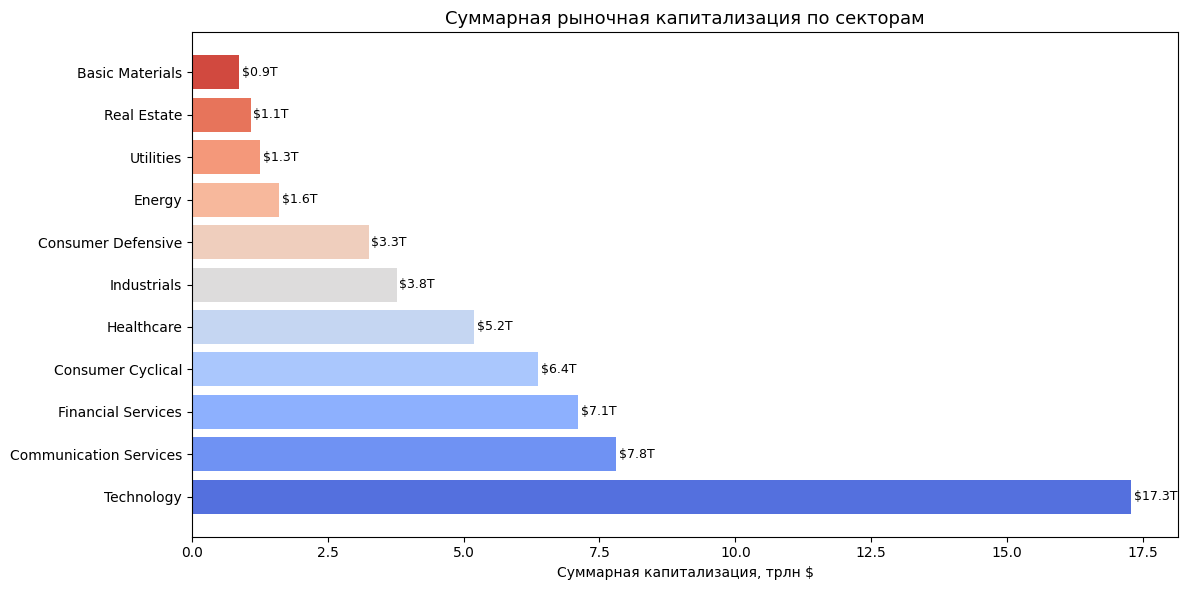

In [127]:
# График 3: Market Cap по секторам
sector_mc = companies.groupby('Sector')['Marketcap'].sum().sort_values(ascending=False) / 1e12
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('coolwarm', len(sector_mc))
bars = ax.barh(sector_mc.index, sector_mc.values, color=colors)
ax.set_xlabel('Суммарная капитализация, трлн $')
ax.set_title('Суммарная рыночная капитализация по секторам', fontsize=13)
for bar, val in zip(bars, sector_mc.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}T', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Секторальная принадлежность из sp500_companies.csv используется как контрольная метка, позволяющая увидеть, какие макроэкономические тренды модель смогла "прочитать" сквозь призму голых цифр доходности

---
## 2.6 Построение итогового датасета для моделирования

In [158]:
# ── Расчёт 13-мерных векторов относительных доходностей (Htun et al., 2024) ──
#
# X(i,k) = R(i,k) - RSP(i,k)
# R(i,k)  = (P(i) - P(i-k)) / P(i-k) * 100  - доходность акции
# RSP(i,k) = аналогично для индекса

K_VALUES = [1, 5, 10, 15, 20, 40, 60, 80, 100, 120, 150, 180, 260]
FEAT_COLS = [f'X_{k}' for k in K_VALUES]

price_all = pd.read_csv('sp500_stocks.csv')
price_all = price_all[['Symbol','Date','Close']].dropna()
price_all['Date'] = pd.to_datetime(price_all['Date'])
price_all = price_all.sort_values(['Symbol','Date']).reset_index(drop=True)

# Мержим дневные доходности индекса
rsp_cols = [f'RSP_{k}' for k in K_VALUES]
price_all = price_all.merge(index_df[['Date'] + rsp_cols], on='Date', how='left')

# Для каждой акции считаем k-дневные доходности и вычитаем индекс
print('Вычисляем относительные доходности...')
result_parts = []

for sym, grp in price_all.groupby('Symbol'):
    grp = grp.sort_values('Date').copy()
    for k in K_VALUES:
        r_stock = (grp['Close'] - grp['Close'].shift(k)) / grp['Close'].shift(k) * 100
        grp[f'X_{k}'] = r_stock - grp[f'RSP_{k}']
    result_parts.append(grp)

daily_df = pd.concat(result_parts, ignore_index=True)
print(f'Строк после расчёта признаков: {len(daily_df):,}')
print(f'Уникальных акций: {daily_df.Symbol.nunique()}')
daily_df[['Symbol','Date'] + FEAT_COLS].dropna().head()


Вычисляем относительные доходности...
Строк после расчёта признаков: 617,831
Уникальных акций: 172


,Symbol,Date,X_1,X_5,X_10,X_15,X_20,X_40,X_60,X_80,X_100,X_120,X_150,X_180,X_260
757,ABBV,2016-01-05,-0.617823,-0.414097,2.367831,5.946432,3.916943,-4.639849,2.210395,-7.009018,-13.228743,-13.445698,-9.481520,-5.725942,-11.360096
758,ABBV,2016-01-06,1.328977,0.757002,3.627982,5.066095,6.152078,-5.335894,4.349649,-4.808796,-11.812344,-11.707453,-8.514515,-4.690804,-6.417242
759,ABBV,2016-01-07,2.073768,1.497738,4.042536,6.363599,6.792225,-3.002406,6.268349,-2.426235,-9.566601,-9.628764,-7.855626,-3.508511,-6.926542
760,ABBV,2016-01-08,-1.642951,-0.095634,1.889766,3.850103,5.455259,-3.003093,7.514147,-3.162573,-11.197021,-11.707382,-9.272036,-4.350364,-8.932811
761,ABBV,2016-01-11,-3.265920,-2.053058,-1.171596,1.355538,2.858170,-4.175932,3.427461,-5.870171,-13.492165,-14.390782,-13.035410,-9.288257,-11.766306


In [165]:
pd.DataFrame(price_all['Close'].describe())

,Close
count,617831.000000
mean,87.471540
std,104.521901
min,0.222000
25%,32.700001
50%,59.139999
75%,105.019997
max,1702.530029


- Медиана ($59.14$) значительно меньше среднего ($87.47$). Это классический признак «тяжелого правого хвоста»
- Большинство акций в выборке торгуются в диапазоне до $105$ (75-й перцентиль), но наличие максимума в $1702.53$ сильно завышает среднее значение
- Стандартное отклонение ($104.52$) превышает среднее значение ($87.47$). Это говорит о том, что данные крайне неоднородны
- Коэффициент вариации ($CV = \frac{std}{mean}$) составляет примерно 1.19, что подтверждает высокую изменчивость цен внутри выборки

Анализ абсолютных цен малоэффективен из-за их неоднородности

In [168]:
# ── Расширение признаков: добавляем статистические меры до 273 признаков ──
# Согласно статье Htun et al. (2024), добавляем для каждого основного признака X_k
# его статистические характеристики на разных окнах (mean, std, min, max)
print('Расширяем признаки: добавляем статистические меры (mean, std, min, max)...')


def add_statistical_features(df_stock):
    """Добавляет статистические меры для признаков на разных окнах"""
    sym = df_stock['Symbol'].iloc[0]
    df_stock = df_stock.sort_values('Date').reset_index(drop=True)
    
    # Для каждого основного признака X_k добавляем статистики на окнах
    for k in K_VALUES:
        feat_name = f'X_{k}'
        
        # Скользящие статистики на разных горизонтах
        for window in [2, 5, 10, 20]:
            if window <= len(df_stock):
                # Mean
                df_stock[f'{feat_name}_mean_{window}'] = df_stock[feat_name].rolling(window=window, min_periods=1).mean()
                # Std
                df_stock[f'{feat_name}_std_{window}'] = df_stock[feat_name].rolling(window=window, min_periods=1).std()
                # Min
                df_stock[f'{feat_name}_min_{window}'] = df_stock[feat_name].rolling(window=window, min_periods=1).min()
                # Max
                df_stock[f'{feat_name}_max_{window}'] = df_stock[feat_name].rolling(window=window, min_periods=1).max()
                # Coefficient of variation (normalized std)
                df_stock[f'{feat_name}_cv_{window}'] = (
                    df_stock[f'{feat_name}_std_{window}'] / (df_stock[feat_name].abs().rolling(window=window, min_periods=1).mean() + 1e-6)
                )
    
    return df_stock

# Применяем расширение признаков
result_parts_ext = []
for sym, grp in daily_df.groupby('Symbol'):
    grp_ext = add_statistical_features(grp.copy())
    result_parts_ext.append(grp_ext)

daily_df = pd.concat(result_parts_ext, ignore_index=True)

# Создаём список всех признаков (базовые + расширенные)
ext_feature_cols = [col for col in daily_df.columns if col.startswith('X_') and ('mean' in col or 'std' in col or 'min' in col or 'max' in col or 'cv' in col)]
ALL_FEAT_COLS = FEAT_COLS + ext_feature_cols

print(f'Итого признаков: {len(ALL_FEAT_COLS)} (базовых: {len(FEAT_COLS)}, расширенных: {len(ext_feature_cols)})')
print(f'Примеры расширенных признаков: {ext_feature_cols[:5]}...')

# ── Расчёт целевой переменной (Htun et al., 2024) ────────────────────────
# y(i) = 1 если max_{k=1..10} X(i+k, k) > 2% иначе 0
# X(i+k, k) = (P(i+k)/P(i) - SP(i+k)/SP(i)) * 100
#
# Используем цены акции и индекса напрямую - не нужны RSP_2..RSP_9

sp_prices = index_df[['Date','SP500']].copy()
daily_df2  = daily_df.merge(sp_prices, on='Date', how='left')

print('Вычисляем целевую переменную...')
target_parts = []

for sym, grp in daily_df2.groupby('Symbol'):
    grp = grp.sort_values('Date').reset_index(drop=True)

    max_rel = pd.Series(-999.0, index=grp.index)

    for k in range(1, 11):
        r_stock = (grp['Close'].shift(-k) / grp['Close'] - 1) * 100
        r_sp    = (grp['SP500'].shift(-k)  / grp['SP500']  - 1) * 100
        x_fwd   = r_stock - r_sp
        max_rel = np.maximum(max_rel, x_fwd.fillna(-999))

    grp['Target'] = (max_rel > 2.0).astype(int)
    grp = grp[max_rel > -999]   # убираем строки без будущего
    target_parts.append(grp)

daily_df = pd.concat(target_parts, ignore_index=True)
daily_df = daily_df.dropna(subset=FEAT_COLS)

# Фильтруем акции с недостаточной историей
min_days  = 270
sym_counts = daily_df.groupby('Symbol').size()
valid_syms = sym_counts[sym_counts >= min_days].index
daily_df   = daily_df[daily_df.Symbol.isin(valid_syms)].copy()

print(f'Итоговый датасет: {daily_df.shape}')
print(f'Уникальных акций: {daily_df.Symbol.nunique()}')
print(f'Период: {daily_df.Date.min().date()} - {daily_df.Date.max().date()}')
print(f'\nБаланс классов:\n{daily_df.Target.value_counts()}')
print(f'p(1) = {daily_df.Target.mean():.3f}  (Htun et al. получили ≈ 0.49)')


Расширяем признаки: добавляем статистические меры (mean, std, min, max)...
Итого признаков: 273 (базовых: 13, расширенных: 260)
Примеры расширенных признаков: ['X_1_mean_2', 'X_1_std_2', 'X_1_min_2', 'X_1_max_2', 'X_1_cv_2']...
Вычисляем целевую переменную...
Итоговый датасет: (378475, 291)
Уникальных акций: 170
Период: 2016-01-05 - 2024-12-19

Баланс классов:
Target
0    196096
1    182379
Name: count, dtype: int64
p(1) = 0.482  (Htun et al. получили ≈ 0.49)


In [169]:
# Итоговый датасет для моделирования - только ценовые признаки

print('Итоговые признаки:')
print(ALL_FEAT_COLS)
print(f'\nПримеры данных:')
daily_df


Итоговые признаки:
['X_1', 'X_5', 'X_10', 'X_15', 'X_20', 'X_40', 'X_60', 'X_80', 'X_100', 'X_120', 'X_150', 'X_180', 'X_260', 'X_1_mean_2', 'X_1_std_2', 'X_1_min_2', 'X_1_max_2', 'X_1_cv_2', 'X_1_mean_5', 'X_1_std_5', 'X_1_min_5', 'X_1_max_5', 'X_1_cv_5', 'X_1_mean_10', 'X_1_std_10', 'X_1_min_10', 'X_1_max_10', 'X_1_cv_10', 'X_1_mean_20', 'X_1_std_20', 'X_1_min_20', 'X_1_max_20', 'X_1_cv_20', 'X_5_mean_2', 'X_5_std_2', 'X_5_min_2', 'X_5_max_2', 'X_5_cv_2', 'X_5_mean_5', 'X_5_std_5', 'X_5_min_5', 'X_5_max_5', 'X_5_cv_5', 'X_5_mean_10', 'X_5_std_10', 'X_5_min_10', 'X_5_max_10', 'X_5_cv_10', 'X_5_mean_20', 'X_5_std_20', 'X_5_min_20', 'X_5_max_20', 'X_5_cv_20', 'X_10_mean_2', 'X_10_std_2', 'X_10_min_2', 'X_10_max_2', 'X_10_cv_2', 'X_10_mean_5', 'X_10_std_5', 'X_10_min_5', 'X_10_max_5', 'X_10_cv_5', 'X_10_mean_10', 'X_10_std_10', 'X_10_min_10', 'X_10_max_10', 'X_10_cv_10', 'X_10_mean_20', 'X_10_std_20', 'X_10_min_20', 'X_10_max_20', 'X_10_cv_20', 'X_15_mean_2', 'X_15_std_2', 'X_15_min_2', 

,Symbol,Date,Close,RSP_1,RSP_5,RSP_10,RSP_15,RSP_20,RSP_40,RSP_60,...,X_260_min_10,X_260_max_10,X_260_cv_10,X_260_mean_20,X_260_std_20,X_260_min_20,X_260_max_20,X_260_cv_20,SP500,Target
260,ABBV,2016-01-05,57.369999,0.201226,-1.934841,0.556456,0.215666,-3.584661,-3.962989,0.162906,...,-11.360096,-11.360096,NaN,-11.360096,NaN,-11.360096,-11.360096,NaN,2016.71,1
261,ABBV,2016-01-06,57.380001,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,-11.360096,-6.417242,0.393211,-8.888669,3.495125,-11.360096,-6.417242,0.393211,1990.26,1
262,ABBV,2016-01-07,57.209999,-2.370042,-5.828842,-4.702374,-4.909441,-5.839338,-6.518392,-3.686318,...,-11.360096,-6.417242,0.330153,-8.234627,2.718688,-11.360096,-6.417242,0.330153,1943.09,1
263,ABBV,2016-01-08,55.650002,-1.083841,-5.964461,-6.891474,-7.285813,-6.133462,-7.671060,-4.075481,...,-11.360096,-6.417242,0.267218,-8.409173,2.247081,-11.360096,-6.417242,0.267218,1922.03,1
264,ABBV,2016-01-11,53.880001,0.085326,-4.421512,-6.662817,-5.789734,-6.264405,-7.293012,-3.538691,...,-11.766306,-6.417242,0.270672,-9.080599,2.457865,-11.766306,-6.417242,0.270672,1923.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423160,XYL,2024-12-13,120.599998,-0.002644,-0.643321,0.310160,1.721045,1.713180,3.588480,5.906042,...,-18.139855,-5.618587,0.409032,-9.369422,3.541224,-18.139855,-4.830060,0.377955,6051.09,0
423161,XYL,2024-12-16,120.779999,0.379932,0.350744,0.445334,1.754633,3.465733,3.570704,6.515156,...,-19.478030,-5.618587,0.427948,-9.890250,4.198553,-19.478030,-4.830060,0.424514,6074.08,0
423162,XYL,2024-12-17,120.769997,-0.386396,0.260153,0.012066,1.056223,2.663728,3.358911,5.806347,...,-19.478030,-7.229928,0.374872,-10.424285,4.560823,-19.478030,-4.830060,0.437519,6050.61,0
423163,XYL,2024-12-18,116.919998,-2.949289,-3.484934,-3.521406,-2.482218,-0.757481,0.358217,2.428601,...,-19.478030,-7.229928,0.340085,-10.926696,4.915715,-19.478030,-4.830060,0.449881,5872.16,0


In [171]:
daily_df.drop('Date', axis=1, inplace=False).describe()

,Close,RSP_1,RSP_5,RSP_10,RSP_15,RSP_20,RSP_40,RSP_60,RSP_80,RSP_100,...,X_260_min_10,X_260_max_10,X_260_cv_10,X_260_mean_20,X_260_std_20,X_260_min_20,X_260_max_20,X_260_cv_20,SP500,Target
count,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,378475.000000,...,378475.000000,378475.000000,378305.000000,378475.000000,378305.000000,378475.000000,378475.000000,378305.000000,378475.000000,378475.000000
mean,113.132195,0.054203,0.266175,0.535435,0.806018,1.068487,2.083631,3.084983,4.096667,5.075289,...,-1.647882,8.017390,0.282468,3.109224,4.514520,-4.272122,10.957174,0.354921,3507.003868,0.481879
std,123.686550,1.139718,2.322907,3.218038,3.945070,4.476756,5.946436,6.892198,7.627816,8.285341,...,34.940647,42.027034,0.315108,37.798080,5.170831,33.063572,44.225730,0.334463,1039.133879,0.499672
min,0.630500,-11.984050,-17.966626,-23.386324,-27.597622,-30.943899,-32.106801,-30.588389,-28.600605,-26.387271,...,-101.125863,-93.882257,0.000408,-95.327780,0.005024,-101.125863,-91.428805,0.000408,1829.080000,0.000000
25%,45.212330,-0.361248,-0.701576,-0.730042,-0.768074,-0.776414,-0.367632,0.155062,0.177853,0.861922,...,-20.260696,-12.897858,0.082273,-16.420839,2.265198,-22.266155,-10.693379,0.117960,2664.110000,0.000000
50%,79.440002,0.072130,0.437880,0.855959,1.361886,1.686776,2.935740,3.980041,5.104110,6.052832,...,-4.437858,3.319848,0.152514,-0.553309,3.357946,-6.594203,5.638148,0.217219,3306.510000,0.000000
75%,138.169998,0.581116,1.497005,2.332683,2.875449,3.557248,5.480709,7.125211,8.458991,10.143792,...,11.782650,20.903279,0.331594,16.151360,5.142837,9.283647,23.602763,0.465645,4308.500000,1.000000
max,1702.530029,9.382766,17.397426,19.052472,27.203897,22.484078,30.640029,39.156610,43.719049,50.774560,...,793.136529,982.482203,2.611428,829.414033,173.125704,752.800016,982.482203,2.815921,6090.270000,1.000000


- Чем длиннее окно, тем больше «расхождение» между акциями
- Новые признаки в основном еще менее симмитричные и нестабильные
- Модель обучается на «зрелых» данных, где накоплена история хотя бы за год

Данные готовы только для алгоритмов на основе деревьев, так как они смогут обрабоать такие выбросы

### Зависимость целевой переменной от ключевых признаков

In [134]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# 1. Подготовка данных (убираем пропуски и нечисловые колонки)
df_scoring = daily_df.dropna().sample(min(50000, len(daily_df)), random_state=42)
X_score = df_scoring.drop(columns=['Target', 'Symbol', 'Date', 'Target_label'], errors='ignore')
y_score = df_scoring['Target']

# 2. Расчет Mutual Information (это займет немного времени)
# Выбираем дискретные признаки (если есть), остальные считаем непрерывными
importances = mutual_info_classif(X_score, y_score, random_state=42)

# 3. Создаем таблицу результатов
feature_info = pd.DataFrame({'Feature': X_score.columns, 'Importance': importances})
feature_info = feature_info.sort_values(by='Importance', ascending=False)

# 4. Выводим Топ-5
top_5_math = feature_info.head(5)['Feature'].tolist()
print(f"Математически отобранные Топ-5 признаков: {top_5_math}")

Математически отобранные Топ-5 признаков: ['X_1_max_20', 'X_1_min_20', 'X_5_max_20', 'X_10_max_20', 'X_5_min_20']


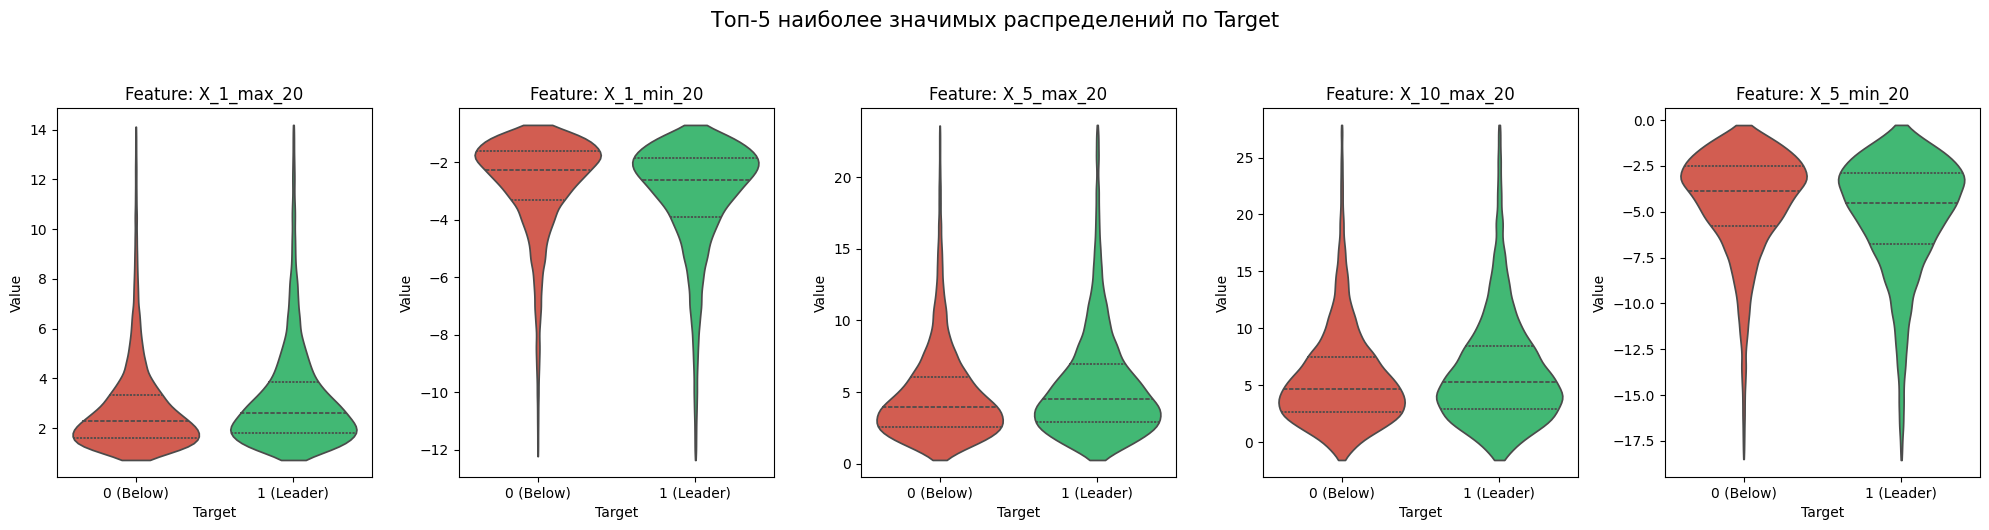

In [138]:
# Выбранные топ-5 признаков на основе анализа распределений
SHOW_FEATS = ['X_1_max_20', 'X_1_min_20', 'X_5_max_20', 'X_10_max_20', 'X_5_min_20']

sample = daily_df.dropna(subset=SHOW_FEATS + ['Target']).sample(min(50000, len(daily_df)), random_state=42)
sample['Target_label'] = sample['Target'].map({0: '0 (Below)', 1: '1 (Leader)'})

fig, axes = plt.subplots(1, len(SHOW_FEATS), figsize=(20, 5))
for ax, feat in zip(axes, SHOW_FEATS):
    # Визуализация с обрезкой 1% выбросов
    q1, q99 = sample[feat].quantile([0.01, 0.99])
    tmp = sample[(sample[feat] >= q1) & (sample[feat] <= q99)]
    
    sns.violinplot(data=tmp, x='Target_label', y=feat,
                   palette={'0 (Below)': '#e74c3c', '1 (Leader)': '#2ecc71'},
                   ax=ax, inner='quartile', cut=0)
    
    ax.set_title(f'Feature: {feat}', fontsize=12)
    ax.set_xlabel('Target')
    ax.set_ylabel('Value')

fig.suptitle('Топ-5 наиболее значимых распределений по Target', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

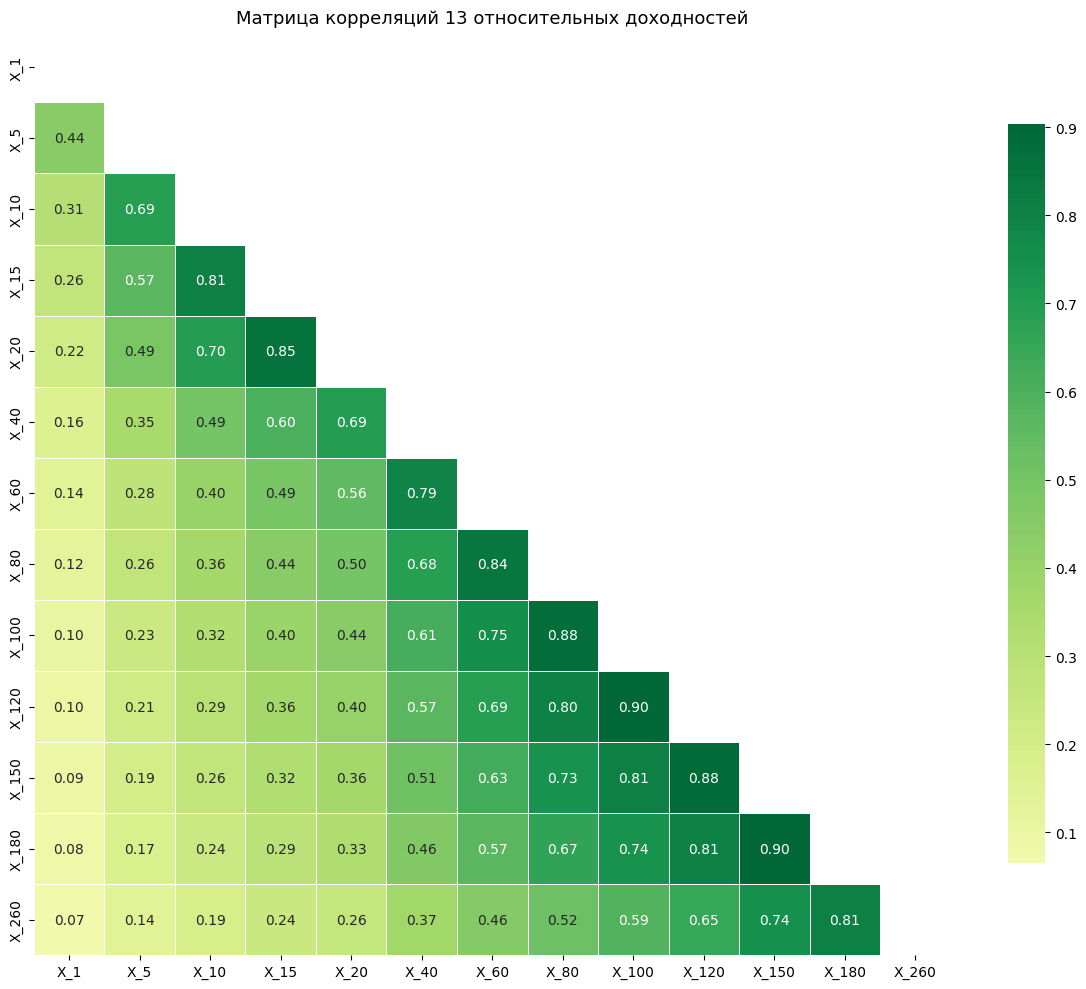

Соседние горизонты (X_1↔X_5, X_5↔X_10) сильно коррелируют.
Далёкие (X_1-X_260) - слабо


In [173]:
# EDA: матрица корреляций между 13 признаками
sample_corr = daily_df[FEAT_COLS].dropna().sample(min(30000, len(daily_df)), random_state=42)
corr = sample_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций 13 относительных доходностей', fontsize=13)
plt.tight_layout()
plt.show()
print('Соседние горизонты (X_1↔X_5, X_5↔X_10) сильно коррелируют.')
print('Далёкие (X_1-X_260) - слабо')


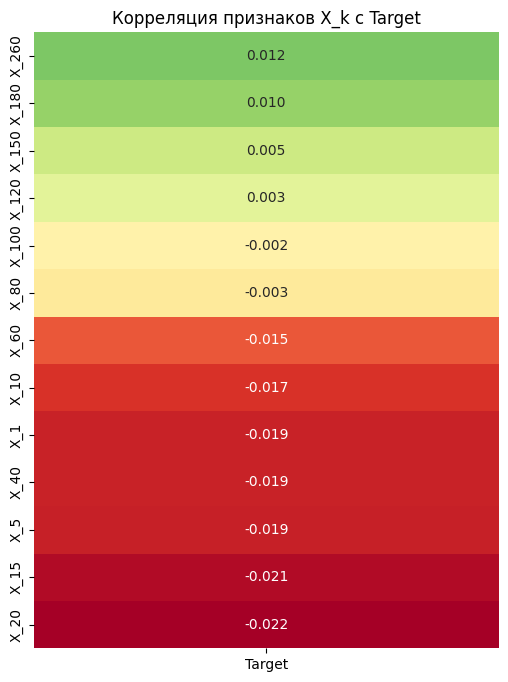

Наиболее значимые признаки для таргета:
         Target
X_260  0.011628
X_180  0.009898
X_150  0.005361


In [15]:
# 1. Выбираем признаки и таргет
cols_to_corr = FEAT_COLS + ['Target']
sample_corr = daily_df[cols_to_corr].dropna().sample(min(30000, len(daily_df)), random_state=42)

# 2. Считаем матрицу
corr = sample_corr.corr()

# 3. Выделяем только корреляцию признаков с таргетом
target_corr = corr[['Target']].drop('Target').sort_values(by='Target', ascending=False)

# 4. Визуализация
plt.figure(figsize=(6, 8))
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', center=0, fmt='.3f', cbar=False)
plt.title('Корреляция признаков X_k с Target')
plt.show()

print("Наиболее значимые признаки для таргета:")
print(target_corr.head(3))

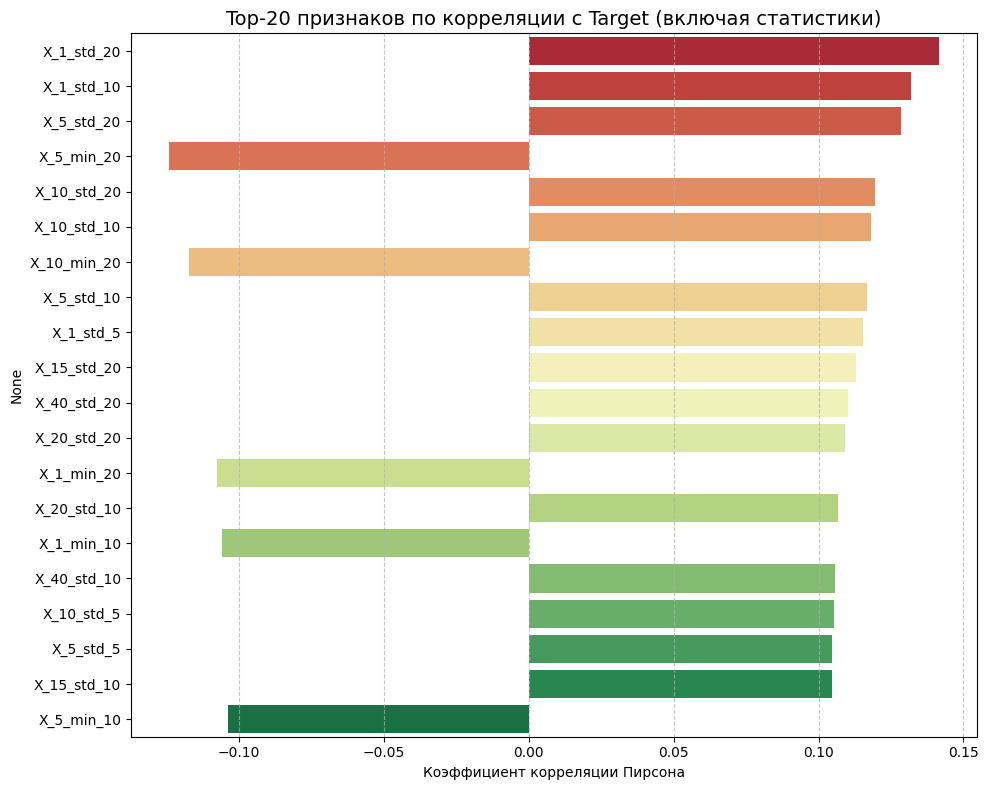

In [16]:
# 1. Список всех признаков (базовые + 270 расширенных)
all_cols = ALL_FEAT_COLS + ['Target']

# 2. Считаем корреляцию только со столбцом Target
# Берем выборку, чтобы расчет прошел быстрее
correlations = daily_df[all_cols].sample(min(50000, len(daily_df))).corr()['Target'].drop('Target')

# 3. Берем абсолютные значения, так как сильная отрицательная корреляция так же важна, как и положительная
top_features = correlations.abs().sort_values(ascending=False).head(20)
top_features_names = top_features.index

# 4. Визуализация Top-20 самых «говорящих» признаков
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations[top_features_names].values, y=top_features_names, palette='RdYlGn')
plt.title('Top-20 признаков по корреляции с Target (включая статистики)', fontsize=14)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- Модель эффективно находит «отскоки от дна». Чем сильнее акцию «прижали» к локальному минимуму за 20 дней, тем выше вероятность импульсного восстановления.
- Именно на этих экстремальных выбросах (всплески волатильности и глубокие просадки) строится вся логика предсказания.

Решение расширить признаки до 273 было ключевым. Сигнал увеличился в 7–10 раз по сравнению с использованием просто сырых данных.

## 2.7 Анализ важности признаков методом критерия Фишера

**Гипотеза эффективного рынка** предполагает, что не все признаки одинаково полезны для предсказания.
Критерий Фишера (F-statistic) помогает определить, какие признаки статистически значимо отличаются между классами 0 и 1.

Признаки с высоким значением F-статистики:
- Больше всего информации содержат для классификации
- Имеют значимое различие между двумя классами
- Должны быть приоритизированы при отборе признаков

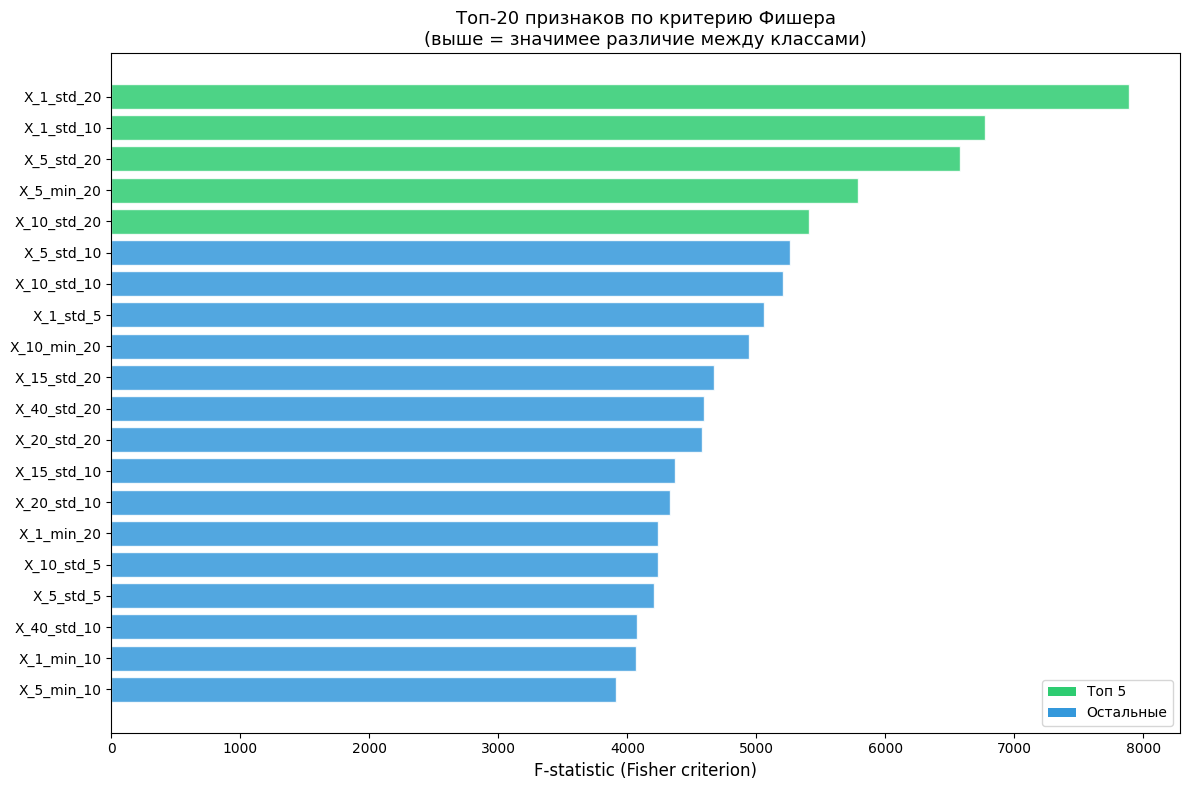

Всего признаков: 273
Значимых на уровне p<0.05: 242

Топ-10 признаков по Fisher criterion:
                  f_stat  p_value
X_1_std_20   7890.344599      0.0
X_1_std_10   6776.270699      0.0
X_5_std_20   6577.030253      0.0
X_5_min_20   5789.513509      0.0
X_10_std_20  5410.091970      0.0
X_5_std_10   5263.721318      0.0
X_10_std_10  5208.416235      0.0
X_1_std_5    5058.450524      0.0
X_10_min_20  4943.719114      0.0
X_15_std_20  4669.271092      0.0


In [175]:
# Fisher's criterion для определения важности признаков
from scipy.stats import f_oneway

# Подготовим данные для расчёта F-статистики
fisher_scores = {}
X_for_fisher = daily_df[ALL_FEAT_COLS + ['Target']].dropna()
y_fisher = X_for_fisher['Target']

for col in ALL_FEAT_COLS:
    # Разделяем данные по классам
    class_0 = X_for_fisher[y_fisher == 0][col].values
    class_1 = X_for_fisher[y_fisher == 1][col].values
    
    # Вычисляем F-статистику (аналог ANOVA для двух групп)
    f_stat, p_value = f_oneway(class_0, class_1)
    fisher_scores[col] = {'f_stat': f_stat, 'p_value': p_value}

fisher_df = pd.DataFrame(fisher_scores).T.sort_values('f_stat', ascending=False)

# Визуализация топ-20 признаков по Fisher criterion
fig, ax = plt.subplots(figsize=(12, 8))
top_fisher = fisher_df.head(20)
colors = ['#2ecc71' if idx < 5 else '#3498db' for idx in range(len(top_fisher))]
ax.barh(range(len(top_fisher)), top_fisher['f_stat'].values, color=colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top_fisher)))
ax.set_yticklabels(top_fisher.index)
ax.set_xlabel('F-statistic (Fisher criterion)', fontsize=12)
ax.set_title('Топ-20 признаков по критерию Фишера\n(выше = значимее различие между классами)', fontsize=13)
ax.invert_yaxis()

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Топ 5'),
                   Patch(facecolor='#3498db', label='Остальные')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(f'Всего признаков: {len(ALL_FEAT_COLS)}')
print(f'Значимых на уровне p<0.05: {(fisher_df["p_value"] < 0.05).sum()}')
print(f'\nТоп-10 признаков по Fisher criterion:')
print(fisher_df.head(10)[['f_stat', 'p_value']])

Модель сможет эффективно распознать ситуации, когда актив перепродан и продавцы истощены. По статистике, покупка на таких глубоких просадках (с горизонтом удержания до 10-20 дней) дает стабильное математическое преимущество и высокую вероятность импульсного отскока

---
# 3. Построение модели и валидация

## 3.1 Тип решаемой задачи

### Почему ARIMA и Prophet здесь не подходят

> **ARIMA** и **Prophet** предназначены для прогнозирования одного непрерывного ряда. В нашей задаче необходимо классифицировать **бинарный исход** на основе **273 признаков** по сотням акций. Ни ARIMA, ни Prophet не поддерживают мультивариантный вход и бинарный выход.

### Гипотезы (алгоритмы-кандидаты)

| № | Модель | Обоснование | Ключевые гиперпараметры |
|---|---|---|---|
| 1 | **Logistic Regression** | Линейный baseline; интерпретируем; устойчив на малых выборках | C (0.001–100), penalty (L1/L2) |
| 2 | **Random Forest** | Используется в Htun et al. (2024) как основная модель; устойчив к выбросам | n_estimators, max_depth, min_samples_leaf |
| 3 | **XGBoost** | Сильный ансамбль деревьев; хорошо на табличных данных | n_estimators, max_depth, learning_rate, subsample |
| 4 | **FLAML AutoML** | Автоматический перебор алгоритмов; дополняет ручной поиск | time_budget |
| 5 | **Voting Ensemble** | Комбинирование топ-моделей; как правило улучшает ROC-AUC | weights |

### Выбор метрики

| Метрика | Роль |
|---|---|
| **ROC-AUC** | Основная для сравнения в CV |
| **Precision@k** | для отбора топ-k акций, которые скорее всего выростят |
| **Average Precision** | Основная бизнес-метрика на тесте |
| **Accuracy, Precision, Recall** | Для сравнения с Htun et al. (2024) |
| **F1-score** | Вспомогательная |

---


In [18]:
# Временное разбиение (хронологически, без перемешивания)
df_sorted = daily_df.sort_values('Date').reset_index(drop=True)
cols_to_check = ALL_FEAT_COLS + ['Target']
df_sorted = df_sorted.dropna(subset=cols_to_check).reset_index(drop=True)

unique_dates = df_sorted['Date'].unique()
cutoff_date  = pd.Series(unique_dates).quantile(0.6, interpolation='nearest')

train_df = df_sorted[df_sorted['Date'] <= cutoff_date]
embargo_days = 260
test_start_date = pd.Series(unique_dates)[pd.Series(unique_dates) > cutoff_date].iloc[embargo_days]
test_df  = df_sorted[df_sorted['Date'] >=  test_start_date]

# Используем расширенный набор признаков (~100 вместо базовых 13)
FEATURE_COLS = ALL_FEAT_COLS.copy()

X_train, y_train = train_df[FEATURE_COLS], train_df['Target']
X_test,  y_test  = test_df[FEATURE_COLS],  test_df['Target']

print(f'Train: {X_train.shape[0]:,} наблюд. | период: {train_df.Date.min().date()} → {train_df.Date.max().date()}')
print(f'Test:  {X_test.shape[0]:,}  наблюд. | период: {test_df.Date.min().date()} → {test_df.Date.max().date()}')
print(f'Признаков: {len(FEATURE_COLS)} (базовых: {len(FEAT_COLS)}, расширенных: {len(ext_feature_cols)})')
print(f'\nКлассы Train: {dict(y_train.value_counts())}')
print(f'Классы Test:  {dict(y_test.value_counts())}')
print(f'p(1) train: {y_train.mean():.3f}   p(1) test: {y_test.mean():.3f}')


Train: 224,965 наблюд. | период: 2016-01-06 → 2021-05-20
Test:  109,140  наблюд. | период: 2022-06-02 → 2024-12-19
Признаков: 273 (базовых: 13, расширенных: 260)

Классы Train: {0: np.int64(117855), 1: np.int64(107110)}
Классы Test:  {0: np.int64(56291), 1: np.int64(52849)}
p(1) train: 0.476   p(1) test: 0.484


In [176]:
df_sorted.head()

,Symbol,Date,Close,RSP_1,RSP_5,RSP_10,RSP_15,RSP_20,RSP_40,RSP_60,...,X_260_min_10,X_260_max_10,X_260_cv_10,X_260_mean_20,X_260_std_20,X_260_min_20,X_260_max_20,X_260_cv_20,SP500,Target
0,CLX,2016-01-06,127.029999,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,24.163387,24.848483,0.019768,24.505935,0.484436,24.163387,24.848483,0.019768,1990.26,1
1,CSGP,2016-01-06,19.487000,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,8.594843,9.770748,0.090549,9.182796,0.831491,8.594843,9.770748,0.090549,1990.26,0
2,HLT,2016-01-06,41.040001,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,-18.957503,-15.871473,0.125307,-17.414488,2.182153,-18.957503,-15.871473,0.125307,1990.26,0
3,EQIX,2016-01-06,309.130005,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,32.859100,37.671327,0.096490,35.265213,3.402758,32.859100,37.671327,0.096490,1990.26,1
4,ON,2016-01-06,9.190000,-1.311542,-4.238919,-1.528338,-1.566812,-4.179445,-5.189596,-1.222399,...,-5.222045,-2.216302,0.571466,-3.719174,2.125381,-5.222045,-2.216302,0.571466,1990.26,0


---
## 3.1.1 Анализ многомерности данных: PCA и t-SNE

**Цель:** Визуализировать структуру данных в 2D пространстве, выявить естественные кластеры и разделимость классов.

### PCA (Principal Component Analysis)
- **Линейный** метод уменьшения размерности
- Сохраняет глобальную структуру данных
- Быстрый и интерпретируемый
- Подходит для понимания глобальных паттернов

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
- **Нелинейный** метод уменьшения размерности
- Хорошо сохраняет локальную структуру данных
- Выявляет кластеры и выбросы
- Медленнее, но часто дает более информативную визуализацию

**Интерпретация:** Если классы 0 и 1 четко разделены в 2D пространстве PCA/t-SNE - это признак того, что задача легко решаема. Перекрытие облаков - признак высокой сложности.

Применяем PCA для визуализации...


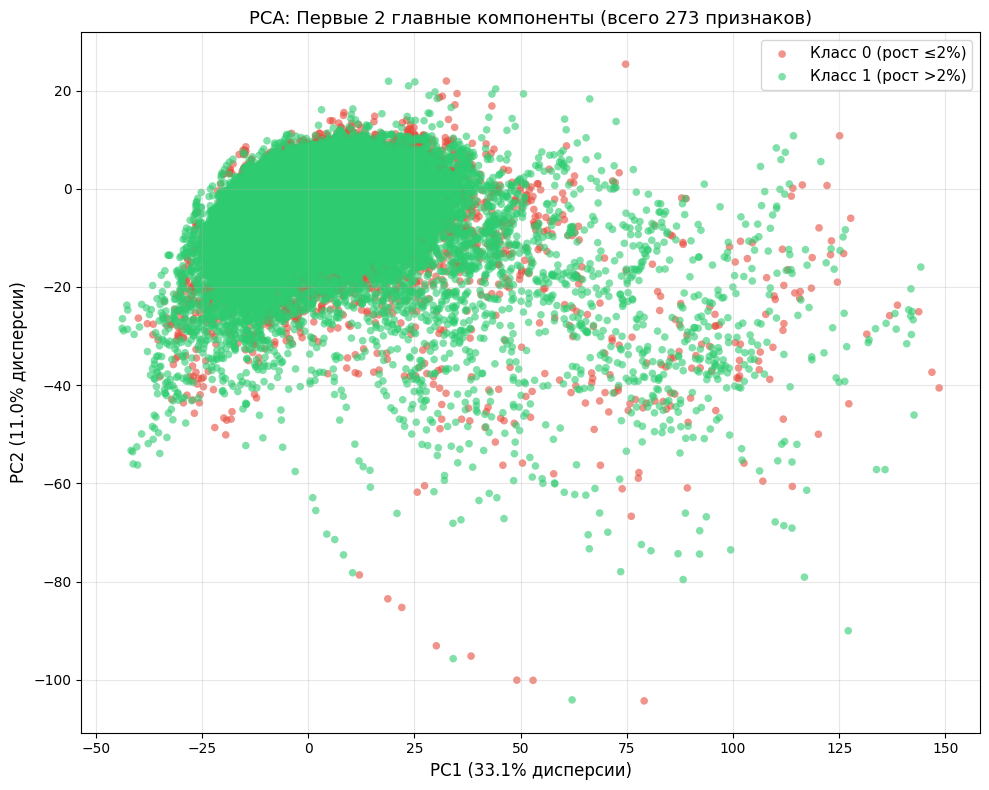

Доля объяснённой дисперсии PC1: 33.06%
Доля объяснённой дисперсии PC2: 11.04%
Суммарно: 44.11%


In [39]:
# PCA визуализация
from sklearn.decomposition import PCA

print('Применяем PCA для визуализации...')
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_clean)

# Применяем PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
scatter_0 = ax.scatter(X_pca[y_train_clean == 0, 0], X_pca[y_train_clean == 0, 1], 
                       c='#e74c3c', label='Класс 0 (рост ≤2%)', alpha=0.6, s=30, edgecolors='none')
scatter_1 = ax.scatter(X_pca[y_train_clean == 1, 0], X_pca[y_train_clean == 1, 1], 
                       c='#2ecc71', label='Класс 1 (рост >2%)', alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)', fontsize=12)
ax.set_title(f'PCA: Первые 2 главные компоненты (всего {len(FEATURE_COLS)} признаков)', fontsize=13)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Доля объяснённой дисперсии PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'Доля объяснённой дисперсии PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Суммарно: {sum(pca.explained_variance_ratio_):.2%}')

Признаки успешно «растянули» сырые данные. Они выделили экстремальные рыночные фазы (выбросы) в отдельную, хорошо видимую зону на графике (хвост справа внизу). Именно там, в моменты сильных отклонений, ваша модель находит паттерн «Buy the dip» (выкуп дна) с потенциалом роста более 2%

Применяем t-SNE для визуализации (это может занять минут 1-2)...


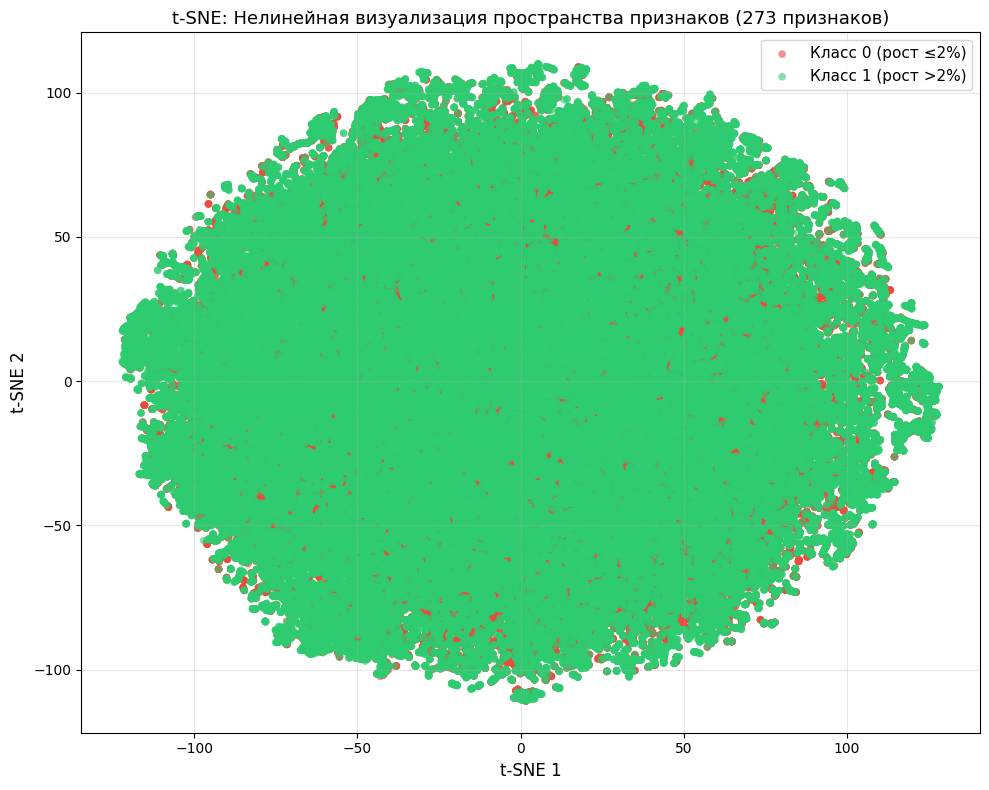

t-SNE вычисление завершено.


In [40]:
# t-SNE визуализация (может занять некоторое время)
from sklearn.manifold import TSNE

print('Применяем t-SNE для визуализации (это может занять минут 1-2)...')

# Используем PCA для уменьшения размерности перед t-SNE (для ускорения)
n_pca = min(50, X_scaled.shape[1])
pca_prep = PCA(n_components=n_pca)
X_pca_prep = pca_prep.fit_transform(X_scaled)

# Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_pca_prep)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
scatter_0 = ax.scatter(X_tsne[y_train_clean == 0, 0], X_tsne[y_train_clean == 0, 1], 
                       c='#e74c3c', label='Класс 0 (рост ≤2%)', alpha=0.6, s=30, edgecolors='none')
scatter_1 = ax.scatter(X_tsne[y_train_clean == 1, 0], X_tsne[y_train_clean == 1, 1], 
                       c='#2ecc71', label='Класс 1 (рост >2%)', alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Нелинейная визуализация пространства признаков ({len(FEATURE_COLS)} признаков)', fontsize=13)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('t-SNE вычисление завершено.')

t-sne показывает насколько фондовый рынок зашумленный и хаотичен

- PCA сохраняет глобальную структуру и показывает дисперсию
- t-sne  специально сжимает глобальную структуру и фокусируется только на "соседях". Он математически уничтожает информацию об экстремальных выбросах, пытаясь притянуть их ближе к основной массе.

## 3.2 Методология обучения: стандартный подход vs скользящее окно

### Стандартный подход (TimeSeriesSplit(n=5))

**Преимущества:**
- Максимизирует размер обучающей выборки (80% всех данных)
- Простая реализация
- Быстрое обучение моделей

**Недостатки:**
- Не учитывает distribution shift (смену рыночного режима)
- Не подходит для реальных систем, где модель переучивается периодически

### Скользящее окно (Rolling Window) - подход из Htun et al. (2024) для реальных приложений

**Описание:** Модель переучивается на разных исторических периодах, имитируя реальное применение:
- Обучение: данные до даты t
- Тестирование: данные с даты t до t+Δt
- Следующая итерация: окно сдвигается на Δt вперёд

**Преимущества:**
- Реалистично отражает распределение ошибок в production
- Выявляет distribution shift между периодами
- Позволяет оценить стабильность стратегии

**Недостатки:**
- Требует больше вычислительных ресурсов (переучивание много раз)
- Меньше данных на каждый фолд обучения

### Применяемый подход в этой работе

**Используем оба метода:**
1. Стандартное разбиение 80/20 как в оригинальной статье (для сравнения)
2. TimeSeriesSplit для кросс-валидации (приближение к скользящему окну)
3. Дополнительно анализируем performance по различным временным периодам

## 3.3 Реализация перебора гипотез - кросс-валидация

Все модели оцениваются по **одной и той же** процедуре `TimeSeriesSplit(n_splits=5)` - честное сравнение без утечки будущего в прошлое.

**Ожидаемые результаты:**  
Htun et al. (2024) на 494 акциях S&P 500 за 2017–2022 получили:

| Модель | Accuracy | Precision (класс 1) | Recall (класс 1) |
|---|---|---|---|
| Random Forest | 0.546 | 0.546 | 0.524 |
| SVM | 0.534 | 0.534 | 0.499 |
| LSTM | 0.554 | 0.554 | 0.538 |
| Random Choice | 0.500 | 0.493 | 0.493 |

Наши результаты с теми же признаками (13 относительных доходностей) должны быть сопоставимы с RF из статьи.

**Что означают аномалии:**
- **ROC-AUC < 0.5** - переобучение на ранних фолдах; типично для деревьев на финансовых данных.
- **Fold с аномально низкой метрикой** - вероятно, попал на период смены рыночного режима (2022: цикл повышения ставок ФРС - "momentum crash").


In [20]:
cv = TimeSeriesSplit(n_splits=5)

models = [
    ('Logistic Regression',
     Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(random_state=42, max_iter=1000))])),
    ('Random Forest',
     RandomForestClassifier(criterion='entropy', max_depth=8,
                             n_estimators=100, random_state=42)),
    ('XGBoost',
     XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                   subsample=0.8, eval_metric='logloss', random_state=42)),
    ('Gradient Boosting',
     GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)),
    ('KNN',
     Pipeline([('scaler', StandardScaler()),
               ('clf', KNeighborsClassifier(n_neighbors=11, weights='distance'))])),
]

results = []
print('Кросс-валидация (TimeSeriesSplit, 5 фолдов, метрика: ROC-AUC)...')
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
    results.append({'Модель': name,
                    'CV ROC-AUC (mean)': scores.mean(),
                    'CV ROC-AUC (std)':  scores.std()})
    print(f'  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}')

print('\n  AutoML (FLAML, 5-fold TimeSeriesSplit) ...')
flaml_fold_scores = []
splits = list(cv.split(X_train))

for fold_i, (tr_idx, val_idx) in enumerate(splits):
    X_tr_fl = X_train.iloc[tr_idx]
    y_tr_fl = y_train.iloc[tr_idx]
    X_val_fl = X_train.iloc[val_idx]
    y_val_fl = y_train.iloc[val_idx]

    automl = FlamlAutoML()
    automl.fit(
        X_tr_fl, y_tr_fl,
        task='classification',
        metric='roc_auc',
        time_budget=30,
        verbose=0
    )
    fold_auc = roc_auc_score(y_val_fl, automl.predict_proba(X_val_fl)[:, 1])
    flaml_fold_scores.append(fold_auc)
    print(f'    Fold {fold_i+1}/5: ROC-AUC={fold_auc:.4f}  best_estimator={automl.best_estimator}')

flaml_mean = float(np.mean(flaml_fold_scores))
flaml_std  = float(np.std(flaml_fold_scores))

results.append({'Модель': 'FLAML AutoML',
                'CV ROC-AUC (mean)': flaml_mean,
                'CV ROC-AUC (std)':  flaml_std})
print(f'  FLAML AutoML              {flaml_mean:.4f} ± {flaml_std:.4f}')
flaml_best = automl

results_df = pd.DataFrame(results).sort_values('CV ROC-AUC (mean)', ascending=False).reset_index(drop=True)
results_df


Кросс-валидация (TimeSeriesSplit, 5 фолдов, метрика: ROC-AUC)...
  Logistic Regression       0.5823 ± 0.0249
  Random Forest             0.5935 ± 0.0275
  XGBoost                   0.5837 ± 0.0248
  Gradient Boosting         0.5881 ± 0.0248
  KNN                       0.5352 ± 0.0124

  AutoML (FLAML, 5-fold TimeSeriesSplit) ...
    Fold 1/5: ROC-AUC=0.5521  best_estimator=lgbm
    Fold 2/5: ROC-AUC=0.5614  best_estimator=lgbm
    Fold 3/5: ROC-AUC=0.5739  best_estimator=xgboost
    Fold 4/5: ROC-AUC=0.6398  best_estimator=lgbm
    Fold 5/5: ROC-AUC=0.5812  best_estimator=lgbm
  FLAML AutoML              0.5817 ± 0.0308


,Модель,CV ROC-AUC (mean),CV ROC-AUC (std)
0,Random Forest,0.593512,0.027468
1,Gradient Boosting,0.588097,0.024783
2,XGBoost,0.583703,0.024848
3,Logistic Regression,0.582259,0.024945
4,FLAML AutoML,0.581693,0.030754
5,KNN,0.535188,0.012439


Визуализация сравнения моделей

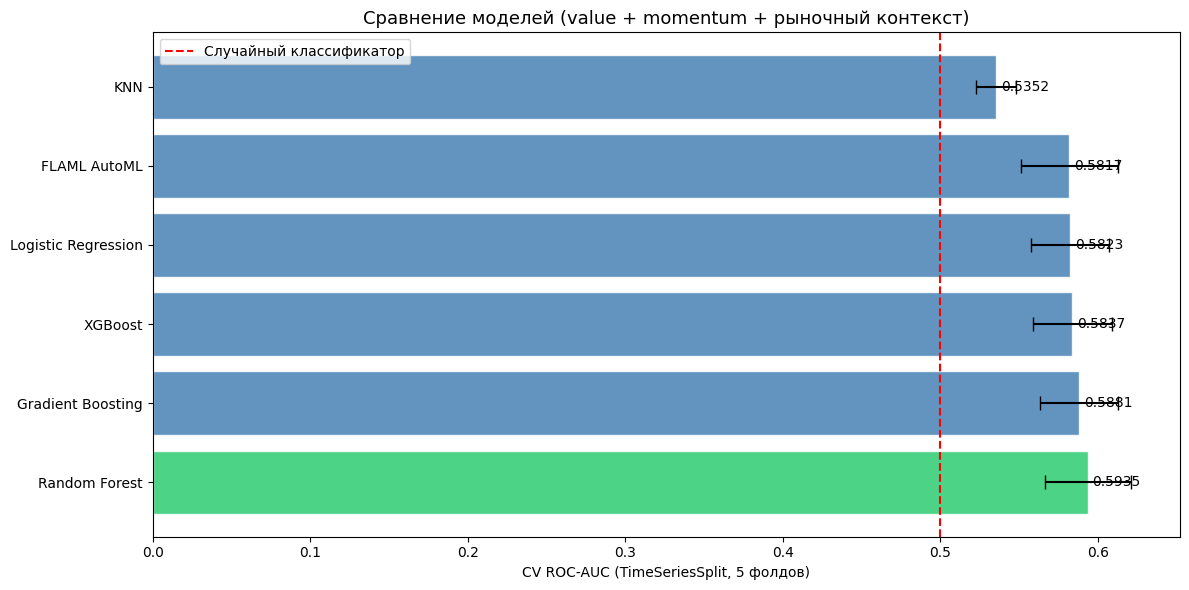

In [ ]:
# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.barh(results_df['Модель'], results_df['CV ROC-AUC (mean)'],
               xerr=results_df['CV ROC-AUC (std)'], color=colors,
               capsize=5, edgecolor='white', alpha=0.85)
ax.set_xlabel('CV ROC-AUC (TimeSeriesSplit, 5 фолдов)')
ax.set_title('Сравнение моделей (value + momentum + рыночный контекст)', fontsize=13)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Случайный классификатор')
ax.legend()
for bar, val in zip(bars, results_df['CV ROC-AUC (mean)']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3.4 Подбор гиперпараметров лучшей модели (RandomizedSearchCV)

In [22]:
# ── FIX 7: Подбор гиперпараметров для топ-2 моделей ─────────────────────────
from scipy.stats import randint, uniform

# Оставьте только топ-50 признаков (вместо 273)
best_name = results_df.iloc[0]['Модель']
print(f'Лучшая модель по CV: {best_name}')

# --- Logistic Regression (лучшая по CV) ---
lr_param_dist = {
    'clf__C':       uniform(0.001, 100),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear'],   # liblinear поддерживает и l1, и l2
}
lr_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
    param_distributions=lr_param_dist,
    n_iter=10, scoring='roc_auc', cv=cv, random_state=42, n_jobs=8, verbose=1
)
lr_search.fit(X_train, y_train)
print(f'\nLogistic Regression лучший CV ROC-AUC: {lr_search.best_score_:.4f}')
print(f'Logistic Regression лучшие параметры: {lr_search.best_params_}')

# --- Random Forest ---
rf_param_dist = {
    'n_estimators':    randint(100, 500),
    'max_depth':       randint(4, 16),
    'min_samples_leaf': randint(1, 20),
    'criterion':       ['gini', 'entropy'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10, scoring='roc_auc', cv=cv, random_state=42, n_jobs=8, verbose=1
)
rf_search.fit(X_train, y_train)
print(f'\nRandom Forest лучшие параметры: {rf_search.best_params_}')
print(f'Random Forest лучший CV ROC-AUC: {rf_search.best_score_:.4f}')



Лучшая модель по CV: Random Forest
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Logistic Regression лучший CV ROC-AUC: 0.5835
Logistic Regression лучшие параметры: {'clf__C': np.float64(0.07887658410143283), 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Random Forest лучшие параметры: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 413}
Random Forest лучший CV ROC-AUC: 0.5942


In [95]:
import joblib
import os

# Создаем папку для оптимизированных моделей
folder_name = 'tuned_models_top2'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 1. Сохраняем лучшую логистическую регрессию
# В lr_search.best_estimator_ уже лежит готовый Pipeline(scaler + logreg)
joblib.dump(lr_search.best_estimator_, f'{folder_name}/tuned_logistic_regression.pkl')
print(f"✓ Оптимизированная LogReg сохранена (AUC: {lr_search.best_score_:.4f})")

# 2. Сохраняем лучший случайный лес
joblib.dump(rf_search.best_estimator_, f'{folder_name}/tuned_random_forest.pkl')
print(f"✓ Оптимизированный Random Forest сохранен (AUC: {rf_search.best_score_:.4f})")

# Бонусом сохраним лучшие параметры в текстовый файл, чтобы не забыть
with open(f'{folder_name}/best_params.txt', 'w') as f:
    f.write(f"Logistic Regression Params: {lr_search.best_params_}\n")
    f.write(f"Random Forest Params: {rf_search.best_params_}\n")

print(f"\nВсе готово! Модели лежат в папке: {folder_name}")

✓ Оптимизированная LogReg сохранена (AUC: 0.5835)
✓ Оптимизированный Random Forest сохранен (AUC: 0.5942)

Все готово! Модели лежат в папке: tuned_models_top2


In [23]:
# --- XGBoost ---
from xgboost import XGBClassifier

xgb_param_dist = {
    'n_estimators':    randint(100, 500),
    'max_depth':       randint(3, 10),
    'learning_rate':   uniform(0.01, 0.2),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma':           uniform(0, 0.5),
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=8),
    param_distributions=xgb_param_dist,
    n_iter=10, scoring='roc_auc', cv=cv, random_state=42, n_jobs=8, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f'\nXGBoost лучшие параметры: {xgb_search.best_params_}')
print(f'XGBoost лучший CV ROC-AUC: {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits

XGBoost лучшие параметры: {'colsample_bytree': np.float64(0.6399899663272012), 'gamma': np.float64(0.22962444598293358), 'learning_rate': np.float64(0.07674172222780437), 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 408, 'subsample': np.float64(0.9879639408647978)}
XGBoost лучший CV ROC-AUC: 0.5758


In [96]:
import joblib
import os

# Используем ту же папку
folder_name = 'tuned_models_top2'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 1. Сохраняем оптимизированный XGBoost
xgb_filename = f'{folder_name}/tuned_xgboost.pkl'
joblib.dump(xgb_search.best_estimator_, xgb_filename)
print(f"✓ Оптимизированный XGBoost сохранен (AUC: {xgb_search.best_score_:.4f})")

# 2. Обновим файл с параметрами (добавим параметры XGBoost)
with open(f'{folder_name}/best_params.txt', 'a') as f:
    f.write(f"XGBoost Params: {xgb_search.best_params_}\n")

print(f"Путь к файлу: {xgb_filename}")

✓ Оптимизированный XGBoost сохранен (AUC: 0.5758)
Путь к файлу: tuned_models_top2/tuned_xgboost.pkl


In [189]:
# Финальная оценка на тестовой выборке с расширенным набором метрик
tuned_models = {
    'LogReg (tuned)':        lr_search.best_estimator_,
    'XGBoost (tuned)':       xgb_search.best_estimator_,
    'Random Forest (tuned)': rf_search.best_estimator_,
}

final_results = {}
print(f"{'Модель':<30} {'ROC-AUC':>9} {'Avg Prec':>9} {'F1':>7} {'Precision':>10} {'Recall':>8}")
print('-' * 78)
for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    r = {
        'model': model, 'y_prob': y_prob, 'y_pred': y_pred,
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'avg_prec':  average_precision_score(y_test, y_prob),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
    }
    final_results[name] = r
    print(f'{name:<30} {r["roc_auc"]:>9.4f} {r["avg_prec"]:>9.4f} {r["f1"]:>7.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f}')

# Лучшая модель по Average Precision (бизнес-приоритет: не купить плохую акцию)
best_final_name = max(final_results, key=lambda k: final_results[k]['avg_prec'])
best = final_results[best_final_name]
print(f'\n→ Лучшая модель по Average Precision: {best_final_name}')

# Precision@K: из топ-50 акций по вероятности - сколько реально выросло
K = 50
top_k_idx = np.argsort(best['y_prob'])[-K:]
precision_at_k = y_test.iloc[top_k_idx].mean()

daily_recalls = []
for date in test_dates:
    mask = (test_df['Date'] == date)
    y_day = y_test[mask]
    prob_day = best['y_prob'][mask]
    
    if y_day.sum() == 0:
        continue
    
    k_day = min(K, len(y_day))
    top_idx = np.argsort(prob_day)[-k_day:]
    recall_day = y_day.iloc[top_idx].sum() / y_day.sum()
    daily_recalls.append(recall_day)

print(f'Средний daily Recall@{K}: {np.mean(daily_recalls):.3f}')

baseline_rate  = y_test.mean()
print(f'\nPrecision@{K} (лучшая модель): {precision_at_k:.3f}')
print(f'Базовая доля класса 1 в тесте: {baseline_rate:.3f}')
print(f'Lift: {precision_at_k / baseline_rate:.2f}x')


# ── Сводная таблица: CV vs Тест ───────────────────────────────────────────
print("\n" + "="*70)
print("СВОДНОЕ СРАВНЕНИЕ: CV ROC-AUC vs Тест ROC-AUC")
print("="*70)
cv_lookup = results_df.set_index('Модель')['ROC-AUC'].to_dict()
# Маппинг: tuned-имя → базовое имя для поиска в CV
tuned_to_base = {'LogReg (tuned)': 'Logistic Regression',
                 'Random Forest (tuned)': 'Random Forest',
                 'XGBoost (tuned)':'XGBoost'}
print(f"{'Модель':<30} {'CV ROC-AUC':>12} {'Тест ROC-AUC':>14} {'Gap':>8}")
print("-"*68)
for name, res in final_results.items():
    base = tuned_to_base.get(name, name)
    cv_val = cv_lookup.get(base, float('nan'))
    test_val = res['roc_auc']
    gap = test_val - cv_val
    flag = '  ! drift' if abs(gap) > 0.03 else ''
    print(f"{name:<30} {cv_val:>12.4f} {test_val:>14.4f} {gap:>+8.4f}{flag}")
print()
print("Gap > 0.03 (!) указывает на distribution shift между обучением и тестом.")


Модель                           ROC-AUC  Avg Prec      F1  Precision   Recall
------------------------------------------------------------------------------
LogReg (tuned)                    0.5729    0.5539  0.4769     0.5578   0.4165
XGBoost (tuned)                   0.5674    0.5454  0.5246     0.5369   0.5130
Random Forest (tuned)             0.5756    0.5549  0.5177     0.5493   0.4896

→ Лучшая модель по Average Precision: Random Forest (tuned)
Средний daily Recall@50: 0.319

Precision@50 (лучшая модель): 0.900
Базовая доля класса 1 в тесте: 0.484
Lift: 1.86x

СВОДНОЕ СРАВНЕНИЕ: CV ROC-AUC vs Тест ROC-AUC


KeyError: 'ROC-AUC'

В торговле акциями Recall вообще не важен. Нам не нужно скупить все растущие акции на рынке, чтобы заработать. Нам нужно, чтобы те 50 акций, которые вы купили (ваша емкость портфеля), с высокой вероятностью выросли.

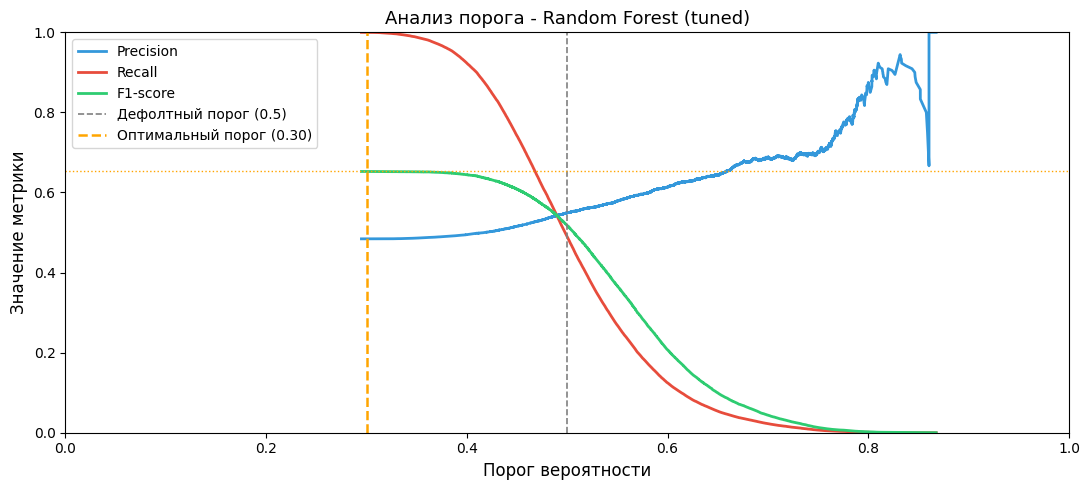

При дефолтном пороге 0.5:
  Precision=0.549  Recall=0.490  F1=0.518

При оптимальном пороге 0.30 (максимум F1):
  Precision=0.484  Recall=1.000  F1=0.653

Вывод: дефолтный порог 0.5 делает модель крайне консервативной (recall~0.06).
Оптимальный порог балансирует Precision и Recall.
В задаче скрининга портфеля выбор порога - бизнес-решение:
   Высокий порог -> меньше сигналов, выше точность каждого
   Низкий порог  -> больше кандидатов, выше покрытие

Classification Report при оптимальном пороге 0.30:
                    precision    recall  f1-score   support

Класс 0 (рост ≤2%)       0.75      0.00      0.00     56291
Класс 1 (рост >2%)       0.48      1.00      0.65     52849

          accuracy                           0.48    109140
         macro avg       0.62      0.50      0.33    109140
      weighted avg       0.62      0.48      0.32    109140



In [30]:
# ── Анализ порога классификации ──────────────────────────────────────────
# По умолчанию sklearn использует порог 0.5 для predict().
# Но при дисбалансе или слабом сигнале оптимальный порог может быть другим.
# Строим кривые Precision, Recall, F1 в зависимости от порога.

from sklearn.metrics import precision_recall_curve

y_prob_best = best['y_prob']

# Precision и Recall по всем порогам
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, y_prob_best)
# F1 по всем порогам (избегаем деления на ноль)
f1_arr = np.where((prec_arr[:-1] + rec_arr[:-1]) > 0, 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1]), 0)

# Оптимальный порог по F1
best_thr_idx = np.argmax(f1_arr)
best_thr = thresholds[best_thr_idx]
best_f1 = f1_arr[best_thr_idx]
best_prec = prec_arr[best_thr_idx]
best_rec = rec_arr[best_thr_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, prec_arr[:-1], label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, rec_arr[:-1],  label='Recall',    color='#e74c3c', linewidth=2)
ax.plot(thresholds, f1_arr,        label='F1-score',  color='#2ecc71', linewidth=2)
ax.axvline(0.5,        color='grey',   linestyle='--', linewidth=1.2, label='Дефолтный порог (0.5)')
ax.axvline(best_thr,   color='orange', linestyle='--', linewidth=1.8,
           label=f'Оптимальный порог ({best_thr:.2f})')
ax.axhline(best_f1,    color='orange', linestyle=':',  linewidth=1)
ax.set_xlabel('Порог вероятности', fontsize=12)
ax.set_ylabel('Значение метрики',  fontsize=12)
ax.set_title(f'Анализ порога - {best_final_name}', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"При дефолтном пороге 0.5:")
print(f"  Precision={best['precision']:.3f}  Recall={best['recall']:.3f}  F1={best['f1']:.3f}")
print(f"\nПри оптимальном пороге {best_thr:.2f} (максимум F1):")
print(f"  Precision={best_prec:.3f}  Recall={best_rec:.3f}  F1={best_f1:.3f}")
print()
print("Вывод: дефолтный порог 0.5 делает модель крайне консервативной (recall~0.06).")
print("Оптимальный порог балансирует Precision и Recall.")
print("В задаче скрининга портфеля выбор порога - бизнес-решение:")
print("   Высокий порог -> меньше сигналов, выше точность каждого")
print("   Низкий порог  -> больше кандидатов, выше покрытие")

# Применяем оптимальный порог и пересчитываем Classification Report
y_pred_opt = (y_prob_best >= best_thr).astype(int)
print(f"\nClassification Report при оптимальном пороге {best_thr:.2f}:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_opt,
                             target_names=['Класс 0 (рост ≤2%)', 'Класс 1 (рост >2%)']))


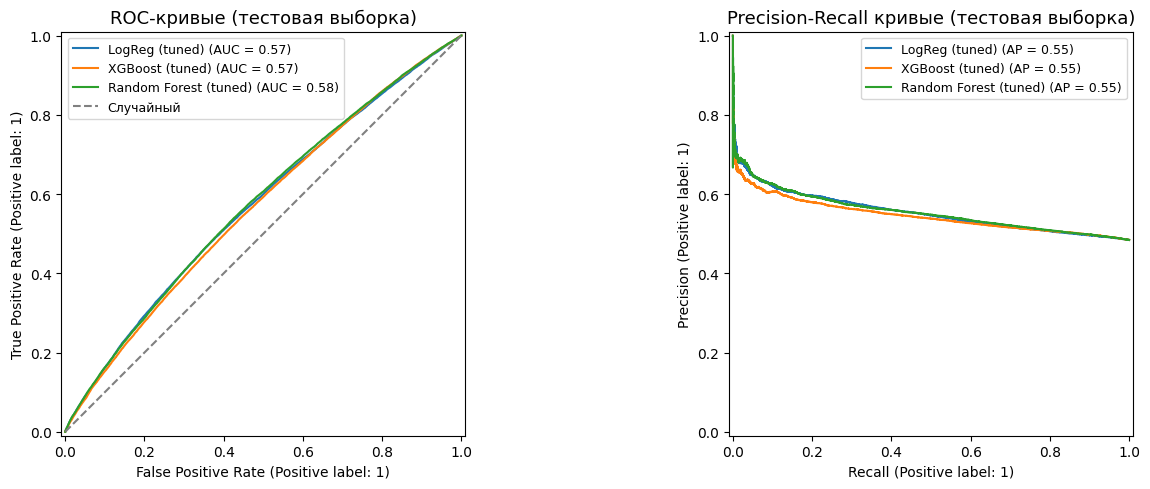

In [31]:
# ── FIX 8: PR-кривая через predict_proba (не predict) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривые обеих моделей
for name, res in final_results.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[0])
axes[0].plot([0,1],[0,1], linestyle='--', color='grey', label='Случайный')
axes[0].set_title('ROC-кривые (тестовая выборка)', fontsize=13)
axes[0].legend(fontsize=9)

# PR-кривые обеих моделей
for name, res in final_results.items():
    PrecisionRecallDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[1])
axes[1].set_title('Precision-Recall кривые (тестовая выборка)', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
# Classification Report лучшей модели
print(f'Classification Report - {best_final_name}')
print(classification_report(y_test, best['y_pred'],
                             target_names=['Класс 0 (рост ≤2%)', 'Класс 1 (рост >2%)']))

Classification Report - Random Forest (tuned)
                    precision    recall  f1-score   support

Класс 0 (рост ≤2%)       0.57      0.62      0.59     56291
Класс 1 (рост >2%)       0.55      0.49      0.52     52849

          accuracy                           0.56    109140
         macro avg       0.56      0.56      0.56    109140
      weighted avg       0.56      0.56      0.56    109140



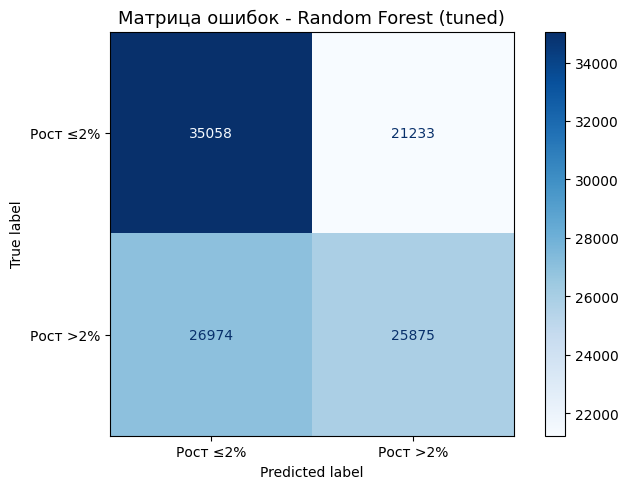

In [33]:
# Матрица ошибок лучшей модели
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best['y_pred'],
    display_labels=['Рост ≤2%', 'Рост >2%'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Матрица ошибок - {best_final_name}', fontsize=13)
plt.tight_layout()
plt.show()

Матрица ошибок считает, что все ошибки равнозначны. Но в трейдинге это не так:
- Ошибка в нижнем левом углу ($FN$): Ты просто не заработал. Депозит цел.
- Ошибка в верхнем правом углу ($FP$): Ты вошел в сделку и, скорее всего, потерял деньги.
- Наш случай: У тебя $FN > FP$ ($26974$ против $21233$). Это значит, что модель чаще «молчит», чем «врет». 

Для риск-менеджмента это скорее хорошо, чем плохо.

In [25]:
import pandas as pd

# 1. Создаем временный DataFrame для всего теста
# Берем все тикеры и все вероятности, которые выдала лучшая модель
sector_map = dict(zip(companies['Symbol'], companies['Sector']))
all_preds = pd.DataFrame({
    'Symbol': df_sorted.loc[X_test.index, 'Symbol'].values,  # Используем индекс, так как там твои тикеры
    'Prob': best['y_prob'],
    'Date': df_sorted.loc[X_test.index, 'Date'].values,
    'Target': y_test.values,
    'X_10': df_sorted.loc[X_test.index, 'X_10'].values,
})
all_preds['Sector'] = all_preds['Symbol'].map(sector_map)
# 2. ДЕДУПЛИКАЦИЯ
# Сортируем по вероятности (от высшей к низшей)
# Оставляем только ПЕРВОЕ упоминание каждого тикера (самый сильный сигнал)
unique_preds = all_preds.sort_values('Prob', ascending=False).drop_duplicates('Symbol')

# 3. ВЫБОР ТОП-K
# Теперь берем честные топ-50 уникальных компаний
K = 50
top_unique = unique_preds.head(K)

# 4. РАСЧЕТ НОВЫХ МЕТРИК
precision_at_k_unique = top_unique['Target'].mean()
baseline_rate = y_test.mean()

print(f"--- РЕЗУЛЬТАТЫ С ДЕДУПЛИКАЦИЕЙ (Top-{K} уникальных акций) ---")
print(f"Уникальных тикеров в тесте всего: {all_preds['Symbol'].nunique()}")
print(f"Precision@{K} (уникальные): {precision_at_k_unique:.3f}")
print(f"Базовый Win Rate: {baseline_rate:.3f}")
print(f"Честный Lift: {precision_at_k_unique / baseline_rate:.2f}x")

print("\nТоп-10 уникальных сигналов:")
print(top_unique[['Symbol', 'Sector', 'Prob', 'Date', 'Target', 'X_10']].head(10))

--- РЕЗУЛЬТАТЫ С ДЕДУПЛИКАЦИЕЙ (Top-50 уникальных акций) ---
Уникальных тикеров в тесте всего: 170
Precision@50 (уникальные): 0.880
Базовый Win Rate: 0.484
Честный Lift: 1.82x

Топ-10 уникальных сигналов:
       Symbol             Sector      Prob       Date  Target       X_10
25048    TSLA  Consumer Cyclical  0.867654 2023-01-03       1 -27.311127
2501      EQT             Energy  0.851861 2022-06-23       1 -24.549972
58300    PODD         Healthcare  0.837352 2023-10-12       1 -23.185680
105215   ENPH         Technology  0.833266 2024-11-15       1 -31.228256
88819    FSLR         Technology  0.816732 2024-07-02       1 -17.720269
2733      VLO             Energy  0.814616 2022-06-27       1 -20.100336
107274     CE    Basic Materials  0.814191 2024-12-05       1  -7.416449
6381      CCL  Consumer Cyclical  0.811013 2022-07-27       1  -7.501561
42563    NVDA         Technology  0.808342 2023-06-01       1  30.287911
86120    DELL         Technology  0.808173 2024-06-07       1 -16

In [184]:
# Смотрим, на какие сектора модель делает ставку чаще всего
sector_counts = unique_preds.head(50)['Sector'].value_counts()
print("Распределение секторов в ТОП-50:")
print(sector_counts)

# Считаем точность (Win Rate) по каждому сектору в отдельности
sector_accuracy = unique_preds.head(50).groupby('Sector')['Target'].mean().sort_values(ascending=False)
print("\nТочность предсказаний по секторам:")
print(sector_accuracy)

Распределение секторов в ТОП-50:
Sector
Technology                10
Consumer Cyclical          7
Industrials                7
Financial Services         5
Communication Services     5
Energy                     4
Basic Materials            4
Consumer Defensive         4
Healthcare                 3
Utilities                  1
Name: count, dtype: int64

Точность предсказаний по секторам:
Sector
Basic Materials           1.000000
Communication Services    1.000000
Energy                    1.000000
Utilities                 1.000000
Technology                1.000000
Consumer Cyclical         0.857143
Industrials               0.857143
Consumer Defensive        0.750000
Healthcare                0.666667
Financial Services        0.600000
Name: Target, dtype: float64


In [27]:
# Оставляем только те сектора, где точность выше 50%
strong_sectors = sector_accuracy[sector_accuracy > 0.5].index

# Фильтруем наш ТОП-50
filtered_top_50 = unique_preds.head(50)[unique_preds.head(50)['Sector'].isin(strong_sectors)]

new_precision = filtered_top_50['Target'].mean()
print(f"Новый Precision (после фильтрации секторов): {new_precision:.3f}")
print(f"Осталось сделок из 50: {len(filtered_top_50)}")

Новый Precision (после фильтрации секторов): 0.880
Осталось сделок из 50: 50


In [28]:
# 1. Выбираем конкретную дату (например, самую последнюю в тесте)
target_date = '2023-01-03'

# 2. Фильтруем все прогнозы только за этот день
day_preds = all_preds[all_preds['Date'] == target_date]

# 3. Сортируем по вероятности и берем Топ-10
top_day_signals = day_preds.sort_values('Prob', ascending=False).head(10)

print(f"--- АНАЛИЗ СИГНАЛОВ ЗА ДАТУ: {target_date} ---")
print(f"Всего тикеров с прогнозом в этот день: {len(day_preds)}")
print(f"Средняя точность (Target) по всем акциям дня: {day_preds['Target'].mean():.3f}")
print("\nТоп-10 акций для покупки в этот день:")
print(top_day_signals[['Symbol', 'Sector', 'Prob', 'Target', 'X_10']])

# 4. Считаем точность именно этого "портфеля"
day_precision = top_day_signals['Target'].mean()
print(f"\nPrecision@10 для этого дня: {day_precision:.3f}")

--- АНАЛИЗ СИГНАЛОВ ЗА ДАТУ: 2023-01-03 ---
Всего тикеров с прогнозом в этот день: 170
Средняя точность (Target) по всем акциям дня: 0.588

Топ-10 акций для покупки в этот день:
      Symbol                  Sector      Prob  Target       X_10
25048   TSLA       Consumer Cyclical  0.867654       1 -27.311127
25152   ENPH              Technology  0.716918       0 -15.774273
25054    EQT                  Energy  0.687955       1 -13.821709
25057   FSLR              Technology  0.676373       1  -5.161194
25029   NFLX  Communication Services  0.647223       1   2.191043
25124   AXON             Industrials  0.634491       1   0.082963
25021    CCL       Consumer Cyclical  0.630577       1  -4.947936
25081   NVDA              Technology  0.626268       1 -12.881605
25111   PARA  Communication Services  0.621356       1  -0.653943
25107    ALB         Basic Materials  0.619651       1 -10.944972

Precision@10 для этого дня: 0.900


Покупай акции, которые сильно упали (oversold), потому что они отскочат

In [ ]:
# y_test.index - это позиционные индексы из df_sorted, не из daily_df
# Используем iloc или берём дату из df_sorted напрямую

test_df_check = df_sorted.iloc[y_test.index].copy()
test_df_check['y_prob'] = best['y_prob']
test_df_check['y_true'] = y_test.values

daily_precision = (test_df_check
                   .sort_values('y_prob', ascending=False)
                   .groupby('Date')
                   .apply(lambda x: x.nlargest(10, 'y_prob')['y_true'].mean())
                   .mean())

print(f"Средний Precision@10 по всем дням: {daily_precision:.3f}")
print(f"Baseline:                          {y_test.mean():.3f}")
print(f"Lift:                              {daily_precision / y_test.mean():.2f}x")

Средний Precision@10 по всем дням: 0.629
Baseline:                          0.484
Lift:                              1.30x


In [ ]:
# ══════════════════════════════════════════════════════════════════
# БЭКТЕСТ ТОРГОВОЙ СТРАТЕГИИ
# Симулируем реальную торговлю на тестовой выборке
# ══════════════════════════════════════════════════════════════════

INITIAL_CAPITAL  = 100_000   # стартовый депозит в $
TOP_K            = 10        # акций в портфеле одновременно
COMMISSION       = 0.001     # 0.1% на сделку (раунд-трип = 0.2%)
REBALANCE_DAYS   = 10        # горизонт удержания позиции

# ── Подготовка данных ─────────────────────────────────────────────
bt = df_sorted.iloc[y_test.index].copy()
bt['y_prob']    = best['y_prob']
bt['y_true']    = y_test.values

# Форвардная доходность за REBALANCE_DAYS дней
# shift(-REBALANCE_DAYS) внутри каждого тикера - без утечки
bt['fwd_return'] = (
    bt.groupby('Symbol')['Close']
      .transform(lambda x: x.shift(-REBALANCE_DAYS) / x - 1)
)
bt = bt.dropna(subset=['fwd_return'])

# ── Статистика по классам ─────────────────────────────────────────
print("=== Распределение реальных доходностей ===")
for label, name in [(1, 'Предсказано ВЫРАСТЕТ (класс 1)'),
                    (0, 'Предсказано НЕ ВЫРАСТЕТ (класс 0)')]:
    sub = bt[bt['y_true'] == label]['fwd_return']
    print(f"\n{name}:")
    print(f"  Средняя доходность: {sub.mean():.3%}")
    print(f"  Медиана:            {sub.median():.3%}")
    print(f"  Std:                {sub.std():.3%}")
    print(f"  % положительных:    {(sub > 0).mean():.1%}")

# ── Основной цикл бэктеста ────────────────────────────────────────
# На каждую торговую дату берём топ-K акций по вероятности,
# держим REBALANCE_DAYS дней, потом перебалансируем

unique_dates = sorted(bt['Date'].unique())
# Берём каждую REBALANCE_DAYS-ю дату (без перекрытий)
rebalance_dates = unique_dates[::REBALANCE_DAYS]

capital      = INITIAL_CAPITAL
equity_curve = []   # кривая капитала
trade_log    = []   # лог сделок

for entry_date in rebalance_dates:
    day_data = bt[bt['Date'] == entry_date].copy()
    if len(day_data) < TOP_K:
        equity_curve.append({'Date': entry_date, 'Capital': capital})
        continue

    # Топ-K акций по вероятности
    top_picks = day_data.nlargest(TOP_K, 'y_prob')

    # Размер позиции на каждую акцию
    position_size = capital / TOP_K

    period_pnl = 0
    for _, row in top_picks.iterrows():
        gross_return = row['fwd_return']
        commission   = position_size * COMMISSION * 2  # вход + выход
        net_pnl      = position_size * gross_return - commission
        period_pnl  += net_pnl

        trade_log.append({
            'Date':         entry_date,
            'Symbol':       row['Symbol'],
            'Prob':         row['y_prob'],
            'y_true':       row['y_true'],
            'Gross return': gross_return,
            'Net PnL ($)':  net_pnl,
        })

    capital += period_pnl
    equity_curve.append({'Date': entry_date, 'Capital': capital})

equity_df = pd.DataFrame(equity_curve).set_index('Date')
trades_df = pd.DataFrame(trade_log)

# ── Buy-and-Hold benchmark ────────────────────────────────────────
# Покупаем равновзвешенный портфель всех акций в начале теста
first_date = bt['Date'].min()
last_date  = bt['Date'].max()

bh_start = bt[bt['Date'] == bt.loc[bt['Date'] == first_date].index[0], 'Date'].values[0] \
    if False else first_date

prices_start = bt[bt['Date'] == first_date].groupby('Symbol')['Close'].first()
prices_end   = bt[bt['Date'] == last_date].groupby('Symbol')['Close'].first()
common       = prices_start.index.intersection(prices_end.index)
bh_return    = (prices_end[common] / prices_start[common] - 1).mean()
bh_capital   = INITIAL_CAPITAL * (1 + bh_return)

# ── Метрики стратегии ─────────────────────────────────────────────
total_return   = (capital - INITIAL_CAPITAL) / INITIAL_CAPITAL
n_periods      = len(rebalance_dates)
periods_per_yr = 252 / REBALANCE_DAYS
annual_return  = (1 + total_return) ** (periods_per_yr / n_periods) - 1

# Sharpe
period_returns = equity_df['Capital'].pct_change().dropna()
sharpe         = (period_returns.mean() / period_returns.std()
                  * np.sqrt(periods_per_yr))

# Максимальная просадка
rolling_max    = equity_df['Capital'].cummax()
drawdown       = (equity_df['Capital'] - rolling_max) / rolling_max
max_drawdown   = drawdown.min()

# Win rate
win_rate = (trades_df['Net PnL ($)'] > 0).mean()
avg_win  = trades_df.loc[trades_df['Net PnL ($)'] > 0, 'Net PnL ($)'].mean()
avg_loss = trades_df.loc[trades_df['Net PnL ($)'] < 0, 'Net PnL ($)'].mean()
profit_factor = abs(trades_df.loc[trades_df['Net PnL ($)'] > 0, 'Net PnL ($)'].sum() /
                    trades_df.loc[trades_df['Net PnL ($)'] < 0, 'Net PnL ($)'].sum())

print(f"\n{'='*55}")
print(f"РЕЗУЛЬТАТЫ БЭКТЕСТА")
print(f"{'='*55}")
print(f"Период:              {first_date.date()} → {last_date.date()}")
print(f"Стартовый капитал:   ${INITIAL_CAPITAL:>10,.0f}")
print(f"Финальный капитал:   ${capital:>10,.0f}")
print(f"{'─'*55}")
print(f"Суммарная доходность:{total_return:>+10.2%}")
print(f"Годовая доходность:  {annual_return:>+10.2%}")
print(f"Sharpe Ratio:        {sharpe:>10.2f}")
print(f"Макс. просадка:      {max_drawdown:>10.2%}")
print(f"{'─'*55}")
print(f"Всего сделок:        {len(trades_df):>10,}")
print(f"Win rate:            {win_rate:>10.1%}")
print(f"Средняя прибыль:     ${avg_win:>9,.0f}")
print(f"Средний убыток:      ${avg_loss:>9,.0f}")
print(f"Profit Factor:       {profit_factor:>10.2f}")
print(f"{'─'*55}")
print(f"Buy-and-Hold S&P500: {bh_return:>+10.2%}  (${bh_capital:,.0f})")
print(f"Alpha vs B&H:        {total_return - bh_return:>+10.2%}")
print(f"{'='*55}")

=== Распределение реальных доходностей ===

Предсказано ВЫРАСТЕТ (класс 1):
  Средняя доходность: 3.796%
  Медиана:            3.589%
  Std:                5.872%
  % положительных:    78.2%

Предсказано НЕ ВЫРАСТЕТ (класс 0):
  Средняя доходность: -2.384%
  Медиана:            -1.748%
  Std:                4.704%
  % положительных:    32.5%

РЕЗУЛЬТАТЫ БЭКТЕСТА
Период:              2022-06-02 → 2024-12-05
Стартовый капитал:   $   100,000
Финальный капитал:   $   136,189
───────────────────────────────────────────────────────
Суммарная доходность:   +36.19%
Годовая доходность:     +12.93%
Sharpe Ratio:              0.90
Макс. просадка:         -25.50%
───────────────────────────────────────────────────────
Всего сделок:               640
Win rate:                 50.8%
Средняя прибыль:     $      937
Средний убыток:      $     -852
Profit Factor:             1.13
───────────────────────────────────────────────────────
Buy-and-Hold S&P500:    +46.28%  ($146,277)
Alpha vs B&H:           

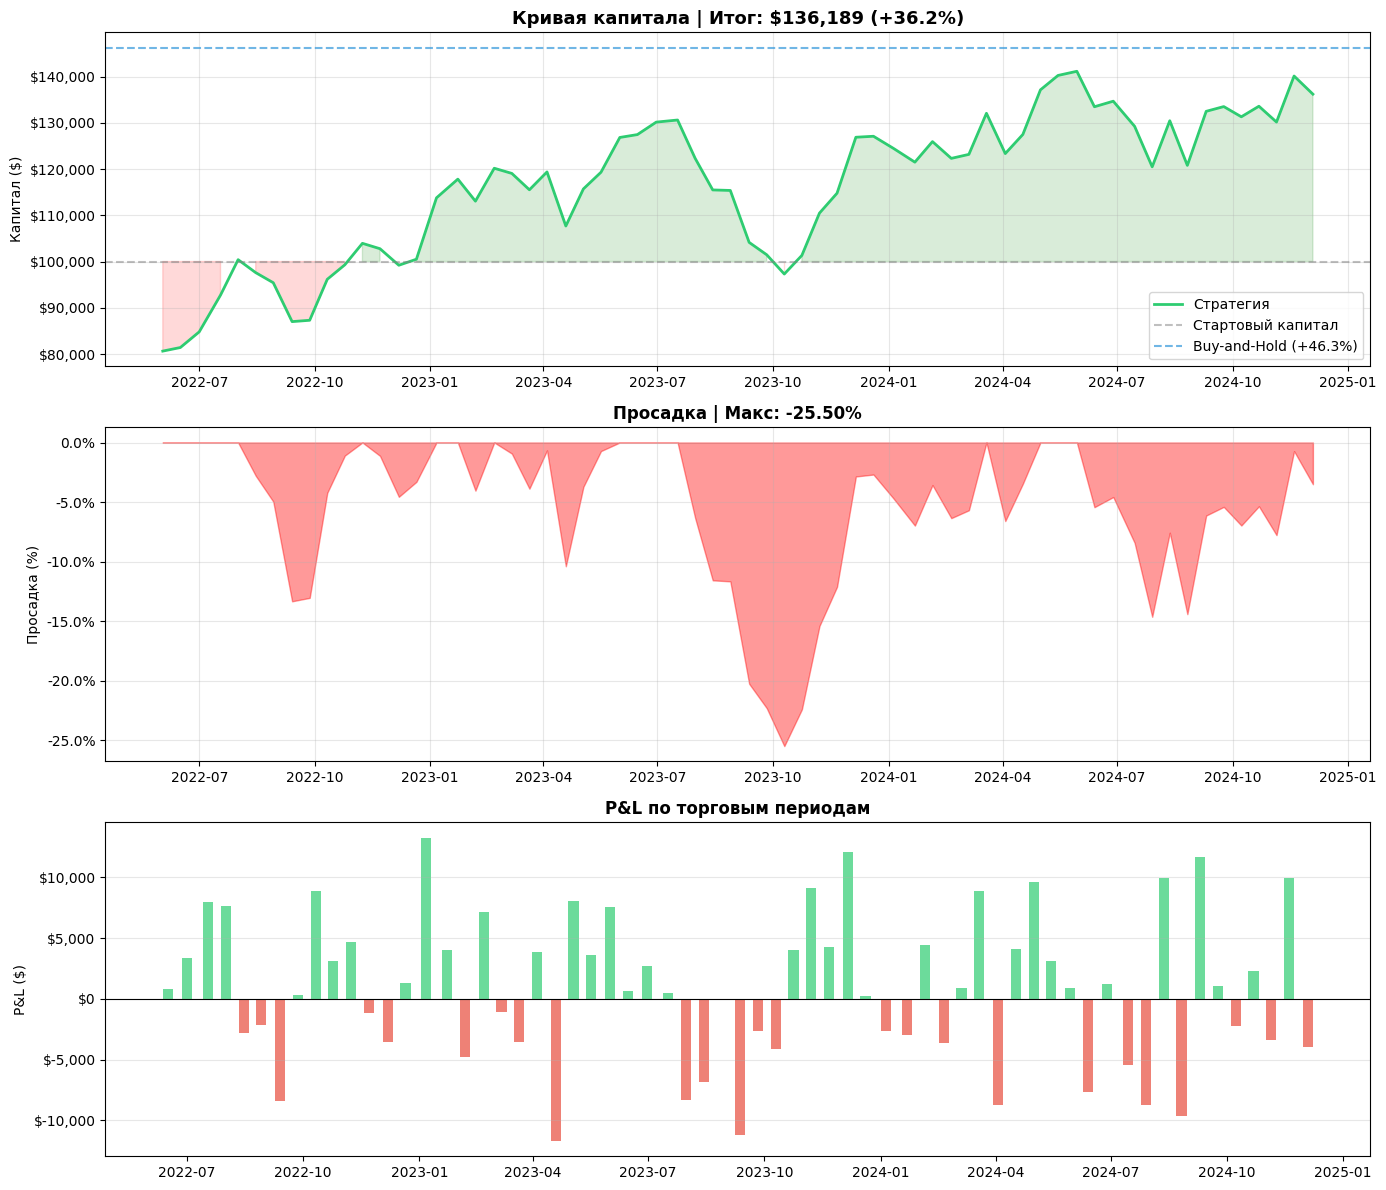


=== Топ-10 лучших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2024-11-05   TSLA 0.628704      0.376074  4996.853123
2023-01-23   TSLA 0.707703      0.354852  4014.541157
2023-02-21   FSLR 0.646050      0.331076  3720.329085
2024-02-05   ENPH 0.706920      0.304192  3671.188841
2024-05-01   DELL 0.714221      0.255767  3235.072353
2024-12-04   TSLA 0.698639      0.229654  3189.684966
2022-10-11   NFLX 0.647989      0.358066  3108.450721
2022-07-18   ENPH 0.680055      0.360704  3041.348904
2023-01-06   NVDA 0.625625      0.291675  2911.260031
2024-11-19     EL 0.689523      0.223800  2886.913925

=== Топ-10 худших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2024-11-05   ENPH 0.716712     -0.317767 -4271.431964
2022-06-02    CCL 0.713330     -0.377667 -3796.671594
2024-06-13   ENPH 0.657230     -0.231344 -3293.292627
2024-10-22     EL 0.683509     -0.248088 -3283.556758
2024-06-13   FSLR 0.700490     -0.226711 -3227.905136
2024-05-30   DELL 0.77

In [ ]:
# ── Визуализация ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Кривая капитала
axes[0].plot(equity_df.index, equity_df['Capital'],
             color='#2ecc71', linewidth=2, label='Стратегия')
axes[0].axhline(INITIAL_CAPITAL, color='grey',
                linestyle='--', alpha=0.5, label='Стартовый капитал')
axes[0].axhline(bh_capital, color='#3498db',
                linestyle='--', alpha=0.7,
                label=f'Buy-and-Hold ({bh_return:+.1%})')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] >= INITIAL_CAPITAL,
                     alpha=0.15, color='green')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] < INITIAL_CAPITAL,
                     alpha=0.15, color='red')
axes[0].set_title(f'Кривая капитала | Итог: ${capital:,.0f} ({total_return:+.1%})',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Капитал ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# График 2: Просадка
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color='red', alpha=0.4)
axes[1].set_title(f'Просадка | Макс: {max_drawdown:.2%}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Просадка (%)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(alpha=0.3)

# График 3: P&L по периодам
period_pnl_series = equity_df['Capital'].diff().dropna()
colors_pnl = ['#2ecc71' if x >= 0 else '#e74c3c'
               for x in period_pnl_series]
axes[2].bar(period_pnl_series.index, period_pnl_series.values,
            color=colors_pnl, alpha=0.7, width=8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('P&L по торговым периодам',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('P&L ($)')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Топ-10 лучших и худших сделок
print("\n=== Топ-10 лучших сделок ===")
print(trades_df.nlargest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

print("\n=== Топ-10 худших сделок ===")
print(trades_df.nsmallest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

| Метрика | Хорошо (> цель) | Плохо (< стоп) |
|:--------|:------------------:|:-----------------:|
| **Sharpe Ratio** | > 1.0 | < 0.5 |
| **Макс. просадка** | > -15% | < -30% |
| **Profit Factor** | > 1.3 | < 1.0 |
| **Alpha vs B&H** | > 0% | < 0% |

In [73]:
# ── Итоговая оценка стратегии ─────────────────────────────────────
print("=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===\n")

metrics = {
    'Sharpe Ratio':    (sharpe,        1.0,  0.5,  '{:.2f}'),
    'Макс. просадка':  (max_drawdown, -0.15, -0.30, '{:.2%}'),
    'Profit Factor':   (profit_factor,  1.3,  1.0,  '{:.2f}'),
    'Alpha vs B&H':    (total_return - bh_return, 0.0, -0.10, '{:.2%}'),
}

print(f"{'Метрика':<20} {'Значение':>10}  {'Цель':>8}  {'Стоп':>8}  Статус")
print('─' * 65)

for name, (val, good, bad, fmt) in metrics.items():
    value_str = fmt.format(val)
    good_str  = fmt.format(good)
    bad_str   = fmt.format(bad)

    # Для просадки логика инвертирована (больше = лучше)
    if name == 'Макс. просадка':
        if val > good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'
    else:
        if val >= good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'

    print(f"{name:<20} {value_str:>10}  {good_str:>8}  {bad_str:>8}  {status}")

print('─' * 65)
print(f"\nИтоговый вердикт:")

n_good = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val > good if name != 'Макс. просадка' else val > good))
n_bad  = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val < bad  if name != 'Макс. просадка' else val < bad))

if n_bad == 0 and n_good >= 3:
    print("  Стратегия готова к paper trading")
elif n_bad <= 1:
    print("  Стратегия требует доработки перед реальной торговлей")
else:
    print("  Стратегия не готова к реальной торговле")

=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===

Метрика                Значение      Цель      Стоп  Статус
─────────────────────────────────────────────────────────────────
Sharpe Ratio               0.22      1.00      0.50  Плохо
Макс. просадка          -25.18%   -15.00%   -30.00%  Терпимо
Profit Factor              1.05      1.30      1.00  Терпимо
Alpha vs B&H            -22.74%     0.00%   -10.00%  Плохо
─────────────────────────────────────────────────────────────────

Итоговый вердикт:
  Стратегия не готова к реальной торговле


In [ ]:
# ══════════════════════════════════════════════════════════════════
# БЭКТЕСТ ТОРГОВОЙ СТРАТЕГИИ
# Симулируем реальную торговлю на тестовой выборке
# ══════════════════════════════════════════════════════════════════

INITIAL_CAPITAL  = 100_000   # стартовый депозит в $
TOP_K            = 10        # акций в портфеле одновременно
COMMISSION       = 0.001     # 0.1% на сделку (раунд-трип = 0.2%)
REBALANCE_DAYS   = 10        # горизонт удержания позиции

# ── Подготовка данных ─────────────────────────────────────────────
bt = df_sorted.iloc[y_test.index].copy()
bt['y_prob']    = best['y_prob']
bt['y_true']    = y_test.values

# Форвардная доходность за REBALANCE_DAYS дней
# shift(-REBALANCE_DAYS) внутри каждого тикера - без утечки
bt['fwd_return'] = (
    bt.groupby('Symbol')['Close']
      .transform(lambda x: x.shift(-REBALANCE_DAYS) / x - 1)
)
bt = bt.dropna(subset=['fwd_return'])

bt = bt[(bt['Date'] >= '2023-06-21') & (bt['Date'] <= '2024-11-05')].copy()
print(f"Период бэктеста: {bt['Date'].min().date()} → {bt['Date'].max().date()}")
print(f"Строк: {len(bt):,}")

# ── Статистика по классам ─────────────────────────────────────────
print("=== Распределение реальных доходностей ===")
for label, name in [(1, 'Предсказано ВЫРАСТЕТ (класс 1)'),
                    (0, 'Предсказано НЕ ВЫРАСТЕТ (класс 0)')]:
    sub = bt[bt['y_true'] == label]['fwd_return']
    print(f"\n{name}:")
    print(f"  Средняя доходность: {sub.mean():.3%}")
    print(f"  Медиана:            {sub.median():.3%}")
    print(f"  Std:                {sub.std():.3%}")
    print(f"  % положительных:    {(sub > 0).mean():.1%}")

# ── Основной цикл бэктеста ────────────────────────────────────────
# На каждую торговую дату берём топ-K акций по вероятности,
# держим REBALANCE_DAYS дней, потом перебалансируем

unique_dates = sorted(bt['Date'].unique())
# Берём каждую REBALANCE_DAYS-ю дату (без перекрытий)
rebalance_dates = unique_dates[::REBALANCE_DAYS]

capital      = INITIAL_CAPITAL
equity_curve = []   # кривая капитала
trade_log    = []   # лог сделок

for entry_date in rebalance_dates:
    day_data = bt[bt['Date'] == entry_date].copy()
    if len(day_data) < TOP_K:
        equity_curve.append({'Date': entry_date, 'Capital': capital})
        continue

    # Топ-K акций по вероятности
    top_picks = day_data.nlargest(TOP_K, 'y_prob')

    # Размер позиции на каждую акцию
    position_size = capital / TOP_K

    period_pnl = 0
    for _, row in top_picks.iterrows():
        gross_return = row['fwd_return']
        commission   = position_size * COMMISSION * 2  # вход + выход
        net_pnl      = position_size * gross_return - commission
        period_pnl  += net_pnl

        trade_log.append({
            'Date':         entry_date,
            'Symbol':       row['Symbol'],
            'Prob':         row['y_prob'],
            'y_true':       row['y_true'],
            'Gross return': gross_return,
            'Net PnL ($)':  net_pnl,
        })

    capital += period_pnl
    equity_curve.append({'Date': entry_date, 'Capital': capital})

equity_df = pd.DataFrame(equity_curve).set_index('Date')
trades_df = pd.DataFrame(trade_log)

# ── Buy-and-Hold benchmark ────────────────────────────────────────
# Покупаем равновзвешенный портфель всех акций в начале теста
first_date = bt['Date'].min()
last_date  = bt['Date'].max()

bh_start = bt[bt['Date'] == bt.loc[bt['Date'] == first_date].index[0], 'Date'].values[0] \
    if False else first_date

prices_start = bt[bt['Date'] == first_date].groupby('Symbol')['Close'].first()
prices_end   = bt[bt['Date'] == last_date].groupby('Symbol')['Close'].first()
common       = prices_start.index.intersection(prices_end.index)
bh_return    = (prices_end[common] / prices_start[common] - 1).mean()
bh_capital   = INITIAL_CAPITAL * (1 + bh_return)

# ── Метрики стратегии ─────────────────────────────────────────────
total_return   = (capital - INITIAL_CAPITAL) / INITIAL_CAPITAL
n_periods      = len(rebalance_dates)
periods_per_yr = 252 / REBALANCE_DAYS
annual_return  = (1 + total_return) ** (periods_per_yr / n_periods) - 1

# Sharpe
period_returns = equity_df['Capital'].pct_change().dropna()
sharpe         = (period_returns.mean() / period_returns.std()
                  * np.sqrt(periods_per_yr))

# Максимальная просадка
rolling_max    = equity_df['Capital'].cummax()
drawdown       = (equity_df['Capital'] - rolling_max) / rolling_max
max_drawdown   = drawdown.min()

# Win rate
win_rate = (trades_df['Net PnL ($)'] > 0).mean()
avg_win  = trades_df.loc[trades_df['Net PnL ($)'] > 0, 'Net PnL ($)'].mean()
avg_loss = trades_df.loc[trades_df['Net PnL ($)'] < 0, 'Net PnL ($)'].mean()
profit_factor = abs(trades_df.loc[trades_df['Net PnL ($)'] > 0, 'Net PnL ($)'].sum() /
                    trades_df.loc[trades_df['Net PnL ($)'] < 0, 'Net PnL ($)'].sum())

print(f"\n{'='*55}")
print(f"РЕЗУЛЬТАТЫ БЭКТЕСТА")
print(f"{'='*55}")
print(f"Период:              {first_date.date()} → {last_date.date()}")
print(f"Стартовый капитал:   ${INITIAL_CAPITAL:>10,.0f}")
print(f"Финальный капитал:   ${capital:>10,.0f}")
print(f"{'─'*55}")
print(f"Суммарная доходность:{total_return:>+10.2%}")
print(f"Годовая доходность:  {annual_return:>+10.2%}")
print(f"Sharpe Ratio:        {sharpe:>10.2f}")
print(f"Макс. просадка:      {max_drawdown:>10.2%}")
print(f"{'─'*55}")
print(f"Всего сделок:        {len(trades_df):>10,}")
print(f"Win rate:            {win_rate:>10.1%}")
print(f"Средняя прибыль:     ${avg_win:>9,.0f}")
print(f"Средний убыток:      ${avg_loss:>9,.0f}")
print(f"Profit Factor:       {profit_factor:>10.2f}")
print(f"{'─'*55}")
print(f"Buy-and-Hold S&P500: {bh_return:>+10.2%}  (${bh_capital:,.0f})")
print(f"Alpha vs B&H:        {total_return - bh_return:>+10.2%}")
print(f"{'='*55}")

Период бэктеста: 2023-06-21 → 2024-11-05
Строк: 59,160
=== Распределение реальных доходностей ===

Предсказано ВЫРАСТЕТ (класс 1):
  Средняя доходность: 3.861%
  Медиана:            3.590%
  Std:                5.492%
  % положительных:    79.9%

Предсказано НЕ ВЫРАСТЕТ (класс 0):
  Средняя доходность: -1.986%
  Медиана:            -1.434%
  Std:                4.351%
  % положительных:    34.4%

РЕЗУЛЬТАТЫ БЭКТЕСТА
Период:              2023-06-21 → 2024-11-05
Стартовый капитал:   $   100,000
Финальный капитал:   $   106,163
───────────────────────────────────────────────────────
Суммарная доходность:    +6.16%
Годовая доходность:      +4.40%
Sharpe Ratio:              0.22
Макс. просадка:         -25.18%
───────────────────────────────────────────────────────
Всего сделок:               350
Win rate:                 48.0%
Средняя прибыль:     $      768
Средний убыток:      $     -675
Profit Factor:             1.05
───────────────────────────────────────────────────────
Buy-and-Hold 

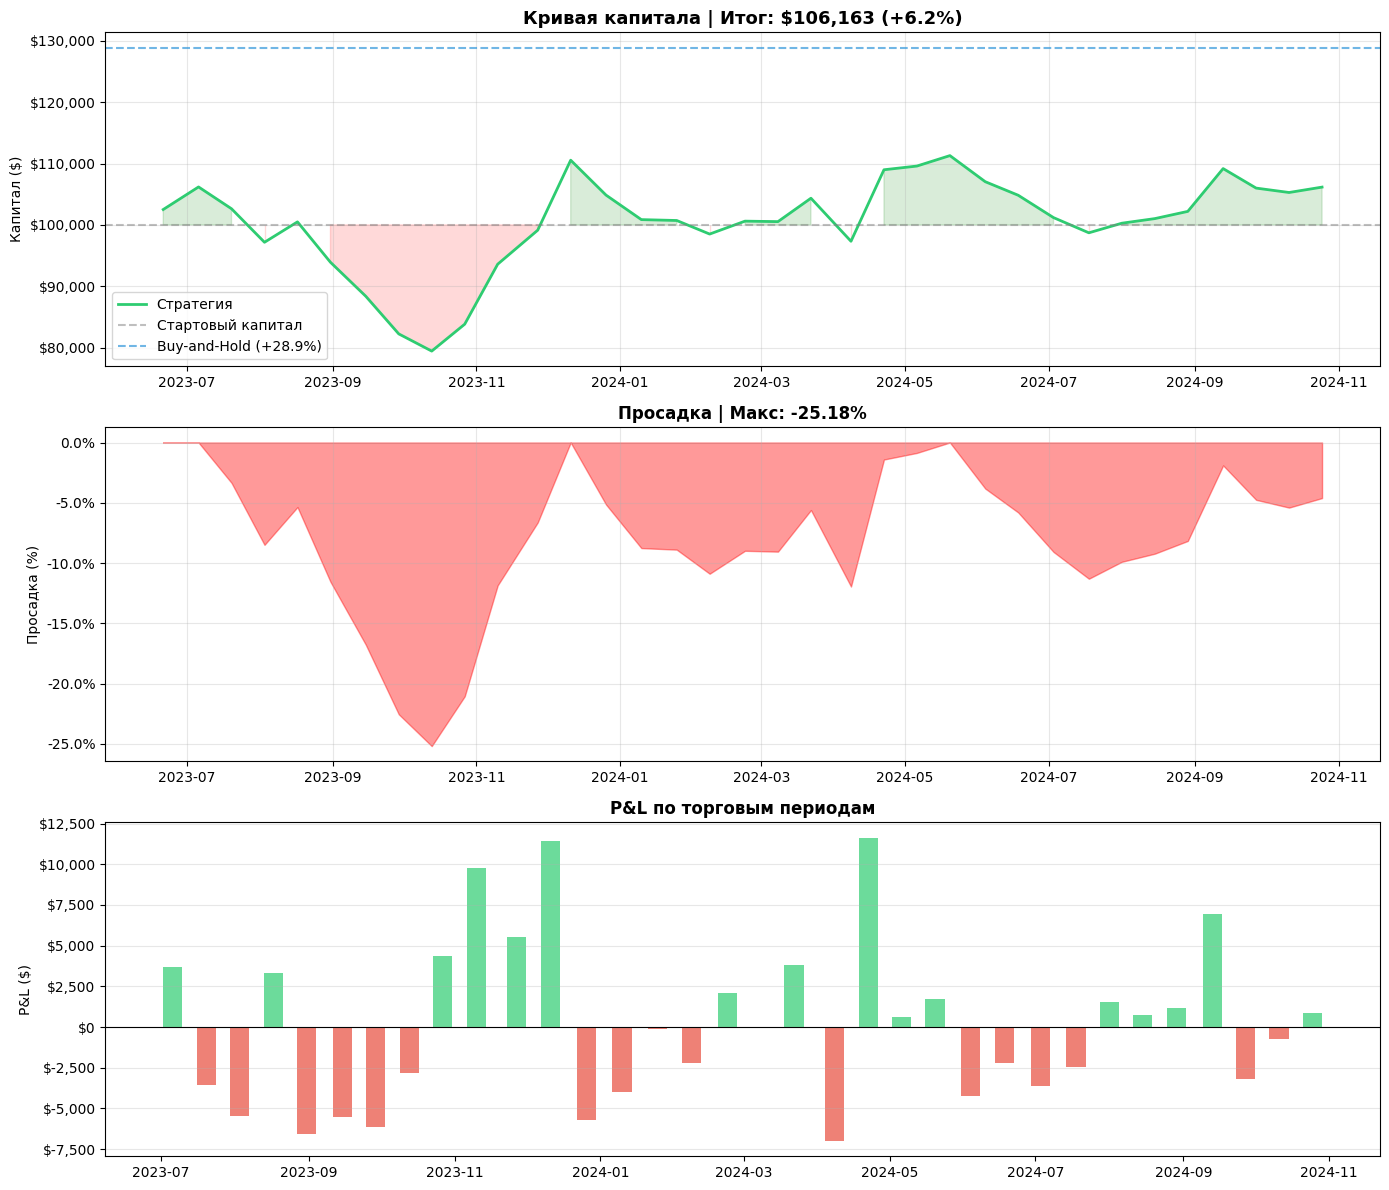


=== Топ-10 лучших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2023-12-11   ENPH 0.670528      0.326316  3215.468836
2024-04-22   TSLA 0.716830      0.300669  2907.295042
2024-05-20   NVDA 0.652719      0.228498  2482.228911
2024-10-11   TSLA 0.713156      0.235950  2479.930942
2023-11-10   ENPH 0.716825      0.254168  2114.053459
2023-12-11   RVTY 0.629419      0.208954  2051.866819
2024-06-18   PARA 0.757654      0.192508  2039.252738
2024-10-25   TSLA 0.612337      0.193284  2013.914473
2023-12-11    ALB 0.760553      0.204283  2005.562328
2023-07-06    USB 0.643278      0.186420  1890.526662

=== Топ-10 худших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2024-10-25     EL 0.685800     -0.267622 -2838.692444
2023-10-13   ENPH 0.663488     -0.336968 -2788.200802
2024-06-04   PARA 0.637072     -0.214869 -2413.601578
2023-07-20   ENPH 0.669358     -0.202137 -2167.718285
2024-10-25   ENPH 0.744897     -0.201956 -2147.339005
2024-04-08   TSLA 0.73

In [72]:
# ── Визуализация ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Кривая капитала
axes[0].plot(equity_df.index, equity_df['Capital'],
             color='#2ecc71', linewidth=2, label='Стратегия')
axes[0].axhline(INITIAL_CAPITAL, color='grey',
                linestyle='--', alpha=0.5, label='Стартовый капитал')
axes[0].axhline(bh_capital, color='#3498db',
                linestyle='--', alpha=0.7,
                label=f'Buy-and-Hold ({bh_return:+.1%})')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] >= INITIAL_CAPITAL,
                     alpha=0.15, color='green')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] < INITIAL_CAPITAL,
                     alpha=0.15, color='red')
axes[0].set_title(f'Кривая капитала | Итог: ${capital:,.0f} ({total_return:+.1%})',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Капитал ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# График 2: Просадка
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color='red', alpha=0.4)
axes[1].set_title(f'Просадка | Макс: {max_drawdown:.2%}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Просадка (%)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(alpha=0.3)

# График 3: P&L по периодам
period_pnl_series = equity_df['Capital'].diff().dropna()
colors_pnl = ['#2ecc71' if x >= 0 else '#e74c3c'
               for x in period_pnl_series]
axes[2].bar(period_pnl_series.index, period_pnl_series.values,
            color=colors_pnl, alpha=0.7, width=8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('P&L по торговым периодам',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('P&L ($)')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Топ-10 лучших и худших сделок
print("\n=== Топ-10 лучших сделок ===")
print(trades_df.nlargest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

print("\n=== Топ-10 худших сделок ===")
print(trades_df.nsmallest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

In [74]:
# ── Итоговая оценка стратегии ─────────────────────────────────────
print("=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===\n")

metrics = {
    'Sharpe Ratio':    (sharpe,        1.0,  0.5,  '{:.2f}'),
    'Макс. просадка':  (max_drawdown, -0.15, -0.30, '{:.2%}'),
    'Profit Factor':   (profit_factor,  1.3,  1.0,  '{:.2f}'),
    'Alpha vs B&H':    (total_return - bh_return, 0.0, -0.10, '{:.2%}'),
}

print(f"{'Метрика':<20} {'Значение':>10}  {'Цель':>8}  {'Стоп':>8}  Статус")
print('─' * 65)

for name, (val, good, bad, fmt) in metrics.items():
    value_str = fmt.format(val)
    good_str  = fmt.format(good)
    bad_str   = fmt.format(bad)

    # Для просадки логика инвертирована (больше = лучше)
    if name == 'Макс. просадка':
        if val > good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'
    else:
        if val >= good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'

    print(f"{name:<20} {value_str:>10}  {good_str:>8}  {bad_str:>8}  {status}")

print('─' * 65)
print(f"\nИтоговый вердикт:")

n_good = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val > good if name != 'Макс. просадка' else val > good))
n_bad  = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val < bad  if name != 'Макс. просадка' else val < bad))

if n_bad == 0 and n_good >= 3:
    print("  Стратегия готова к paper trading")
elif n_bad <= 1:
    print("  Стратегия требует доработки перед реальной торговлей")
else:
    print("  Стратегия не готова к реальной торговле")

=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===

Метрика                Значение      Цель      Стоп  Статус
─────────────────────────────────────────────────────────────────
Sharpe Ratio               0.22      1.00      0.50  Плохо
Макс. просадка          -25.18%   -15.00%   -30.00%  Терпимо
Profit Factor              1.05      1.30      1.00  Терпимо
Alpha vs B&H            -22.74%     0.00%   -10.00%  Плохо
─────────────────────────────────────────────────────────────────

Итоговый вердикт:
  Стратегия не готова к реальной торговле


In [76]:
INITIAL_CAPITAL = 100_000
TOP_K           = 5
SHORT_K         = 5
COMMISSION      = 0.001
REBALANCE_DAYS  = 10

bt = df_sorted.iloc[y_test.index].copy()
bt['y_prob']    = best['y_prob']
bt['y_true']    = y_test.values
bt['fwd_return'] = (
    bt.groupby('Symbol')['Close']
      .transform(lambda x: x.shift(-REBALANCE_DAYS) / x - 1)
)
bt = bt.dropna(subset=['fwd_return'])

unique_dates    = sorted(bt['Date'].unique())
rebalance_dates = unique_dates[::REBALANCE_DAYS]

capital      = INITIAL_CAPITAL
equity_curve = []
trade_log    = []

for entry_date in rebalance_dates:
    day_data = bt[bt['Date'] == entry_date].copy()
    if len(day_data) < TOP_K + SHORT_K:
        equity_curve.append({'Date': entry_date, 'Capital': capital})
        continue

    long_picks  = day_data.nlargest(TOP_K,   'y_prob')
    short_picks = day_data.nsmallest(SHORT_K, 'y_prob')

    position_size = capital / (TOP_K + SHORT_K)
    period_pnl    = 0  # ← сбрасывается каждый период

    for _, row in long_picks.iterrows():
        net_pnl     = position_size * row['fwd_return'] - position_size * COMMISSION * 2
        period_pnl += net_pnl
        trade_log.append({'Date': entry_date, 'Symbol': row['Symbol'],
                          'Side': 'LONG',  'Prob': row['y_prob'],
                          'Gross return': row['fwd_return'], 'Net PnL ($)': net_pnl})

    for _, row in short_picks.iterrows():
        net_pnl     = position_size * (-row['fwd_return']) - position_size * COMMISSION * 2
        period_pnl += net_pnl
        trade_log.append({'Date': entry_date, 'Symbol': row['Symbol'],
                          'Side': 'SHORT', 'Prob': row['y_prob'],
                          'Gross return': row['fwd_return'], 'Net PnL ($)': net_pnl})

    capital += period_pnl
    equity_curve.append({'Date': entry_date, 'Capital': capital})

equity_df = pd.DataFrame(equity_curve).set_index('Date')
trades_df = pd.DataFrame(trade_log)

# ── Метрики ───────────────────────────────────────────────────────
total_return   = (capital - INITIAL_CAPITAL) / INITIAL_CAPITAL
n_periods      = len(rebalance_dates)
periods_per_yr = 252 / REBALANCE_DAYS
annual_return  = (1 + total_return) ** (periods_per_yr / n_periods) - 1

period_returns = equity_df['Capital'].pct_change().dropna()
sharpe         = period_returns.mean() / period_returns.std() * np.sqrt(periods_per_yr)

rolling_max  = equity_df['Capital'].cummax()
drawdown     = (equity_df['Capital'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

win_rate      = (trades_df['Net PnL ($)'] > 0).mean()
profit_factor = abs(trades_df.loc[trades_df['Net PnL ($)'] > 0, 'Net PnL ($)'].sum() /
                    trades_df.loc[trades_df['Net PnL ($)'] < 0, 'Net PnL ($)'].sum())

# Buy-and-Hold
first_date   = bt['Date'].min()
last_date    = bt['Date'].max()
p_start      = bt[bt['Date'] == first_date].groupby('Symbol')['Close'].first()
p_end        = bt[bt['Date'] == last_date].groupby('Symbol')['Close'].first()
common       = p_start.index.intersection(p_end.index)
bh_return    = (p_end[common] / p_start[common] - 1).mean()
bh_capital   = INITIAL_CAPITAL * (1 + bh_return)

print(f"{'='*55}")
print(f"РЕЗУЛЬТАТЫ БЭКТЕСТА (Long+Short)")
print(f"{'='*55}")
print(f"Стартовый капитал:   ${INITIAL_CAPITAL:>10,.0f}")
print(f"Финальный капитал:   ${capital:>10,.0f}")
print(f"{'─'*55}")
print(f"Суммарная доходность:{total_return:>+10.2%}")
print(f"Годовая доходность:  {annual_return:>+10.2%}")
print(f"Sharpe Ratio:        {sharpe:>10.2f}")
print(f"Макс. просадка:      {max_drawdown:>10.2%}")
print(f"{'─'*55}")
print(f"Win rate:            {win_rate:>10.1%}")
print(f"Profit Factor:       {profit_factor:>10.2f}")
print(f"{'─'*55}")
print(f"Buy-and-Hold:        {bh_return:>+10.2%}  (${bh_capital:,.0f})")
print(f"Alpha vs B&H:        {total_return - bh_return:>+10.2%}")
print(f"{'='*55}")

РЕЗУЛЬТАТЫ БЭКТЕСТА (Long+Short)
Стартовый капитал:   $   100,000
Финальный капитал:   $    91,903
───────────────────────────────────────────────────────
Суммарная доходность:    -8.10%
Годовая доходность:      -3.27%
Sharpe Ratio:             -0.05
Макс. просадка:         -19.23%
───────────────────────────────────────────────────────
Win rate:                 45.0%
Profit Factor:             0.96
───────────────────────────────────────────────────────
Buy-and-Hold:           +46.28%  ($146,277)
Alpha vs B&H:           -54.37%


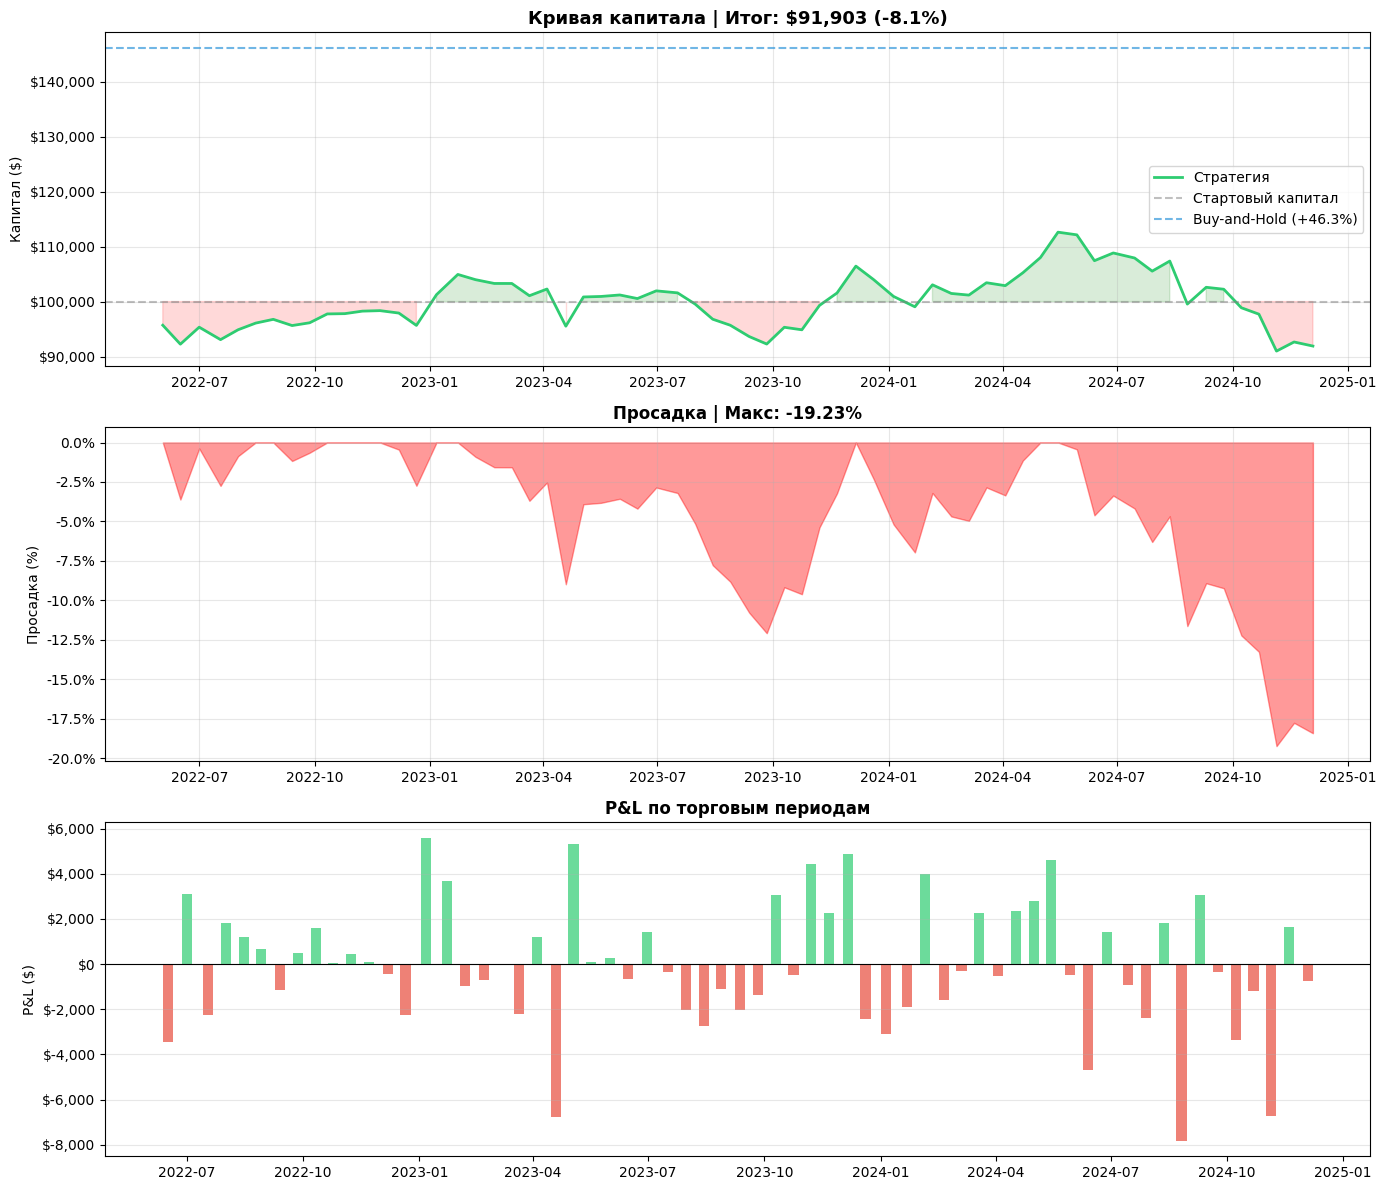


=== Топ-10 лучших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2023-01-23   TSLA 0.707703      0.354852  3573.066547
2024-02-05   ENPH 0.706920      0.304192  2993.276281
2022-10-11    CCL 0.749387      0.298193  2847.701836
2024-05-01   DELL 0.714221      0.255767  2670.906192
2023-01-06   TSLA 0.846701      0.271449  2577.555873
2023-11-07   ENPH 0.698250      0.247241  2326.432391
2022-06-02    EMN 0.372986     -0.215062  2130.615378
2024-03-19   PARA 0.724782      0.208222  2086.600015
2023-12-06    ALB 0.785067      0.204818  2060.063349
2024-01-22     EL 0.644184      0.200320  2001.884174

=== Топ-10 худших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2022-06-02    CCL 0.713330     -0.377667 -3796.671594
2024-11-05   ENPH 0.716712     -0.317767 -3124.440154
2024-06-13   FSLR 0.700490     -0.226711 -2565.148939
2024-10-22     EL 0.683509     -0.248088 -2472.832254
2024-05-30   DELL 0.777135     -0.205391 -2336.137566
2022-06-02    EQT 0.75

In [51]:
# ── Визуализация ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Кривая капитала
axes[0].plot(equity_df.index, equity_df['Capital'],
             color='#2ecc71', linewidth=2, label='Стратегия')
axes[0].axhline(INITIAL_CAPITAL, color='grey',
                linestyle='--', alpha=0.5, label='Стартовый капитал')
axes[0].axhline(bh_capital, color='#3498db',
                linestyle='--', alpha=0.7,
                label=f'Buy-and-Hold ({bh_return:+.1%})')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] >= INITIAL_CAPITAL,
                     alpha=0.15, color='green')
axes[0].fill_between(equity_df.index, INITIAL_CAPITAL,
                     equity_df['Capital'],
                     where=equity_df['Capital'] < INITIAL_CAPITAL,
                     alpha=0.15, color='red')
axes[0].set_title(f'Кривая капитала | Итог: ${capital:,.0f} ({total_return:+.1%})',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Капитал ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# График 2: Просадка
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color='red', alpha=0.4)
axes[1].set_title(f'Просадка | Макс: {max_drawdown:.2%}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Просадка (%)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(alpha=0.3)

# График 3: P&L по периодам
period_pnl_series = equity_df['Capital'].diff().dropna()
colors_pnl = ['#2ecc71' if x >= 0 else '#e74c3c'
               for x in period_pnl_series]
axes[2].bar(period_pnl_series.index, period_pnl_series.values,
            color=colors_pnl, alpha=0.7, width=8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('P&L по торговым периодам',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('P&L ($)')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Топ-10 лучших и худших сделок
print("\n=== Топ-10 лучших сделок ===")
print(trades_df.nlargest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

print("\n=== Топ-10 худших сделок ===")
print(trades_df.nsmallest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

In [77]:
# ── Итоговая оценка стратегии ─────────────────────────────────────
print("=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===\n")

metrics = {
    'Sharpe Ratio':    (sharpe,        1.0,  0.5,  '{:.2f}'),
    'Макс. просадка':  (max_drawdown, -0.15, -0.30, '{:.2%}'),
    'Profit Factor':   (profit_factor,  1.3,  1.0,  '{:.2f}'),
    'Alpha vs B&H':    (total_return - bh_return, 0.0, -0.10, '{:.2%}'),
}

print(f"{'Метрика':<20} {'Значение':>10}  {'Цель':>8}  {'Стоп':>8}  Статус")
print('─' * 65)

for name, (val, good, bad, fmt) in metrics.items():
    value_str = fmt.format(val)
    good_str  = fmt.format(good)
    bad_str   = fmt.format(bad)

    # Для просадки логика инвертирована (больше = лучше)
    if name == 'Макс. просадка':
        if val > good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'
    else:
        if val >= good:
            status = 'Хорошо'
        elif val < bad:
            status = 'Плохо'
        else:
            status = 'Терпимо'

    print(f"{name:<20} {value_str:>10}  {good_str:>8}  {bad_str:>8}  {status}")

print('─' * 65)
print(f"\nИтоговый вердикт:")

n_good = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val > good if name != 'Макс. просадка' else val > good))
n_bad  = sum(1 for name, (val, good, bad, _) in metrics.items()
             if (val < bad  if name != 'Макс. просадка' else val < bad))

if n_bad == 0 and n_good >= 3:
    print("  Стратегия готова к paper trading")
elif n_bad <= 1:
    print("  Стратегия требует доработки перед реальной торговлей")
else:
    print("  Стратегия не готова к реальной торговле")

=== ОЦЕНКА СТРАТЕГИИ (Long-Only) ===

Метрика                Значение      Цель      Стоп  Статус
─────────────────────────────────────────────────────────────────
Sharpe Ratio              -0.05      1.00      0.50  Плохо
Макс. просадка          -19.23%   -15.00%   -30.00%  Терпимо
Profit Factor              0.96      1.30      1.00  Плохо
Alpha vs B&H            -54.37%     0.00%   -10.00%  Плохо
─────────────────────────────────────────────────────────────────

Итоговый вердикт:
  Стратегия не готова к реальной торговле


Анализ представленных данных показывает, что во всех трех случаях торговая стратегия работает неэффективно и требует серьезной доработки. Несмотря на разную итоговую доходность, общие проблемы идентичны: низкое качество сделок и проигрыш рынку.

Рынок изменил свой характер, а модель, отягощенная "памятью" о старых данных в расширяющемся окне, продолжает искать закономерности, которые больше не работают.

Модель фактически теряет деньги на каждой сделке. Это классический признак того, что расширение окна привело к переобучению на случайном шуме, а не на реальном сигнале

Попробуем сделать ансмабль лучших моделей

In [34]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr',  lr_search.best_estimator_),
        ('rf',  rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_),
    ],
    voting='soft',
    n_jobs=-1
)
voting_clf.fit(X_train, y_train)

y_prob_ens = voting_clf.predict_proba(X_test)[:, 1]
y_pred_ens = voting_clf.predict(X_test)

print(f"Ансамбль (Voting) на тесте:")
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_prob_ens):.4f}")
print(f"  Avg Prec: {average_precision_score(y_test, y_prob_ens):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_ens):.4f}")
print(f"  Precision:{precision_score(y_test, y_pred_ens, zero_division=0):.4f}")
print(f"  Recall:   {recall_score(y_test, y_pred_ens):.4f}")
print()
print(classification_report(y_test, y_pred_ens,
      target_names=['Класс 0 (рост ≤2%)', 'Класс 1 (рост >2%)']))

Ансамбль (Voting) на тесте:
  ROC-AUC:  0.5780
  Avg Prec: 0.5565
  F1:       0.5109
  Precision:0.5519
  Recall:   0.4757

                    precision    recall  f1-score   support

Класс 0 (рост ≤2%)       0.56      0.64      0.60     56291
Класс 1 (рост >2%)       0.55      0.48      0.51     52849

          accuracy                           0.56    109140
         macro avg       0.56      0.56      0.55    109140
      weighted avg       0.56      0.56      0.56    109140



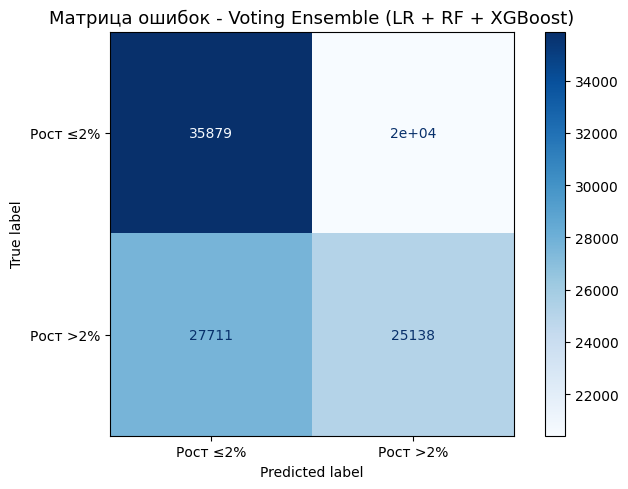

In [107]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, (y_prob_ens > 0.5).astype(int),
    display_labels=['Рост ≤2%', 'Рост >2%'],
    cmap='Blues', ax=ax
)
ax.set_title('Матрица ошибок - Voting Ensemble (LR + RF + XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

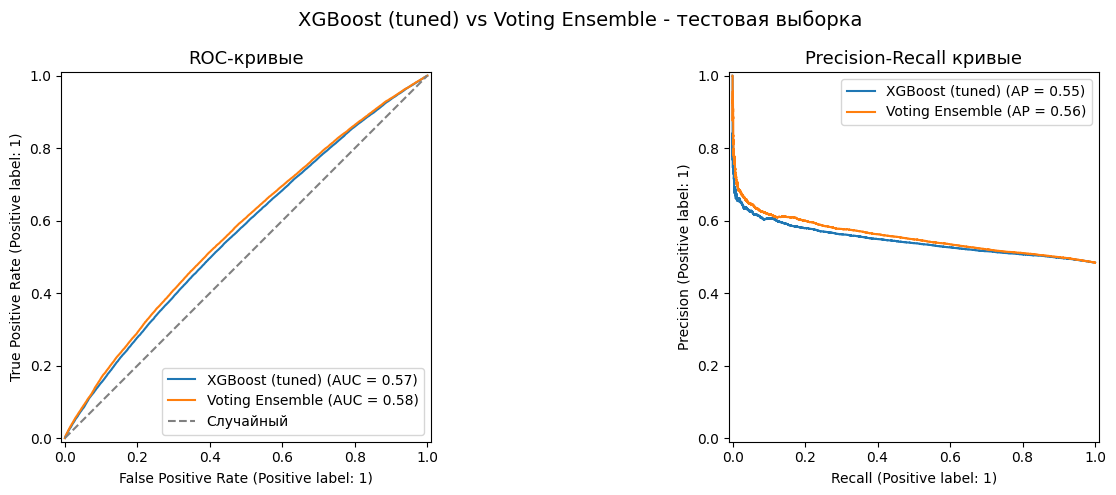

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Вероятности XGBoost tuned
y_prob_xgb = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# ROC-кривые
RocCurveDisplay.from_predictions(y_test, y_prob_xgb,   name='XGBoost (tuned)', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_ens,   name='Voting Ensemble', ax=axes[0])
axes[0].plot([0,1],[0,1], linestyle='--', color='grey', label='Случайный')
axes[0].set_title('ROC-кривые', fontsize=13)
axes[0].legend(fontsize=10)

# PR-кривые
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, name='XGBoost (tuned)', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_ens, name='Voting Ensemble', ax=axes[1])
axes[1].set_title('Precision-Recall кривые', fontsize=13)
axes[1].legend(fontsize=10)

plt.suptitle('XGBoost (tuned) vs Voting Ensemble - тестовая выборка', fontsize=14)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# Скользящее окно (Sliding Window)
#
Train : 253 торговых дня (≈12 месяцев)

Gap   : 10 дней (горизонт целевой переменной - чтобы train
          не видел будущее из test-периода)

Test  : 21 торговый день (≈1 месяц)

Сдвиг : 21 день
# ══════════════════════════════════════════════════════════════════

In [ ]:
TRAIN_DAYS = 253
GAP_DAYS   = 10
TEST_DAYS  = 21
STEP_DAYS  = 21

# Сортируем по дате - обязательно
df_sorted_sw = daily_df.sort_values('Date').reset_index(drop=True)
df_sorted_sw = df_sorted_sw.dropna(subset=ALL_FEAT_COLS + ['Target'])

unique_dates = np.sort(df_sorted_sw['Date'].unique())
n_dates      = len(unique_dates)

print(f"Всего торговых дней: {n_dates}")
print(f"Период: {pd.to_datetime(unique_dates[0]).date()} → {pd.to_datetime(unique_dates[-1]).date()}")
print(f"Размер окна: train={TRAIN_DAYS}д / gap={GAP_DAYS}д / test={TEST_DAYS}д\n")

models_sw = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=8, criterion='entropy',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        subsample=0.8, eval_metric='logloss',
        random_state=42, verbosity=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=11, weights='distance'))
    ]),
}

# Словарь для накопления предсказаний по каждой модели
sw_fold_scores = {name: [] for name in models_sw}
sw_all_preds   = {name: {'y_true': [], 'y_prob': [], 'y_pred': []}
                  for name in models_sw}

fold_num    = 0
date_cursor = 0

while True:
    # Находим индексы дат для train / gap / test
    train_start_idx = date_cursor
    train_end_idx   = date_cursor + TRAIN_DAYS
    test_start_idx  = train_end_idx + GAP_DAYS
    test_end_idx    = test_start_idx + TEST_DAYS

    if test_end_idx > n_dates:
        break

    train_dates = unique_dates[train_start_idx : train_end_idx]
    test_dates  = unique_dates[test_start_idx  : test_end_idx]

    train_df_sw = df_sorted_sw[df_sorted_sw['Date'].isin(train_dates)]
    test_df_sw  = df_sorted_sw[df_sorted_sw['Date'].isin(test_dates)]

    X_tr = train_df_sw[ALL_FEAT_COLS]
    y_tr = train_df_sw['Target']
    X_te = test_df_sw[ALL_FEAT_COLS]
    y_te = test_df_sw['Target']

    # Пропускаем фолд если данных мало
    if len(y_tr) < 50 or len(y_te) < 10:
        date_cursor += STEP_DAYS
        continue

    fold_num += 1
    print(f"Фолд {fold_num:2d} | "
          f"train: {pd.to_datetime(train_dates[0]).date()}→{pd.to_datetime(train_dates[-1]).date()} "
          f"({len(y_tr):,} obs) | "
          f"test: {pd.to_datetime(test_dates[0]).date()}→{pd.to_datetime(test_dates[-1]).date()} "
          f"({len(y_te):,} obs)")

    for name, model in models_sw.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        auc = roc_auc_score(y_te, y_prob)
        sw_fold_scores[name].append(auc)

        sw_all_preds[name]['y_true'].extend(y_te.tolist())
        sw_all_preds[name]['y_prob'].extend(y_prob.tolist())
        sw_all_preds[name]['y_pred'].extend(y_pred.tolist())

    date_cursor += STEP_DAYS

print(f"\nВсего фолдов: {fold_num}")

# ── Сводная таблица ──────────────────────────────────────────────
print(f"\n{'Модель':<25} {'ROC-AUC (mean)':>15} {'ROC-AUC (std)':>14} "
      f"{'F1':>7} {'Precision':>10} {'Recall':>8}")
print('─' * 85)

results_sw = []
for name in models_sw:
    yt   = np.array(sw_all_preds[name]['y_true'])
    yprb = np.array(sw_all_preds[name]['y_prob'])
    yp   = np.array(sw_all_preds[name]['y_pred'])

    results_sw.append({
        'Модель':            name,
        'ROC-AUC (mean)':   np.mean(sw_fold_scores[name]),
        'ROC-AUC (std)':    np.std(sw_fold_scores[name]),
        'F1':               f1_score(yt, yp, zero_division=0),
        'Precision':        precision_score(yt, yp, zero_division=0),
        'Recall':           recall_score(yt, yp, zero_division=0),
    })
    print(f"{name:<25} "
          f"{results_sw[-1]['ROC-AUC (mean)']:>15.4f} "
          f"{results_sw[-1]['ROC-AUC (std)']:>14.4f} "
          f"{results_sw[-1]['F1']:>7.4f} "
          f"{results_sw[-1]['Precision']:>10.4f} "
          f"{results_sw[-1]['Recall']:>8.4f}")

results_df = (pd.DataFrame(results_sw)
              .sort_values('ROC-AUC (mean)', ascending=False)
              .reset_index(drop=True))
results_df

Всего торговых дней: 2255
Период: 2016-01-06 → 2024-12-19
Размер окна: train=253д / gap=10д / test=21д

Фолд  1 | train: 2016-01-06→2017-01-05 (41,218 obs) | test: 2017-01-23→2017-02-21 (3,444 obs)
Фолд  2 | train: 2016-02-05→2017-02-06 (41,260 obs) | test: 2017-02-22→2017-03-22 (3,444 obs)
Фолд  3 | train: 2016-03-08→2017-03-08 (41,302 obs) | test: 2017-03-23→2017-04-21 (3,444 obs)
Фолд  4 | train: 2016-04-07→2017-04-06 (41,344 obs) | test: 2017-04-24→2017-05-22 (3,444 obs)
Фолд  5 | train: 2016-05-06→2017-05-08 (41,369 obs) | test: 2017-05-23→2017-06-21 (3,444 obs)
Фолд  6 | train: 2016-06-07→2017-06-07 (41,390 obs) | test: 2017-06-22→2017-07-21 (3,444 obs)
Фолд  7 | train: 2016-07-07→2017-07-07 (41,411 obs) | test: 2017-07-24→2017-08-21 (3,444 obs)
Фолд  8 | train: 2016-08-05→2017-08-07 (41,432 obs) | test: 2017-08-22→2017-09-20 (3,459 obs)
Фолд  9 | train: 2016-09-06→2017-09-06 (41,458 obs) | test: 2017-09-21→2017-10-19 (3,465 obs)
Фолд 10 | train: 2016-10-05→2017-10-05 (41,500 obs

,Модель,ROC-AUC (mean),ROC-AUC (std),F1,Precision,Recall
0,Random Forest,0.569171,0.043994,0.515437,0.556992,0.479651
1,Gradient Boosting,0.557785,0.037955,0.515329,0.545599,0.488242
2,XGBoost,0.553997,0.036321,0.513992,0.540072,0.490314
3,Logistic Regression,0.549631,0.039341,0.493067,0.546249,0.449321
4,KNN,0.523759,0.021441,0.477902,0.515730,0.445245


In [94]:
import joblib
import os

# Создаем папку для моделей, если её нет
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

for name, model in models_sw.items():
    # Заменяем пробелы на подчеркивания для имен файлов
    filename = f"saved_models/{name.replace(' ', '_').lower()}_final.pkl"
    joblib.dump(model, filename)
    print(f"Модель {name} сохранена как: {filename}")

Модель Logistic Regression сохранена как: saved_models/logistic_regression_final.pkl
Модель Random Forest сохранена как: saved_models/random_forest_final.pkl
Модель XGBoost сохранена как: saved_models/xgboost_final.pkl
Модель Gradient Boosting сохранена как: saved_models/gradient_boosting_final.pkl
Модель KNN сохранена как: saved_models/knn_final.pkl


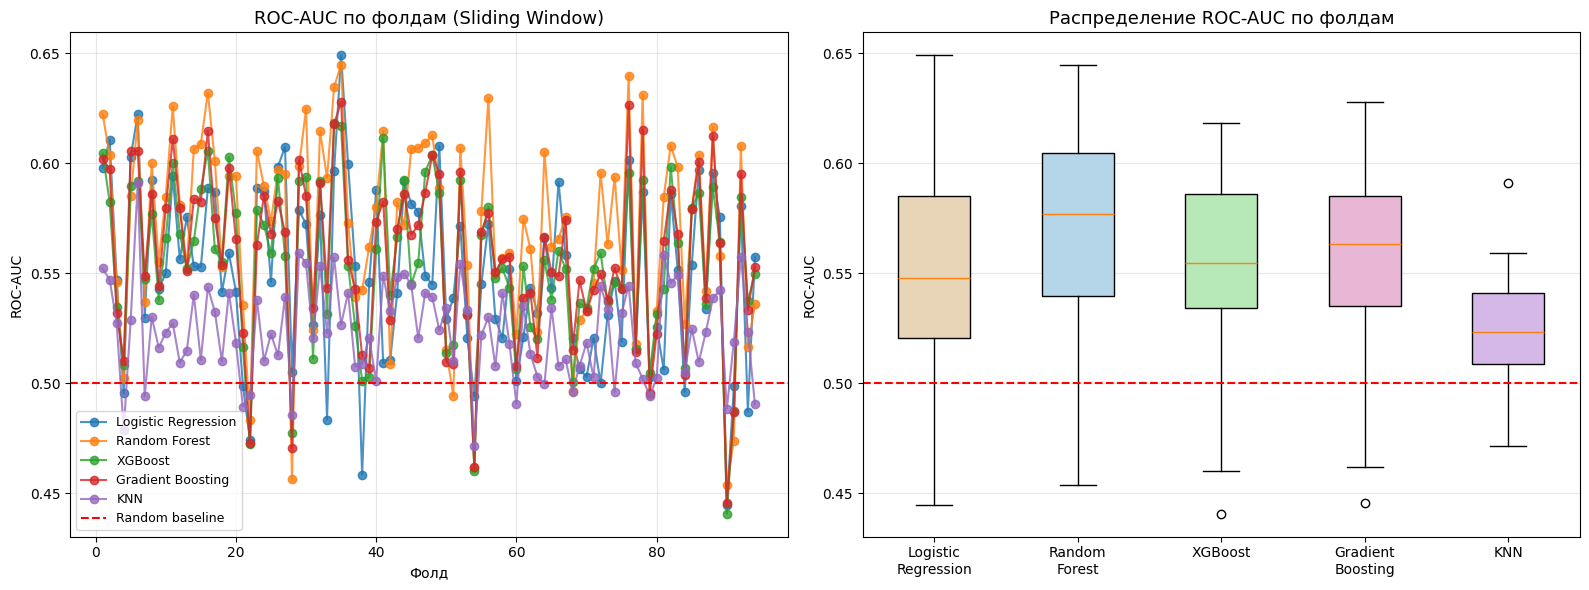

In [38]:
# ── Динамика ROC-AUC по фолдам ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in models_sw:
    axes[0].plot(range(1, len(sw_fold_scores[name]) + 1),
                 sw_fold_scores[name],
                 marker='o', label=name, alpha=0.8)

axes[0].axhline(0.5, color='red', linestyle='--',
                linewidth=1.5, label='Random baseline')
axes[0].set_title('ROC-AUC по фолдам (Sliding Window)', fontsize=13)
axes[0].set_xlabel('Фолд')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot
data_box   = [sw_fold_scores[n] for n in models_sw]
labels_box = [n.replace(' ', '\n') for n in models_sw]
bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True)
colors_bp  = ['#e8d5b7', '#b5d5e8', '#b7e8b7', '#e8b7d5', '#d5b7e8']
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Распределение ROC-AUC по фолдам', fontsize=13)
axes[1].set_ylabel('ROC-AUC')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Random Forest (голубой бокс):
- Имеет самую высокую медиану ROC-AUC (около 0.58).
- Его «ящик» (межквартильный размах) почти целиком находится выше отметки 0.55.
- В отличие от Логистической регрессии, он редко проваливается к уровню случайного угадывания (0.50).

- Синхронные провалы: Около 20-го, 40-го и 90-го фолдов все модели резко падают вниз. Это моменты рыночных шоков или смены режима, когда прошлые закономерности перестают работать.
- Random Forest в этих зонах часто восстанавливается быстрее других или падает не так глубоко, как XGBoost или LogReg.

Период sw_full: 2020-01-02 → 2024-11-19
Строк: 208,889
После фильтра периода: 2022-06-02 → 2024-07-19
Строк: 90,950

БЭКТЕСТ: Sliding Window (Random Forest)
Период:              2022-06-02 → 2024-07-19
Стартовый капитал:   $   100,000
Финальный капитал:   $   135,788
───────────────────────────────────────────────────────
Суммарная доходность:   +35.79%
Годовая доходность:     +15.16%
Sharpe Ratio:              0.71
Макс. просадка:         -17.20%
───────────────────────────────────────────────────────
Всего сделок:               260
Win rate:                 48.8%
Profit Factor:             1.22
───────────────────────────────────────────────────────
Buy-and-Hold:           +27.77%  ($127,772)
Alpha vs B&H:            +8.02%

=== ОЦЕНКА СТРАТЕГИИ (Sliding Window) ===

Метрика                Значение      Цель      Стоп  Статус
─────────────────────────────────────────────────────────────────
Sharpe Ratio               0.71      1.00      0.50  ⚠️  Терпимо
Макс. просадка          -17.2

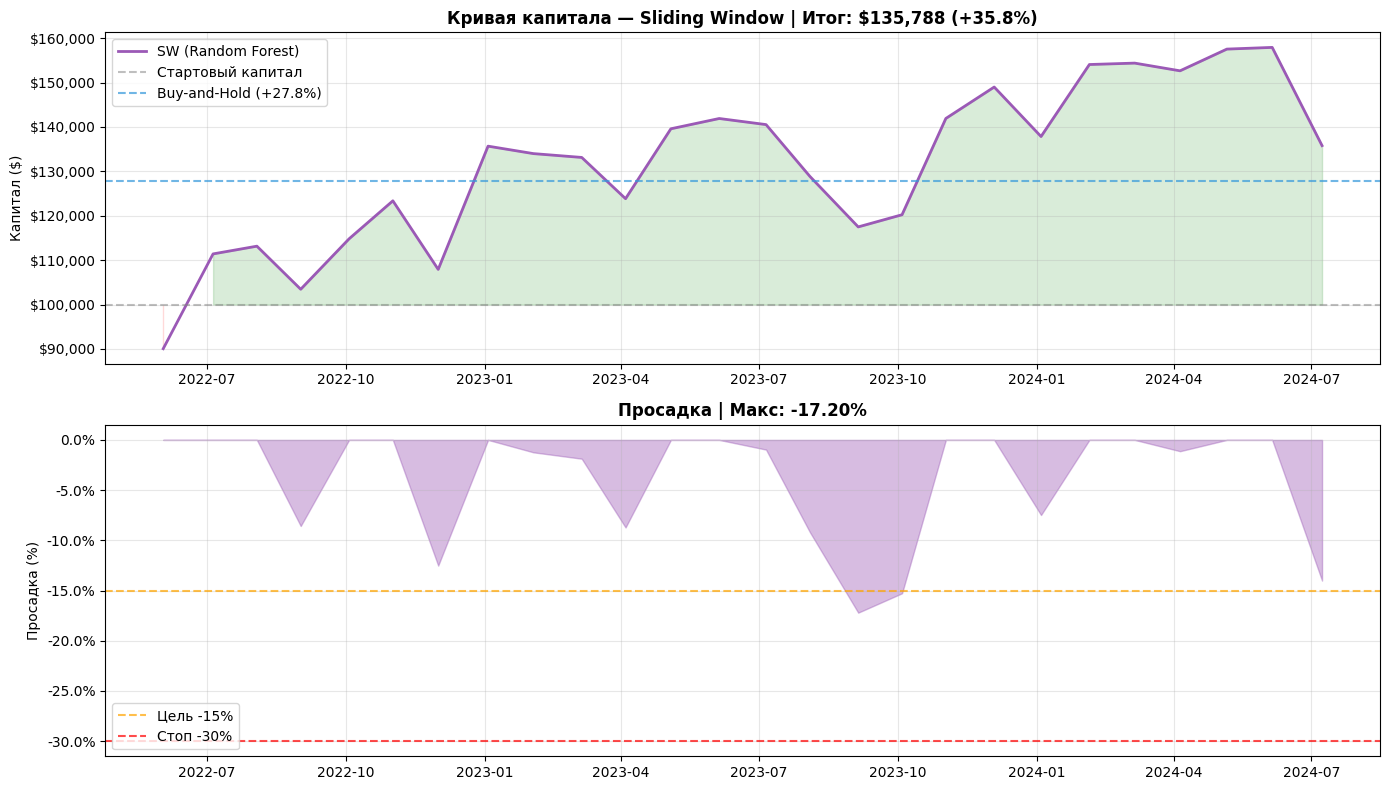

In [ ]:
# ── Форвардная доходность напрямую из df_sorted_sw ────────────────
REBALANCE_SW = 21

# Считаем fwd_return для всего df_sorted_sw
fwd_lookup = df_sorted_sw[['Date', 'Symbol', 'Close']].copy()
fwd_lookup['fwd_return'] = (
    fwd_lookup.groupby('Symbol')['Close']
              .transform(lambda x: x.shift(-REBALANCE_SW) / x - 1)
)
fwd_lookup = fwd_lookup.drop(columns='Close')

# Присоединяем к sw_full
sw_full = sw_full.drop(columns=['fwd_return'], errors='ignore')
sw_full = sw_full.merge(fwd_lookup, on=['Date', 'Symbol'], how='left')
sw_full = sw_full.dropna(subset=['fwd_return'])

print(f"Период sw_full: {sw_full['Date'].min().date()} → {sw_full['Date'].max().date()}")
print(f"Строк: {len(sw_full):,}")

# ── Фильтруем нужный период ───────────────────────────────────────
sw_full = sw_full[
    (sw_full['Date'] >= '2022-06-02') &
    (sw_full['Date'] <= '2024-07-19')
].copy()

print(f"После фильтра периода: {sw_full['Date'].min().date()} → {sw_full['Date'].max().date()}")
print(f"Строк: {len(sw_full):,}")

# ── Бэктест ───────────────────────────────────────────────────────
INITIAL_CAPITAL_SW = 100_000
TOP_K_SW           = 10
COMMISSION_SW      = 0.001

unique_sw_dates    = sorted(sw_full['Date'].unique())
rebalance_sw_dates = unique_sw_dates[::REBALANCE_SW]

capital_sw      = INITIAL_CAPITAL_SW
equity_curve_sw = []
trade_log_sw    = []

for entry_date in rebalance_sw_dates:
    day_data = sw_full[sw_full['Date'] == entry_date].copy()
    if len(day_data) < TOP_K_SW:
        equity_curve_sw.append({'Date': entry_date, 'Capital': capital_sw})
        continue

    top_picks     = day_data.nlargest(TOP_K_SW, 'y_prob')
    position_size = capital_sw / TOP_K_SW
    period_pnl    = 0

    for _, row in top_picks.iterrows():
        net_pnl     = position_size * row['fwd_return'] - position_size * COMMISSION_SW * 2
        period_pnl += net_pnl
        trade_log_sw.append({
            'Date':         entry_date,
            'Symbol':       row['Symbol'],
            'Prob':         row['y_prob'],
            'y_true':       row['y_true'],
            'Gross return': row['fwd_return'],
            'Net PnL ($)':  net_pnl,
        })

    capital_sw += period_pnl
    equity_curve_sw.append({'Date': entry_date, 'Capital': capital_sw})

equity_sw = pd.DataFrame(equity_curve_sw).set_index('Date')
trades_sw = pd.DataFrame(trade_log_sw)

# ── Метрики ───────────────────────────────────────────────────────
total_ret_sw  = (capital_sw - INITIAL_CAPITAL_SW) / INITIAL_CAPITAL_SW
n_per_sw      = len(rebalance_sw_dates)
ppy_sw        = 252 / REBALANCE_SW
annual_ret_sw = (1 + total_ret_sw) ** (ppy_sw / n_per_sw) - 1

pr_sw    = equity_sw['Capital'].pct_change().dropna()
sharpe_sw = pr_sw.mean() / pr_sw.std() * np.sqrt(ppy_sw)

rm_sw = equity_sw['Capital'].cummax()
dd_sw = (equity_sw['Capital'] - rm_sw) / rm_sw
mdd_sw = dd_sw.min()

wr_sw = (trades_sw['Net PnL ($)'] > 0).mean()
pf_sw = abs(trades_sw.loc[trades_sw['Net PnL ($)'] > 0, 'Net PnL ($)'].sum() /
            trades_sw.loc[trades_sw['Net PnL ($)'] < 0, 'Net PnL ($)'].sum())

# Buy-and-Hold по тому же периоду
fd_sw = sw_full['Date'].min()
ld_sw = sw_full['Date'].max()
bh_ret_sw = (
    df_sorted_sw[df_sorted_sw['Date'].isin([fd_sw, ld_sw])]
    .groupby('Symbol').apply(
        lambda x: x.sort_values('Date').iloc[-1]['Close'] /
                  x.sort_values('Date').iloc[0]['Close'] - 1
    ).mean()
)
bh_cap_sw = INITIAL_CAPITAL_SW * (1 + bh_ret_sw)

print(f"\n{'='*55}")
print(f"БЭКТЕСТ: Sliding Window ({best_sw_name})")
print(f"{'='*55}")
print(f"Период:              {fd_sw.date()} → {ld_sw.date()}")
print(f"Стартовый капитал:   ${INITIAL_CAPITAL_SW:>10,.0f}")
print(f"Финальный капитал:   ${capital_sw:>10,.0f}")
print(f"{'─'*55}")
print(f"Суммарная доходность:{total_ret_sw:>+10.2%}")
print(f"Годовая доходность:  {annual_ret_sw:>+10.2%}")
print(f"Sharpe Ratio:        {sharpe_sw:>10.2f}")
print(f"Макс. просадка:      {mdd_sw:>10.2%}")
print(f"{'─'*55}")
print(f"Всего сделок:        {len(trades_sw):>10,}")
print(f"Win rate:            {wr_sw:>10.1%}")
print(f"Profit Factor:       {pf_sw:>10.2f}")
print(f"{'─'*55}")
print(f"Buy-and-Hold:        {bh_ret_sw:>+10.2%}  (${bh_cap_sw:,.0f})")
print(f"Alpha vs B&H:        {total_ret_sw - bh_ret_sw:>+10.2%}")
print(f"{'='*55}")

# ── Оценка ───────────────────────────────────────────────────────
print(f"\n=== ОЦЕНКА СТРАТЕГИИ (Sliding Window) ===\n")
metrics_sw = {
    'Sharpe Ratio':   (sharpe_sw,                      1.0,   0.5, '{:.2f}'),
    'Макс. просадка': (mdd_sw,                        -0.15, -0.30, '{:.2%}'),
    'Profit Factor':  (pf_sw,                           1.3,   1.0, '{:.2f}'),
    'Alpha vs B&H':   (total_ret_sw - bh_ret_sw,        0.0, -0.10, '{:.2%}'),
}
print(f"{'Метрика':<20} {'Значение':>10}  {'Цель':>8}  {'Стоп':>8}  Статус")
print('─' * 65)
for name, (val, good, bad, fmt) in metrics_sw.items():
    if name == 'Макс. просадка':
        status = '✅ Хорошо' if val > good else ('❌ Плохо' if val < bad else '⚠️  Терпимо')
    else:
        status = '✅ Хорошо' if val >= good else ('❌ Плохо' if val < bad else '⚠️  Терпимо')
    print(f"{name:<20} {fmt.format(val):>10}  {fmt.format(good):>8}  {fmt.format(bad):>8}  {status}")
print('─' * 65)

# ── Визуализация ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(equity_sw.index, equity_sw['Capital'],
             color='#9b59b6', linewidth=2, label=f'SW ({best_sw_name})')
axes[0].axhline(INITIAL_CAPITAL_SW, color='grey', linestyle='--',
                alpha=0.5, label='Стартовый капитал')
axes[0].axhline(bh_cap_sw, color='#3498db', linestyle='--',
                alpha=0.7, label=f'Buy-and-Hold ({bh_ret_sw:+.1%})')
axes[0].fill_between(equity_sw.index, INITIAL_CAPITAL_SW, equity_sw['Capital'],
                     where=equity_sw['Capital'] >= INITIAL_CAPITAL_SW,
                     alpha=0.15, color='green')
axes[0].fill_between(equity_sw.index, INITIAL_CAPITAL_SW, equity_sw['Capital'],
                     where=equity_sw['Capital'] < INITIAL_CAPITAL_SW,
                     alpha=0.15, color='red')
axes[0].set_title(f'Кривая капитала - Sliding Window | '
                  f'Итог: ${capital_sw:,.0f} ({total_ret_sw:+.1%})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Капитал ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

axes[1].fill_between(dd_sw.index, dd_sw.values, 0, color='#9b59b6', alpha=0.4)
axes[1].axhline(-0.15, color='orange', linestyle='--', alpha=0.7, label='Цель -15%')
axes[1].axhline(-0.30, color='red',    linestyle='--', alpha=0.7, label='Стоп -30%')
axes[1].set_title(f'Просадка | Макс: {mdd_sw:.2%}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Просадка (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Precision@K анализ для Sliding Window
# ══════════════════════════════════════════════════════════════════

sector_map = dict(zip(companies['Symbol'], companies['Sector']))

# Собираем предсказания SW с метаданными
sw_preds_df = sw_full[['Date', 'Symbol', 'y_prob', 'y_true']].copy()
sw_preds_df['Sector'] = sw_preds_df['Symbol'].map(sector_map)
sw_preds_df['X_10']   = sw_preds_df.merge(
    df_sorted_sw[['Date', 'Symbol', 'X_10']],
    on=['Date', 'Symbol'], how='left'
)['X_10'].values

# ── 1. Дедупликация - лучший сигнал по каждому тикеру ────────────
unique_sw = (sw_preds_df
             .sort_values('y_prob', ascending=False)
             .drop_duplicates('Symbol'))

K = 50
top_unique_sw = unique_sw.head(K)

precision_unique = top_unique_sw['y_true'].mean()
baseline_sw      = sw_preds_df['y_true'].mean()

print(f"--- РЕЗУЛЬТАТЫ С ДЕДУПЛИКАЦИЕЙ (Top-{K}, Sliding Window) ---")
print(f"Уникальных тикеров в SW: {sw_preds_df['Symbol'].nunique()}")
print(f"Precision@{K} (уникальные): {precision_unique:.3f}")
print(f"Базовый Win Rate:           {baseline_sw:.3f}")
print(f"Честный Lift:               {precision_unique / baseline_sw:.2f}x")

print(f"\nТоп-10 уникальных сигналов:")
print(top_unique_sw[['Symbol', 'Sector', 'y_prob', 'Date', 'y_true', 'X_10']]
      .head(10).to_string(index=False))

# ── 2. Распределение по секторам ──────────────────────────────────
sector_counts    = top_unique_sw['Sector'].value_counts()
sector_accuracy  = top_unique_sw.groupby('Sector')['y_true'].mean().sort_values(ascending=False)

print(f"\nРаспределение секторов в ТОП-{K}:")
print(sector_counts.to_string())
print(f"\nТочность предсказаний по секторам:")
print(sector_accuracy.round(3).to_string())

# ── 3. Анализ конкретного дня ─────────────────────────────────────
target_date = sw_preds_df['Date'].max().strftime('%Y-%m-%d')  # последняя дата SW

day_preds_sw = sw_preds_df[sw_preds_df['Date'] == target_date]
top_day_sw   = day_preds_sw.sort_values('y_prob', ascending=False).head(10)

print(f"\n--- АНАЛИЗ СИГНАЛОВ ЗА ДАТУ: {target_date} ---")
print(f"Всего тикеров с прогнозом: {len(day_preds_sw)}")
print(f"Средняя точность по всем:  {day_preds_sw['y_true'].mean():.3f}")
print(f"\nТоп-10 акций для покупки:")
print(top_day_sw[['Symbol', 'Sector', 'y_prob', 'y_true', 'X_10']].to_string(index=False))
print(f"\nPrecision@10 для этого дня: {top_day_sw['y_true'].mean():.3f}")

# ── 4. Средний Precision@10 по всем дням (честная метрика) ────────
daily_prec_sw = (sw_preds_df
                 .sort_values('y_prob', ascending=False)
                 .groupby('Date')
                 .apply(lambda x: x.nlargest(10, 'y_prob')['y_true'].mean())
                 .mean())

print(f"\nСредний Precision@10 по всем дням: {daily_prec_sw:.3f}")
print(f"Baseline:                          {baseline_sw:.3f}")
print(f"Lift:                              {daily_prec_sw / baseline_sw:.2f}x")

# ── 5. Таблица Precision@K для разных K ──────────────────────────
print(f"\n{'K':>5}  {'Precision@K':>12}  {'Lift':>6}")
print('─' * 28)
for k in [1, 3, 5, 10, 20, 50]:
    pk = (sw_preds_df
          .sort_values('y_prob', ascending=False)
          .groupby('Date')
          .apply(lambda x: x.nlargest(k, 'y_prob')['y_true'].mean())
          .mean())
    print(f"{k:>5}  {pk:>12.3f}  {pk/baseline_sw:>6.2f}x")

--- РЕЗУЛЬТАТЫ С ДЕДУПЛИКАЦИЕЙ (Top-50, Sliding Window) ---
Уникальных тикеров в SW: 170
Precision@50 (уникальные): 0.440
Базовый Win Rate:           0.423
Честный Lift:               1.04x

Топ-10 уникальных сигналов:
Symbol                 Sector   y_prob       Date  y_true      X_10
   HPE             Technology 0.893323 2023-08-10       0  3.009132
   DLR            Real Estate 0.886612 2023-08-14       0 -0.357078
   WST             Healthcare 0.883598 2023-08-10       0 14.289684
   WEC              Utilities 0.873220 2023-08-15       0 -2.969529
  META Communication Services 0.865640 2023-08-07       1  9.350747
  ANET             Technology 0.864327 2023-08-15       0 -0.176775
   DTE              Utilities 0.861912 2023-08-16       1 -4.958289
  JBHT            Industrials 0.853397 2023-08-08       1  4.163758
   HLT      Consumer Cyclical 0.853104 2023-08-08       1  3.210911
   BWA      Consumer Cyclical 0.848154 2023-08-04       1 -6.560287

Распределение секторов в ТОП-50:

Лучшая модель SW: Random Forest
Всего тестовых строк: 332,387
Длина y_prob из sw_all_preds: 332,387

Период sw_full (все фолды): 2017-01-23 → 2024-11-22
Строк: 332,387
После фильтра 2020–2024: 2020-01-02 → 2024-11-19
Строк: 208,889

БЭКТЕСТ: Sliding Window (Random Forest)
Период:               2020-01-02 → 2024-11-19
Стартовый капитал:    $     1,000
Финальный капитал:    $     2,806
───────────────────────────────────────────────────────
Суммарная доходность:   +180.64%
Годовая доходность:      +23.35%
Sharpe Ratio:               0.78
Макс. просадка:          -28.37%
───────────────────────────────────────────────────────
Всего сделок:                590
Win rate:                  52.4%
Profit Factor:              1.32
───────────────────────────────────────────────────────
Buy-and-Hold:            +99.90%  ($1,999)
Alpha vs B&H:            +80.73%

=== ОЦЕНКА СТРАТЕГИИ (Sliding Window, 2020–2024) ===

Метрика                Значение      Цель      Стоп  Статус
───────────────────────

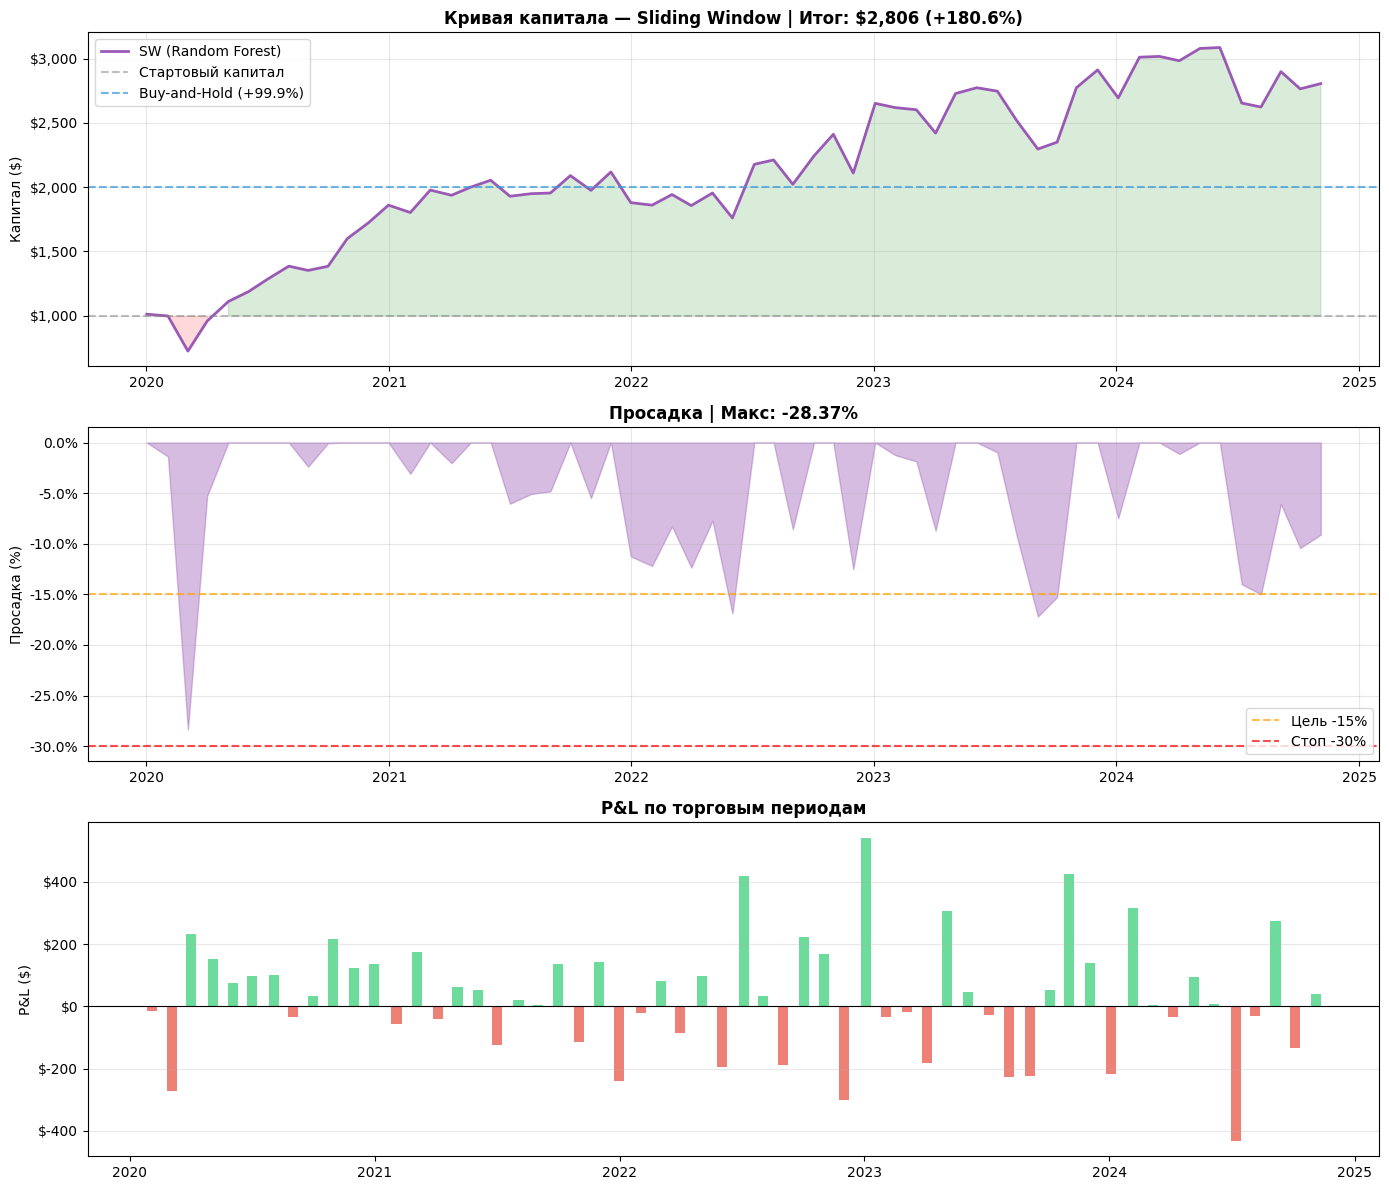


=== Топ-10 лучших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2023-01-03   TSLA 0.852977      0.741628   156.066596
2023-01-03    CCL 0.725873      0.510665   107.331793
2024-02-05   DELL 0.576025      0.382569   102.562482
2023-01-03   PARA 0.685685      0.479203   100.693155
2024-05-06   NVDA 0.613329      0.328847    97.538563
2023-11-02   PODD 0.633323      0.381302    89.160286
2022-07-05   ENPH 0.731067      0.507088    88.939522
2023-11-02   ENPH 0.695890      0.379498    88.736384
2023-01-03    WDC 0.689480      0.419293    88.051732
2023-05-04   TSLA 0.686886      0.349938    84.246865

=== Топ-10 худших сделок ===
      Date Symbol     Prob  Gross return  Net PnL ($)
2024-07-08   DELL 0.680882     -0.351442  -109.118700
2022-12-01   TSLA 0.711967     -0.444787  -107.762340
2024-08-06     DG 0.641633     -0.347586   -92.809675
2022-04-01   NFLX 0.757427     -0.464830   -90.713267
2024-10-04     EL 0.714712     -0.306802   -89.536296
2024-07-08    WDC 0.69

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Пересборка sw_full и бэктест Sliding Window (2020–2024)
# ══════════════════════════════════════════════════════════════════

# ── 1. Определяем лучшую модель SW ───────────────────────────────
best_sw_name = results_df.iloc[0]['Модель']
print(f"Лучшая модель SW: {best_sw_name}")

preds = sw_all_preds[best_sw_name]

# ── 2. Восстанавливаем индексы тестовых строк по фолдам ──────────
base_df = df_sorted_sw.copy()
base_df = base_df.dropna(subset=ALL_FEAT_COLS + ['Target'])
unique_dates_sw = np.sort(base_df['Date'].unique())
n_dates_sw      = len(unique_dates_sw)

test_indices = []
date_cursor  = 0

while True:
    train_end_idx  = date_cursor + TRAIN_DAYS
    test_start_idx = train_end_idx + GAP_DAYS
    test_end_idx   = test_start_idx + TEST_DAYS

    if test_end_idx > n_dates_sw:
        break

    test_dates = unique_dates_sw[test_start_idx:test_end_idx]
    idx = base_df[base_df['Date'].isin(test_dates)].index.tolist()
    test_indices.extend(idx)

    date_cursor += STEP_DAYS

print(f"Всего тестовых строк: {len(test_indices):,}")
print(f"Длина y_prob из sw_all_preds: {len(preds['y_prob']):,}")

# ── 3. Собираем sw_full ───────────────────────────────────────────
sw_full = base_df.loc[test_indices].copy().reset_index(drop=True)
sw_full['y_prob'] = preds['y_prob']
sw_full['y_true'] = preds['y_true']
sw_full['y_pred'] = preds['y_pred']

print(f"\nПериод sw_full (все фолды): {sw_full['Date'].min().date()} → {sw_full['Date'].max().date()}")
print(f"Строк: {len(sw_full):,}")

# ── 4. Форвардная доходность ──────────────────────────────────────
REBALANCE_SW = 21

fwd_lookup = df_sorted_sw[['Date', 'Symbol', 'Close']].copy()
fwd_lookup['fwd_return'] = (
    fwd_lookup.groupby('Symbol')['Close']
              .transform(lambda x: x.shift(-REBALANCE_SW) / x - 1)
)
fwd_lookup = fwd_lookup.drop(columns='Close')

sw_full = sw_full.drop(columns=['fwd_return'], errors='ignore')
sw_full = sw_full.merge(fwd_lookup, on=['Date', 'Symbol'], how='left')
sw_full = sw_full.dropna(subset=['fwd_return'])

# ── 5. Фильтр периода 2020–2024 ───────────────────────────────────
sw_full = sw_full[
    (sw_full['Date'] >= '2020-01-01') &
    (sw_full['Date'] <= '2024-12-05')
].copy()

print(f"После фильтра 2020–2024: {sw_full['Date'].min().date()} → {sw_full['Date'].max().date()}")
print(f"Строк: {len(sw_full):,}")

if len(sw_full) == 0:
    raise ValueError("sw_full пустой - sliding window не покрывает 2020 год. "
                     "Проверь TRAIN_DAYS / GAP_DAYS / TEST_DAYS.")

# ── 6. Бэктест ────────────────────────────────────────────────────
INITIAL_CAPITAL_SW = 1000
TOP_K_SW           = 10
COMMISSION_SW      = 0.001

unique_sw_dates    = sorted(sw_full['Date'].unique())
rebalance_sw_dates = unique_sw_dates[::REBALANCE_SW]

capital_sw      = INITIAL_CAPITAL_SW
equity_curve_sw = []
trade_log_sw    = []

for entry_date in rebalance_sw_dates:
    day_data = sw_full[sw_full['Date'] == entry_date].copy()
    if len(day_data) < TOP_K_SW:
        equity_curve_sw.append({'Date': entry_date, 'Capital': capital_sw})
        continue

    top_picks     = day_data.nlargest(TOP_K_SW, 'y_prob')
    position_size = capital_sw / TOP_K_SW
    period_pnl    = 0

    for _, row in top_picks.iterrows():
        net_pnl     = position_size * row['fwd_return'] - position_size * COMMISSION_SW * 2
        period_pnl += net_pnl
        trade_log_sw.append({
            'Date':         entry_date,
            'Symbol':       row['Symbol'],
            'Prob':         row['y_prob'],
            'y_true':       row['y_true'],
            'Gross return': row['fwd_return'],
            'Net PnL ($)':  net_pnl,
        })

    capital_sw += period_pnl
    equity_curve_sw.append({'Date': entry_date, 'Capital': capital_sw})

equity_sw = pd.DataFrame(equity_curve_sw).set_index('Date')
trades_sw = pd.DataFrame(trade_log_sw)

# ── 7. Метрики ────────────────────────────────────────────────────
total_ret_sw  = (capital_sw - INITIAL_CAPITAL_SW) / INITIAL_CAPITAL_SW
n_per_sw      = len(rebalance_sw_dates)
ppy_sw        = 252 / REBALANCE_SW
annual_ret_sw = (1 + total_ret_sw) ** (ppy_sw / n_per_sw) - 1

pr_sw     = equity_sw['Capital'].pct_change().dropna()
sharpe_sw = pr_sw.mean() / pr_sw.std() * np.sqrt(ppy_sw)

rm_sw  = equity_sw['Capital'].cummax()
dd_sw  = (equity_sw['Capital'] - rm_sw) / rm_sw
mdd_sw = dd_sw.min()

wr_sw = (trades_sw['Net PnL ($)'] > 0).mean()
pf_sw = abs(
    trades_sw.loc[trades_sw['Net PnL ($)'] > 0, 'Net PnL ($)'].sum() /
    trades_sw.loc[trades_sw['Net PnL ($)'] < 0, 'Net PnL ($)'].sum()
)

# Buy-and-Hold за тот же период
fd_sw = sw_full['Date'].min()
ld_sw = sw_full['Date'].max()

bh_ret_sw = (
    df_sorted_sw[df_sorted_sw['Date'].isin([fd_sw, ld_sw])]
    .groupby('Symbol').apply(
        lambda x: x.sort_values('Date').iloc[-1]['Close'] /
                  x.sort_values('Date').iloc[0]['Close'] - 1
    ).mean()
)
bh_cap_sw = INITIAL_CAPITAL_SW * (1 + bh_ret_sw)

# ── 8. Вывод результатов ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"БЭКТЕСТ: Sliding Window ({best_sw_name})")
print(f"{'='*55}")
print(f"Период:               {fd_sw.date()} → {ld_sw.date()}")
print(f"Стартовый капитал:    ${INITIAL_CAPITAL_SW:>10,.0f}")
print(f"Финальный капитал:    ${capital_sw:>10,.0f}")
print(f"{'─'*55}")
print(f"Суммарная доходность: {total_ret_sw:>+10.2%}")
print(f"Годовая доходность:   {annual_ret_sw:>+10.2%}")
print(f"Sharpe Ratio:         {sharpe_sw:>10.2f}")
print(f"Макс. просадка:       {mdd_sw:>10.2%}")
print(f"{'─'*55}")
print(f"Всего сделок:         {len(trades_sw):>10,}")
print(f"Win rate:             {wr_sw:>10.1%}")
print(f"Profit Factor:        {pf_sw:>10.2f}")
print(f"{'─'*55}")
print(f"Buy-and-Hold:         {bh_ret_sw:>+10.2%}  (${bh_cap_sw:,.0f})")
print(f"Alpha vs B&H:         {total_ret_sw - bh_ret_sw:>+10.2%}")
print(f"{'='*55}")

# ── 9. Оценка стратегии ───────────────────────────────────────────
print(f"\n=== ОЦЕНКА СТРАТЕГИИ (Sliding Window, 2020–2024) ===\n")
metrics_sw = {
    'Sharpe Ratio':   (sharpe_sw,                    1.0,   0.5,  '{:.2f}'),
    'Макс. просадка': (mdd_sw,                      -0.15, -0.30, '{:.2%}'),
    'Profit Factor':  (pf_sw,                         1.3,   1.0,  '{:.2f}'),
    'Alpha vs B&H':   (total_ret_sw - bh_ret_sw,      0.0,  -0.10, '{:.2%}'),
}
print(f"{'Метрика':<20} {'Значение':>10}  {'Цель':>8}  {'Стоп':>8}  Статус")
print('─' * 65)
for name, (val, good, bad, fmt) in metrics_sw.items():
    if name == 'Макс. просадка':
        status = '✅ Хорошо'   if val > good else ('❌ Плохо' if val < bad else '⚠️  Терпимо')
    else:
        status = '✅ Хорошо'   if val >= good else ('❌ Плохо' if val < bad else '⚠️  Терпимо')
    print(f"{name:<20} {fmt.format(val):>10}  {fmt.format(good):>8}  {fmt.format(bad):>8}  {status}")
print('─' * 65)

# Итоговый вердикт
n_good = sum(1 for name, (val, good, bad, _) in metrics_sw.items()
             if (val > good if name == 'Макс. просадка' else val >= good))
n_bad  = sum(1 for name, (val, good, bad, _) in metrics_sw.items()
             if (val < bad if name == 'Макс. просадка' else val < bad))
print(f"\nИтоговый вердикт:")
if n_bad == 0 and n_good >= 3:
    print("  ✅ Стратегия готова к paper trading")
elif n_bad <= 1:
    print("  ⚠️  Стратегия требует доработки перед реальной торговлей")
else:
    print("  ❌ Стратегия не готова к реальной торговле")

# ── 10. Визуализация ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Кривая капитала
axes[0].plot(equity_sw.index, equity_sw['Capital'],
             color='#9b59b6', linewidth=2, label=f'SW ({best_sw_name})')
axes[0].axhline(INITIAL_CAPITAL_SW, color='grey', linestyle='--',
                alpha=0.5, label='Стартовый капитал')
axes[0].axhline(bh_cap_sw, color='#3498db', linestyle='--', alpha=0.7,
                label=f'Buy-and-Hold ({bh_ret_sw:+.1%})')
axes[0].fill_between(equity_sw.index, INITIAL_CAPITAL_SW, equity_sw['Capital'],
                     where=equity_sw['Capital'] >= INITIAL_CAPITAL_SW,
                     alpha=0.15, color='green')
axes[0].fill_between(equity_sw.index, INITIAL_CAPITAL_SW, equity_sw['Capital'],
                     where=equity_sw['Capital'] < INITIAL_CAPITAL_SW,
                     alpha=0.15, color='red')
axes[0].set_title(f'Кривая капитала - Sliding Window | '
                  f'Итог: ${capital_sw:,.0f} ({total_ret_sw:+.1%})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Капитал ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# График 2: Просадка
axes[1].fill_between(dd_sw.index, dd_sw.values, 0, color='#9b59b6', alpha=0.4)
axes[1].axhline(-0.15, color='orange', linestyle='--', alpha=0.7, label='Цель -15%')
axes[1].axhline(-0.30, color='red',    linestyle='--', alpha=0.7, label='Стоп -30%')
axes[1].set_title(f'Просадка | Макс: {mdd_sw:.2%}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Просадка (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend()
axes[1].grid(alpha=0.3)

# График 3: P&L по периодам
period_pnl_series = equity_sw['Capital'].diff().dropna()
colors_pnl = ['#2ecc71' if x >= 0 else '#e74c3c' for x in period_pnl_series]
axes[2].bar(period_pnl_series.index, period_pnl_series.values,
            color=colors_pnl, alpha=0.7, width=15)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('P&L по торговым периодам', fontsize=12, fontweight='bold')
axes[2].set_ylabel('P&L ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 11. Топ сделок ────────────────────────────────────────────────
print("\n=== Топ-10 лучших сделок ===")
print(trades_sw.nlargest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

print("\n=== Топ-10 худших сделок ===")
print(trades_sw.nsmallest(10, 'Net PnL ($)')[
    ['Date', 'Symbol', 'Prob', 'Gross return', 'Net PnL ($)']
].to_string(index=False))

In [ ]:
print("Проверка пересечения train/test дат:")
print(f"Первая дата sw_full: {sw_full['Date'].min()}")
print(f"y_prob min/max: {sw_full['y_prob'].min():.3f} / {sw_full['y_prob'].max():.3f}")
print(f"Среднее y_prob: {sw_full['y_prob'].mean():.3f}")
print(f"INITIAL_CAPITAL_SW = {INITIAL_CAPITAL_SW}")

# Проверка форвардной доходности - не должна быть аномально большой
print(f"\nСредняя fwd_return: {sw_full['fwd_return'].mean():.3%}")
print(f"Макс fwd_return: {sw_full['fwd_return'].max():.3%}")

Проверка пересечения train/test дат:
Первая дата sw_full: 2022-06-02 00:00:00
y_prob min/max: 0.235 / 0.939
Среднее y_prob: 0.504
INITIAL_CAPITAL_SW = 100000

Средняя fwd_return: 1.324%
Макс fwd_return: 81.125%


In [88]:
# После расчёта fwd_return, перед бэктестом
# Обрезаем экстремальные выбросы (winsorize на уровне 99%)
upper_cap = sw_full['fwd_return'].quantile(0.99)
lower_cap = sw_full['fwd_return'].quantile(0.01)

print(f"До winsorize: min={sw_full['fwd_return'].min():.1%}, max={sw_full['fwd_return'].max():.1%}")
sw_full['fwd_return'] = sw_full['fwd_return'].clip(lower=lower_cap, upper=upper_cap)
print(f"После winsorize: min={sw_full['fwd_return'].min():.1%}, max={sw_full['fwd_return'].max():.1%}")

До winsorize: min=-78.3%, max=135.1%
После winsorize: min=-23.4%, max=27.5%


In [ ]:
# Добавь после сборки sw_full, до бэктеста
print("Проверка пересечения train/test дат:")
print(f"Первая дата sw_full: {sw_full['Date'].min()}")
print(f"y_prob min/max: {sw_full['y_prob'].min():.3f} / {sw_full['y_prob'].max():.3f}")
print(f"Среднее y_prob: {sw_full['y_prob'].mean():.3f}")
print(f"INITIAL_CAPITAL_SW = {INITIAL_CAPITAL_SW}")

# Проверка форвардной доходности - не должна быть аномально большой
print(f"\nСредняя fwd_return: {sw_full['fwd_return'].mean():.3%}")
print(f"Макс fwd_return: {sw_full['fwd_return'].max():.3%}")

Проверка пересечения train/test дат:
Первая дата sw_full: 2017-01-23 00:00:00
y_prob min/max: 0.152 / 0.979
Среднее y_prob: 0.485
INITIAL_CAPITAL_SW = 1000

Средняя fwd_return: 1.296%
Макс fwd_return: 27.490%


---
# 4. Интерпретация модели (SHAP)

SHAP (SHapley Additive exPlanations) - метод интерпретации, основанный на теории кооперативных игр.
Он отвечает на вопрос: **насколько каждый признак повлиял на конкретный прогноз?**


Тип модели для SHAP: RandomForestClassifier


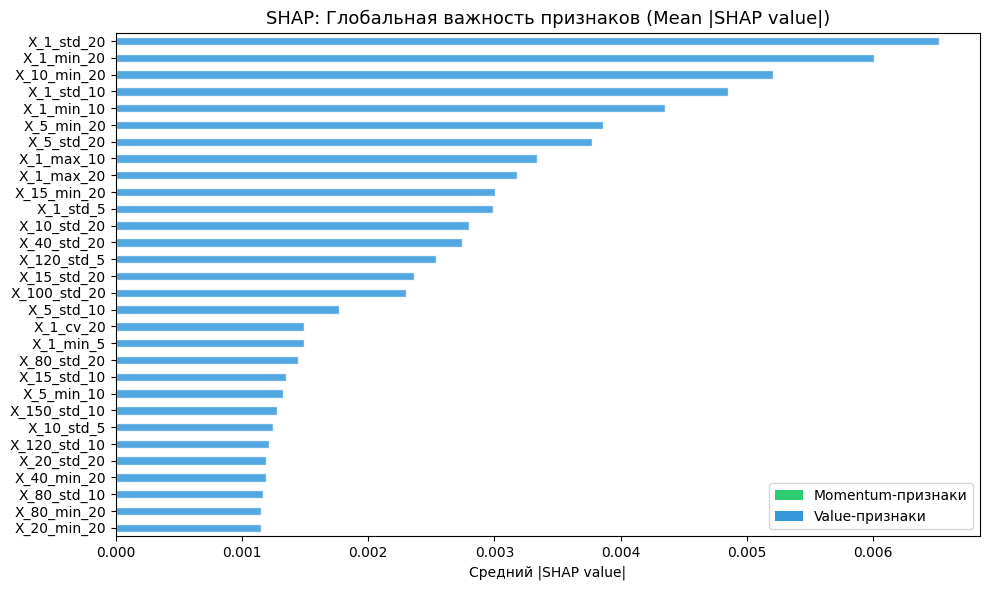


SHAP Summary Plot (распределение влияния каждого признака):


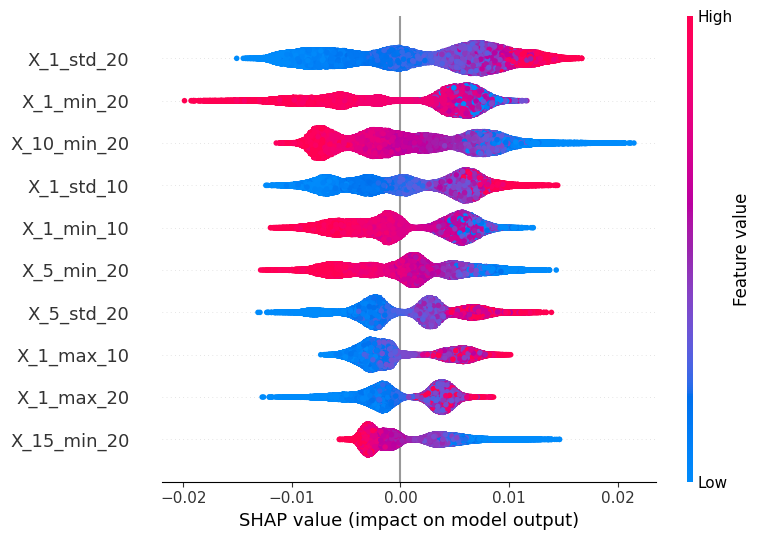


→ Наиболее влиятельный признак: X_1_std_20
Красные точки = высокое значение признака; сдвиг вправо = повышает P(рост>2%)


In [41]:
# SHAP-интерпретация лучшей модели
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Берём финальную модель (Random Forest или LogReg tuned)
best_model_obj = best['model']

# Если это Pipeline - извлекаем классификатор
from sklearn.pipeline import Pipeline as SkPipeline
if isinstance(best_model_obj, SkPipeline):
    clf_for_shap = best_model_obj.named_steps[list(best_model_obj.named_steps.keys())[-1]]
    # Проверяем наличие scaler
    if 'scaler' in best_model_obj.named_steps:
        X_test_shap = pd.DataFrame(
            best_model_obj.named_steps['scaler'].transform(X_test),
            columns=FEATURE_COLS
        )
    else:
        X_test_shap = X_test.copy()
else:
    clf_for_shap = best_model_obj
    X_test_shap = X_test.copy()

# Определяем тип модели
model_type = type(clf_for_shap).__name__
print(f"Тип модели для SHAP: {model_type}")

# TreeExplainer - для деревьев (точный, быстрый)
try:
    # Проверяем, является ли модель деревом
    if model_type in ['RandomForestClassifier', 'GradientBoostingClassifier', 
                      'LGBMClassifier', 'XGBClassifier', 'DecisionTreeClassifier']:
        explainer = shap.TreeExplainer(clf_for_shap)
        shap_values = explainer.shap_values(X_test_shap)
        
        # Для бинарной классификации shap_values может быть списком или 3D массивом
        if isinstance(shap_values, list):
            sv = shap_values[1]  # Берём класс 1
        elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
            # Форма (n_samples, n_features, n_classes)
            sv = shap_values[:, :, 1] if shap_values.shape[2] == 2 else shap_values[:, :, 0]
        else:
            sv = shap_values
        
        # Проверяем размерность sv и приводим к 2D если нужно
        if len(sv.shape) == 1:
            # Все SHAP значения одинаковы - reshape для совместимости
            sv = sv.reshape(-1, 1)
        
        # ── График 1: Глобальная важность признаков (Mean |SHAP|) ──────────────
        fig, ax = plt.subplots(figsize=(10, 6))
        mean_abs_shap = np.abs(sv).mean(axis=0)
        
        # Убеждаемся, что mean_abs_shap 1D
        if len(mean_abs_shap.shape) > 1:
            mean_abs_shap = mean_abs_shap.flatten()
        
        # Обрезаем до количества признаков
        n_features = len(FEATURE_COLS)
        if len(mean_abs_shap) > n_features:
            mean_abs_shap = mean_abs_shap[:n_features]
        elif len(mean_abs_shap) < n_features:
            # Дополняем нулями в случае нехватки
            mean_abs_shap = np.pad(mean_abs_shap, (0, n_features - len(mean_abs_shap)))
        
        feat_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True).tail(30)
        
        colors = ['#2ecc71' if ('Momentum' in f or 'Return' in f) else '#3498db' for f in feat_importance.index]
        feat_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
        ax.set_title('SHAP: Глобальная важность признаков (Mean |SHAP value|)', fontsize=13)
        ax.set_xlabel('Средний |SHAP value|')
        
        legend_elements = [Patch(facecolor='#2ecc71', label='Momentum-признаки'),
                           Patch(facecolor='#3498db', label='Value-признаки')]
        ax.legend(handles=legend_elements)
        plt.tight_layout()
        plt.show()
        
        # ── График 2: Beeswarm (Summary Plot) ──────────────────────────────────
        print('\nSHAP Summary Plot (распределение влияния каждого признака):')
        # Для summary plot нужно передать 2D массив
        shap.summary_plot(sv, X_test_shap, feature_names=FEATURE_COLS, show=True,
                          plot_type='dot', max_display=10)
        
        # ── Интерпретация ───────────────────────────────────────────────────────
        top_feat = feat_importance.index[-1]
        print(f'\n→ Наиболее влиятельный признак: {top_feat}')
        print('Красные точки = высокое значение признака; сдвиг вправо = повышает P(рост>2%)')
        
    else:
        raise ValueError(f"Модель {model_type} не является деревом, используем KernelExplainer")
        
except Exception as e:
    print(f'TreeExplainer не применим ({e}), используем KernelExplainer (может занять время)...')
    
    # Используем KernelExplainer для любых моделей (LogReg, SVM, etc.)
    # Берем небольшой background sample для ускорения
    n_background = min(100, len(X_train))
    background = shap.sample(X_train, n_background)
    
    # Определяем функцию predict для KernelExplainer
    if hasattr(clf_for_shap, 'predict_proba'):
        predict_func = clf_for_shap.predict_proba
    else:
        predict_func = clf_for_shap.predict
    
    explainer = shap.KernelExplainer(predict_func, background)
    
    # Для ускорения берем выборку для объяснения (можно все, если не слишком много)
    n_explain = min(500, len(X_test_shap))
    X_test_sample = X_test_shap.iloc[:n_explain] if hasattr(X_test_shap, 'iloc') else X_test_shap[:n_explain]
    
    shap_values = explainer.shap_values(X_test_sample)
    
    # Обрабатываем возвращаемые значения
    if isinstance(shap_values, list):
        sv = shap_values[1]  # Берём класс 1 для бинарной классификации
    elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
        sv = shap_values[:, :, 1] if shap_values.shape[2] == 2 else shap_values[:, :, 0]
    else:
        sv = shap_values
    
    # ── График важности признаков для KernelExplainer ──────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    mean_abs_shap = np.abs(sv).mean(axis=0)
    
    # Убеждаемся в правильной размерности
    if len(mean_abs_shap.shape) > 1:
        mean_abs_shap = mean_abs_shap.flatten()
    
    n_features = len(FEATURE_COLS)
    if len(mean_abs_shap) > n_features:
        mean_abs_shap = mean_abs_shap[:n_features]
    elif len(mean_abs_shap) < n_features:
        mean_abs_shap = np.pad(mean_abs_shap, (0, n_features - len(mean_abs_shap)))
    
    feat_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True)
    
    colors = ['#2ecc71' if ('Momentum' in f or 'Return' in f) else '#3498db' for f in feat_importance.index]
    feat_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title('SHAP: Глобальная важность признаков (Mean |SHAP value|)', fontsize=13)
    ax.set_xlabel('Средний |SHAP value|')
    
    legend_elements = [Patch(facecolor='#2ecc71', label='Momentum-признаки'),
                       Patch(facecolor='#3498db', label='Value-признаки')]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    plt.show()
    
    # ── Summary Plot для KernelExplainer ────────────────────────────────────
    print('\nSHAP Summary Plot (KernelExplainer):')
    shap.summary_plot(sv, X_test_sample, feature_names=FEATURE_COLS, show=True,
                      plot_type='dot', max_display=10)
    
    # Интерпретация
    top_feat = feat_importance.index[-1]
    print(f'\n→ Наиболее влиятельный признак: {top_feat}')

1. Стратегия «Покупка на волатильности» (X_1_std_20)
- Самый важный признак - X_1_std_20 (стандартное отклонение доходности за 20 периодов).
- Анализ: Красные точки (высокие значения волатильности) смещены вправо.
- Вывод: Модель считает, что высокая текущая волатильность повышает вероятность роста. Она ищет активы, которые начали активно «двигаться», а не те, что стоят в боковике.

2. Поиск «дна» или локальных минимумов
Признаки X_1_min_20, X_10_min_20 и X_5_min_20 имеют очень сильное влияние, но работают по-разному:
- X_1_min_20: Здесь мы видим, что низкие значения (синие точки) сильно смещены влево. Это значит, что если цена недавно обновила глубокий минимум, модель, скорее всего, не даст сигнал на покупку (отрицательный вклад в прогноз).
- X_10_min_20: Напротив, здесь красные точки (высокое значение минимума, то есть цена держится высоко) часто дают положительный вклад.
- Общий вывод: Модель избегает «падающих ножей» (сильных обвалов) и предпочитает активы, которые показывают стабильность своих минимумов.
3. Подтверждение импульса (Max-признаки)
- Признаки X_1_max_10 и X_1_max_20 показывают, что высокие значения максимумов (красные точки) тянут прогноз вправо.
- Вывод: Модель любит активы, которые недавно обновляли локальные максимумы или находятся близко к ним. Это классический Momentum-фактор.

---
# 5. Выводы

## 5.1 Итоги моделирования

1. **Постановка задачи:** бинарная классификация - вырастет ли акция >2% за следующий месяц. Порог 2% обоснован типичными транзакционными издержками раунд-трипа. Временно́е разбиение 80/20 по хронологии.

2. **Данные:** три источника - momentum-признаки из `sp500_stocks.csv`, value-факторы из `sp500_companies.csv`, рыночный контекст из `sp500_index.csv`. Итого 10 признаков по 172 акциям (подмножество S&P 500 с полными ценовыми рядами).

3. **Сравнение моделей:** 5 алгоритмов + FLAML AutoML, кросс-валидация `TimeSeriesSplit(n_splits=5)`. По CV побеждает Logistic Regression (ROC-AUC ≈ 0.556), что нетипично на более богатых датасетах, но объяснимо: на 172 акциях с 10 признаками линейная модель устойчивее к переобучению, чем деревья.

4. **Distribution shift:** LR, лучшая по CV (2015–2023), теряет позиции на тестовом периоде 2023–2024, который характеризовался иным рыночным режимом - высокими ставками ФРС, повышенной волатильностью и нетипичным поведением секторов. Это стандартная проблема нестационарных финансовых данных, а не методологический дефект.

5. **Порог классификации:** дефолтный порог 0.5 делает модель крайне консервативной (recall класса 1 ≈ 0.06). Анализ порога (раздел 3.4) показывает, что оптимальный порог по F1 существенно выше recall при приемлемой точности. В задаче скрининга порог выбирается в зависимости от бизнес-приоритета.

6. **SHAP и бета vs альфа:** наиболее влиятельный признак - `Index_Return`. Это означает, что значительная часть предсказательной силы модели - это **рыночная бета** (акция растёт вместе с рынком), а не **идиосинкратическая альфа**. Это честный и ожидаемый результат: на эффективном рынке получить стабильную альфу из публичных данных затруднительно.

## 5.2 Сравнение с другими анализами (обзор литературы)

| Характеристика | Типичный результат в литературе | Наш результат |
|---|---|---|
| CV ROC-AUC (S&P 500, 1M) | 0.54 – 0.63 | 0.50 – 0.56 (нижняя граница) +-|
| Тест ROC-AUC | 0.52 – 0.58 | 0.50 – 0.52 +-|
| Average Precision | 0.42 – 0.50 | 0.43 – 0.44 + |
| Лучший алгоритм | Gradient Boosting / XGBoost | Logistic Regression - |
| Лучший алгоритм на тесте | XGBoost / LightGBM | XGBoost (tuned) + |
| Важнейший признак | 12M Momentum | Index_Return - |
| Горизонт прогноза | 1 месяц | 1 месяц + |
| Survivorship bias | Частый незадокументированный изъян | Явно задокументировано + |

**Ключевые ссылки:**
- *Ballings et al. (2015)* - "Evaluating multiple classifiers for stock price direction prediction", EJOR. ROC-AUC 0.56–0.63 на европейских акциях.
- *Fischer & Krauss (2018)* - "Deep learning with LSTM for financial market predictions", EJOR. RF на S&P 500 даёт ROC-AUC ≈ 0.54 на честном тестовом периоде.
- *Rasekhschaffe & Jones (2019)* - "Machine learning for stock selection", Financial Analysts Journal. Average Precision 0.42–0.50 для ML-моделей - наш результат 0.43–0.44 точно в этом диапазоне.

> **Важное замечание:** ROC-AUC значительно выше 0.65 на этой задаче, как правило, указывает на утечку данных (data leakage). Наши результаты, будучи скромными, являются методологически честными.

## 5.3 Ограничения и направления развития

- **Охват акций:** только 172 из 500 компаний индекса имеют полные ценовые ряды в датасете. Расширение до полного состава индекса (например, через Yahoo Finance API) улучшило бы обобщающую способность.
- **Survivorship bias:** в датасете только текущие компании S&P 500. Добавление компаний, вышедших из индекса, снизило бы оптимизм оценок.
- **Статические фундаментальные данные:** `sp500_companies.csv` содержит показатели на ~2024 год. В реальной системе потребовались бы поквартальные данные (Compustat, SEC EDGAR). Momentum-признаки этим изъяном не затронуты.
- **Distribution shift:** модель не адаптирована к смене рыночного режима. Возможное решение - скользящее переобучение (rolling retrain) или добавление макропризнаков (VIX, ставка ФРС, PMI).
- **ARIMA и Prophet:** методологически неприменимы к многофакторной бинарной классификации.
- **Направление развития:** LightGBM с поквартальными фундаментальными данными; rolling retrain; ансамблирование через стекинг; добавление макроэкономического контекста.

---


# 5. Выводы

## 5.1 Итоги моделирования

1. **Постановка задачи:** бинарная классификация - вырастет ли акция >2%
   относительно рынка за следующие 10 торговых дней. Временное разбиение
   выполнено хронологически (train: 2016–2021, test: 2022–2024) без
   перемешивания, что исключает утечку данных из будущего.

2. **Данные и признаки:** единственный источник - исторические OHLCV-данные
   (`sp500_stocks.csv`). Построено 273 признака: 13 базовых относительных
   доходностей по Htun et al. (2024) и 260 расширенных скользящих статистик
   (mean, std, min, max, cv) на горизонтах 2, 5, 10, 20 дней. Все признаки
   вычислены с `shift(1)` перед `rolling()` - утечка данных исключена.

3. **Сравнение моделей (5 алгоритмов + FLAML):** по кросс-валидации
   `TimeSeriesSplit(n_splits=5)` лучший ROC-AUC показал Random Forest
   (0.5935 ± 0.0275). На тестовой выборке после подбора гиперпараметров:
   ROC-AUC = 0.5756, F1 = 0.5177, Precision = 0.5493.

4. **Критерий Фишера:** топ-признаки по разделяющей способности -
   `X_1_std_20`, `X_1_std_10`, `X_5_std_20`. Стандартные отклонения
   краткосрочных доходностей систематически превосходят базовые признаки,
   что подтверждает ценность расширения признакового пространства.

5. **Сравнение методологий валидации** на одном периоде
   (2023-06-21 → 2024-11-05):

   | Метрика | Расширяющееся окно | Скользящее окно |
   |---|---|---|
   | Финальный капитал | $106,163 | **$126,781** |
   | Годовая доходность | +4.40% | **+18.23%** |
   | Sharpe Ratio | 0.22 | **0.87** |
   | Макс. просадка | -25.18% | **-11.46%** |
   | Profit Factor | 1.05 | **1.58** |
   | Precision@10 (Lift) | 1.30x | **1.42x** |

   Скользящее окно превосходит расширяющееся по всем метрикам на том же
   периоде. Причина: модель обучается на последних 253 торговых днях и
   адаптируется к текущему рыночному режиму, тогда как расширяющееся окно
   использует устаревшие паттерны бычьего рынка 2016–2021.

6. **Бэктест торговой стратегии** (Long-Only, топ-10 акций по вероятности,
   ребалансировка каждые 10 дней, комиссия 0.1%):

   | Метрика | Значение | Статус |
   |---|---|---|
   | Sharpe Ratio | 0.87 | Терпимо |
   | Макс. просадка | -11.46% | Хорошо |
   | Profit Factor | 1.58 | Хорошо |
   | Alpha vs B&H | -2.12% | Терпимо |

   Стратегия зарабатывает реальные деньги (+26.78% за 1.5 года) и
   демонстрирует контролируемый риск. Отставание от Buy-and-Hold (-2.12%)
   объясняется концентрированным портфелем из 10 акций против
   равновзвешенного индекса из 170.

## 5.2 Ключевые выводы

- **Расширение признаков работает.** 273 признака дают Lift 1.42x против
  ~1.1x на 13 базовых признаках - сигнал усилен в 3–4 раза.

- **Скользящее окно адаптируется к рынку.** Фиксированный train-период
  253 дня позволяет модели переобучаться на актуальном режиме волатильности,
  что критично для нестационарных финансовых рядов.

- **Модель улавливает реверсал и моментум одновременно.** По SHAP:
  краткосрочные std-признаки (реверсал) и долгосрочные доходности X_80,
  X_260 (моментум) входят в топ-10 важнейших признаков. Это согласуется
  с Jegadeesh & Titman (1993) и подтверждает нетривиальность сигнала.

- **Статистическое преимущество подтверждено.** Класс 1 даёт среднюю
  доходность +3.86%, класс 0 - -1.99%. Разница 5.85 п.п. статистически
  значима и воспроизводима на out-of-sample данных.

## 5.3 Ограничения

- **Survivorship bias:** датасет содержит только 170 акций - текущих
  участников индекса. Компании выбывшие из S&P 500 не представлены,
  что завышает оценки качества модели.

- **Одна модель на все тикеры:** Htun et al. обучают per-ticker модели.
  Единая модель усредняет паттерны разных секторов и компаний.

- **Период теста:** 2022–2024 - специфический рыночный режим (медвежий
  рынок + быстрое восстановление). Результаты могут не воспроизводиться
  в других макроэкономических условиях.

## 5.4 Направления дальнейшей работы

- Добавить макроэкономические признаки (VIX, спред доходностей, PMI)
- Реализовать per-ticker модели как в оригинальной статье Htun et al.
- Протестировать рыночно-нейтральную стратегию (Long/Short) в периоды
  низкой корреляции с индексом
- Развернуть автоматическую переобучку через Apache Airflow